# Proyecto Final Especialización en Inteligencia Artificial

* Koller Tomás

-----

## Sobre el Dataset

En esta etapa se realizaran algunos de los puntos del enunciado, tales como:

a) Limpieza y preparación de los datos

b) Descripción de los datos: Describa el origen y el tipo de dato de cada uno de los atributos de la tabla.


Utilizamos un dataset sobre una cadena de cafeterías de gran importancia a nivel nacional, donde tienen varios canales de ventas, sucursales y variedad de productos.

La conexión a los datos se realizó mediante un gestor de base de datos, donde se ejecuto una consulta de SQL para poder extraer la tabla principal de ventas y los atributos principales de la misma (Nombres de sucursales, tipo y nombre de producto, Canales de ventas, Periodo, Cantidad y precio de los productos, etc)

### Realizamos un EDA sobre el dataset descripto

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder
import os
import duckdb
from prophet import Prophet
from pathlib import Path
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

In [3]:
DATA_DIR = os.path.expanduser('~/EspecializacionIA/Proyecto_Final/data')
DB_PATH  = Path(DATA_DIR) / 'ventas.duckdb'

print("CWD:", os.getcwd())
print("DATA_DIR:", DATA_DIR)
print("DB_PATH exists?:", DB_PATH.exists())

# Listar CSVs detectados
csvs = sorted(Path(DATA_DIR).glob("*.csv"))
print("CSV count:", len(csvs))
print("Ejemplos:", [p.name for p in csvs[:3]])


CWD: /home/v-tkoller/EspecializacionIA/Proyecto_Final/notebooks
DATA_DIR: /home/v-tkoller/EspecializacionIA/Proyecto_Final/data
DB_PATH exists?: True
CSV count: 0
Ejemplos: []


In [4]:
con = duckdb.connect(str(DB_PATH))  # usa la DB exacta, no una relativa
print(con.execute("PRAGMA database_list").fetchdf())
print(con.execute("SHOW TABLES").fetchdf())


   seq    name                                               file
0  570  ventas  /home/v-tkoller/EspecializacionIA/Proyecto_Fin...
Empty DataFrame
Columns: [name]
Index: []


In [5]:
df_ventas = pd.read_parquet("/home/v-tkoller/EspecializacionIA/Proyecto_Final/ventas.parquet")



Observamos el tipo de dato de las columnas

In [6]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4890516 entries, 0 to 4890515
Data columns (total 18 columns):
 #   Column                                  Dtype 
---  ------                                  ----- 
 0   Cantidad                                int64 
 1   Venta_Propia_Neta                       object
 2   Fecha_Documento_Factura                 object
 3   Zona                                    object
 4   Table_Source                            object
 5   Es_Mismas_Sucursales                    int64 
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  object
 7   Venta_Propia_Neta_Actualizado_Hoy       object
 8   ID_Cliente                              int64 
 9   ID_Material                             int64 
 10  ID_Canal_Venta                          object
 11  ID_Sucursal                             object
 12  Nombre_Cliente                          object
 13  Nombre_Producto                         object
 14  Rubro                                   object
 15

In [7]:
df_ventas.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,ID_Cliente,ID_Material,ID_Canal_Venta,ID_Sucursal,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
0,1,"1570,91",2025-01-05,Capital Federal,ventas,0,"1570,91","1822,42376175384",829,601,05,829,Florida 986,Alfajor merengue x un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
1,1,"19636,37",2025-01-05,Capital Federal,ventas,0,"19636,37","22780,2912213877",829,25,05,829,Florida 986,Alfajor 70 cacao caja x9un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
2,2,"9434,38",2025-01-05,Capital Federal,ventas,0,"9434,38","10944,8907253854",829,2573,05,829,Florida 986,Tableta choc x80g,Chocolates,TABLETAS,Locales Propios,Florida 986
3,1,"14138,18",2025-01-05,Capital Federal,ventas,0,"14138,18","16401,8022547141",829,21,05,829,Florida 986,Havannet choc caja x12un,Havannets,TRADICIONAL HAVANNETS,Locales Propios,Florida 986
4,8,"125672,72",2025-01-05,Capital Federal,ventas,0,"125672,72","145793,808131743",829,1,05,829,Florida 986,Alfajor mixto caja x 12un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986


In [8]:
df_ventas.shape

(4890516, 18)

In [9]:
df_ventas.describe()

,Cantidad,Es_Mismas_Sucursales,ID_Cliente,ID_Material
count,4.890516e+06,4.890516e+06,4.890516e+06,4.890516e+06
mean,2.736889e+01,8.695066e-01,7.376611e+03,2.853542e+05
std,3.998688e+02,3.368455e-01,1.509176e+04,2.988575e+05
min,-7.800000e+04,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00,8.340000e+02,6.960000e+02
50%,3.000000e+00,1.000000e+00,9.300000e+02,3.814000e+03
75%,8.000000e+00,1.000000e+00,9.820000e+02,6.013840e+05
max,1.664000e+05,1.000000e+00,6.048000e+04,6.131710e+05


Normalizamos los datos numericos

In [10]:
cols = [
    "Venta_Propia_Neta",
    "Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano",
    "Venta_Propia_Neta_Actualizado_Hoy"
]

def parse_num(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).strip().replace('\xa0','').replace(' ', '')
    s = re.sub(r'[^\d,.\-]', '', s)  # quita símbolos raros

    has_comma = ',' in s
    has_dot   = '.' in s

    if has_comma and has_dot:
        dec = ',' if s.rfind(',') > s.rfind('.') else '.'
        thou = '.' if dec == ',' else ','
        s = s.replace(thou, '')
        s = s.replace(dec, '.')
    elif has_comma:
        s = s.replace(',', '.')
    elif s.count('.') > 1:
        s = s.replace('.', '')

    try:
        return float(s)
    except:
        return np.nan

# Aplica conversión
for c in cols:
    df_ventas[c] = df_ventas[c].apply(parse_num).astype('float64')

pd.options.display.float_format = '{:.6f}'.format

Conversión de la fecha a formato datetime

In [11]:

df_ventas["Fecha_Documento_Factura"] = pd.to_datetime(df_ventas["Fecha_Documento_Factura"], errors="coerce")

In [12]:
df_ventas.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,ID_Cliente,ID_Material,ID_Canal_Venta,ID_Sucursal,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
0,1,1570.910000,2025-01-05,Capital Federal,ventas,0,1570.910000,1822.423762,829,601,05,829,Florida 986,Alfajor merengue x un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
1,1,19636.370000,2025-01-05,Capital Federal,ventas,0,19636.370000,22780.291221,829,25,05,829,Florida 986,Alfajor 70 cacao caja x9un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
2,2,9434.380000,2025-01-05,Capital Federal,ventas,0,9434.380000,10944.890725,829,2573,05,829,Florida 986,Tableta choc x80g,Chocolates,TABLETAS,Locales Propios,Florida 986
3,1,14138.180000,2025-01-05,Capital Federal,ventas,0,14138.180000,16401.802255,829,21,05,829,Florida 986,Havannet choc caja x12un,Havannets,TRADICIONAL HAVANNETS,Locales Propios,Florida 986
4,8,125672.720000,2025-01-05,Capital Federal,ventas,0,125672.720000,145793.808132,829,1,05,829,Florida 986,Alfajor mixto caja x 12un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986


In [13]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4890516 entries, 0 to 4890515
Data columns (total 18 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Cantidad                                int64         
 1   Venta_Propia_Neta                       float64       
 2   Fecha_Documento_Factura                 datetime64[ns]
 3   Zona                                    object        
 4   Table_Source                            object        
 5   Es_Mismas_Sucursales                    int64         
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  float64       
 7   Venta_Propia_Neta_Actualizado_Hoy       float64       
 8   ID_Cliente                              int64         
 9   ID_Material                             int64         
 10  ID_Canal_Venta                          object        
 11  ID_Sucursal                             object        
 12  Nombre_Cliente                          ob

### Hacemos un analisis de elementos duplicados y nulos

In [14]:
# Cantidad de duplicados
num_duplicados = df_ventas.duplicated().sum()
print(f"Total de filas duplicadas: {num_duplicados}")

# Mostrar las primeras filas duplicadas
df_duplicados = df_ventas[df_ventas.duplicated()]
print(df_duplicados.head(10))


Total de filas duplicadas: 1018
         Cantidad  Venta_Propia_Neta Fecha_Documento_Factura             Zona  \
1953579         1      -96150.980000              2023-06-30  Capital Federal   
1953594         1     -168015.180000              2023-06-30      Gran Bs.As.   
1953607         1     -128422.950000              2023-06-30      Gran Bs.As.   
1953612         1      -95439.370000              2023-06-30      Gran Bs.As.   
1953627         1     -175639.530000              2023-06-30  Capital Federal   
1953639         1     -211999.770000              2023-06-30  Capital Federal   
1953665         1     -102715.610000              2023-06-30  Capital Federal   
1953680         1      -74933.280000              2023-06-30         Interior   
1953685         1     -174163.520000              2023-06-30      Gran Bs.As.   
1953727         1     -150915.990000              2023-06-30  Capital Federal   

        Table_Source  Es_Mismas_Sucursales  \
1953579       ajuste          

In [15]:
# Copia de trabajo y normalización de nombres
df = df_ventas.copy()
df.columns = df.columns.str.strip()

# Normalización de Table_Source para filtrar mayúsculas/espacios
ts_norm = df["Table_Source"].astype(str).str.strip().str.lower()

# Identificar registros que pertenecen a grupos duplicados
dup_mask_all = df.duplicated(keep=False)
dup_df = df.loc[dup_mask_all].copy()

print("Total de filas en grupos duplicados (incluye primeras y repetidas):", dup_df.shape[0])

# Solo duplicados
dup_mask_only_repeated = df.duplicated(keep='first')
print("Total de filas duplicadas (conteo original):", dup_mask_only_repeated.sum())

# Dentro de los duplicados, filtramos solo con Table_Source == 'ajuste' 
dup_df_ts_ok = dup_df[dup_df["Table_Source"].astype(str).str.strip().str.lower() == "ajuste"].copy()
print("Duplicados con Table_Source == 'ajuste':", dup_df_ts_ok.shape[0])

# Deduplicar ese subconjunto filtrado (por todas las columnas) ---
dup_df_ts_ok_unique = dup_df_ts_ok.drop_duplicates(keep="first").copy()
print("Duplicados 'ajuste' tras deduplicar (únicos):", dup_df_ts_ok_unique.shape[0])

# Remover del dataset original todos los registros que pertenecen a grupos duplicados 
df_base = df.loc[~dup_mask_all].copy()
print("Filas en el dataset sin ningún grupo duplicado:", df_base.shape[0])

# Reincorporar los 'ajuste' únicos
df_final = pd.concat([df_base, dup_df_ts_ok_unique], ignore_index=True)

# Reset index y chequeos finales
df_ventas = df_final.reset_index(drop=True)

print("Filas finales:", df_ventas.shape[0])

# Chequeo de que no hayamos reintroducido duplicados totales
total_dups_final = df_ventas.duplicated(keep=False).sum()
print("Filas en grupos duplicados en df_final:", total_dups_final)


Total de filas en grupos duplicados (incluye primeras y repetidas): 2036
Total de filas duplicadas (conteo original): 1018
Duplicados con Table_Source == 'ajuste': 304
Duplicados 'ajuste' tras deduplicar (únicos): 152
Filas en el dataset sin ningún grupo duplicado: 4888480
Filas finales: 4888632
Filas en grupos duplicados en df_final: 0


Realizamos esta eliminacion debido a tiendas que ya no se encuentran activas en el dataset

In [16]:
# Eliminamos filas cuyo Nombre_Cliente o Nombre_Sucursal empiecen con 'ZZ'
mask_drop = (
    df_ventas["Nombre_Cliente"].astype(str).str.startswith("ZZ") |
    df_ventas["Nombre_Sucursal"].astype(str).str.startswith("ZZ")
)

df_ventas = df_ventas.loc[~mask_drop].reset_index(drop=True)

print("Filas eliminadas:", mask_drop.sum())
print("Filas finales:", len(df_ventas))


Filas eliminadas: 321502
Filas finales: 4567130


In [17]:
# Chequear nulos
print(df_ventas.isnull().sum())


Cantidad                                     0
Venta_Propia_Neta                         2334
Fecha_Documento_Factura                      0
Zona                                         0
Table_Source                                 0
Es_Mismas_Sucursales                         0
Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano    2334
Venta_Propia_Neta_Actualizado_Hoy         2334
ID_Cliente                                   0
ID_Material                                  0
ID_Canal_Venta                               0
ID_Sucursal                                  0
Nombre_Cliente                               0
Nombre_Producto                              0
Rubro                                        0
Categorias_SAP                               0
Canal_Venta                                  0
Nombre_Sucursal                              0
dtype: int64


Comprobamos que no hay nulos en la columna cantidad

In [18]:
df_ventas[df_ventas['Cantidad'].isna()].head()


,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,ID_Cliente,ID_Material,ID_Canal_Venta,ID_Sucursal,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal


In [19]:
df_nulos = df_ventas[df_ventas['Cantidad'].isna()]

conteo_por_producto = (
    df_nulos.groupby('Nombre_Producto')
    .size()
    .reset_index(name='Cantidad_Registros_Nulos')
    .sort_values(by='Cantidad_Registros_Nulos', ascending=False)
)

print(conteo_por_producto)


Empty DataFrame
Columns: [Nombre_Producto, Cantidad_Registros_Nulos]
Index: []


In [20]:
missing_data = df_ventas.isnull().sum().to_frame(name='nulos')
missing_data['porcentaje'] = 100 * missing_data['nulos'] / len(df_ventas)
missing_data = missing_data[missing_data['nulos'] > 0].sort_values(by='porcentaje', ascending=False)
missing_data

,nulos,porcentaje
Venta_Propia_Neta,2334,0.051104
Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,2334,0.051104
Venta_Propia_Neta_Actualizado_Hoy,2334,0.051104


In [21]:
df_ventas = df_ventas.dropna(subset=['Venta_Propia_Neta'])

In [22]:
df_ventas=df_ventas.drop([ 'ID_Material','ID_Cliente','ID_Canal_Venta','ID_Sucursal'],axis=1)

In [23]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4564796 entries, 0 to 4567129
Data columns (total 14 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Cantidad                                int64         
 1   Venta_Propia_Neta                       float64       
 2   Fecha_Documento_Factura                 datetime64[ns]
 3   Zona                                    object        
 4   Table_Source                            object        
 5   Es_Mismas_Sucursales                    int64         
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  float64       
 7   Venta_Propia_Neta_Actualizado_Hoy       float64       
 8   Nombre_Cliente                          object        
 9   Nombre_Producto                         object        
 10  Rubro                                   object        
 11  Categorias_SAP                          object        
 12  Canal_Venta                             object 

In [24]:
df_ventas.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
0,1,1570.910000,2025-01-05,Capital Federal,ventas,0,1570.910000,1822.423762,Florida 986,Alfajor merengue x un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
1,1,19636.370000,2025-01-05,Capital Federal,ventas,0,19636.370000,22780.291221,Florida 986,Alfajor 70 cacao caja x9un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
2,2,9434.380000,2025-01-05,Capital Federal,ventas,0,9434.380000,10944.890725,Florida 986,Tableta choc x80g,Chocolates,TABLETAS,Locales Propios,Florida 986
3,1,14138.180000,2025-01-05,Capital Federal,ventas,0,14138.180000,16401.802255,Florida 986,Havannet choc caja x12un,Havannets,TRADICIONAL HAVANNETS,Locales Propios,Florida 986
4,8,125672.720000,2025-01-05,Capital Federal,ventas,0,125672.720000,145793.808132,Florida 986,Alfajor mixto caja x 12un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986


In [25]:
print(df_ventas["Cantidad"].describe())

count   4564796.000000
mean         28.560644
std         413.361570
min      -78000.000000
25%           1.000000
50%           3.000000
75%           9.000000
max      166400.000000
Name: Cantidad, dtype: float64


In [26]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False):
    skewness = (data[column].dropna()).skew()
    kurtosis = (data[column].dropna()).kurt()
    media = (data[column].dropna()).mean()
    var = (data[column].dropna()).var()
    std = (data[column].dropna()).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column].dropna(), bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var: {var:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std: {std:.2f}', fontsize=10, color='red')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

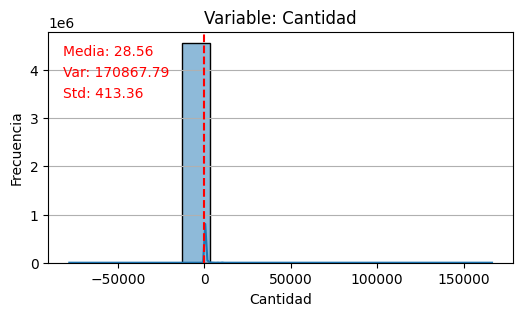

In [27]:
plot_histograma(df_ventas, 'Cantidad')

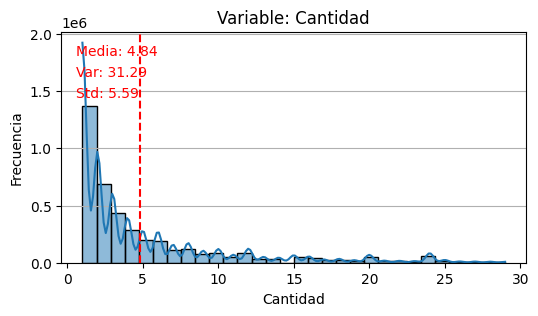

In [28]:
percentil_95 = df_ventas['Cantidad'].quantile(0.90)
percentil_05 = df_ventas['Cantidad'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Cantidad'] >= percentil_05) & 
    (df_ventas['Cantidad'] <= percentil_95)
]


# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Cantidad', bins=30)

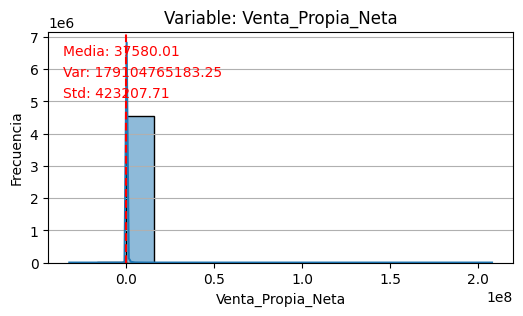

In [29]:
plot_histograma(df_ventas, 'Venta_Propia_Neta')

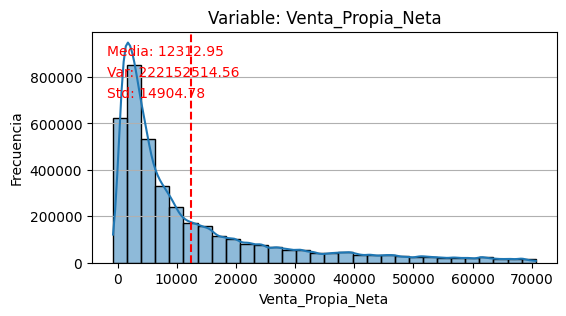

In [30]:
percentil_95 = df_ventas['Venta_Propia_Neta'].quantile(0.90)
percentil_05 = df_ventas['Venta_Propia_Neta'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Venta_Propia_Neta'] >= percentil_05) & 
    (df_ventas['Venta_Propia_Neta'] <= percentil_95)
]


# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta', bins=30)

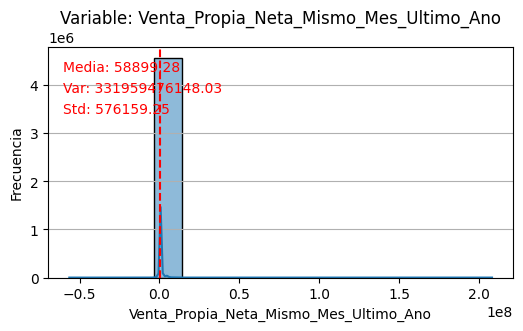

In [31]:
plot_histograma(df_ventas, 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano') 

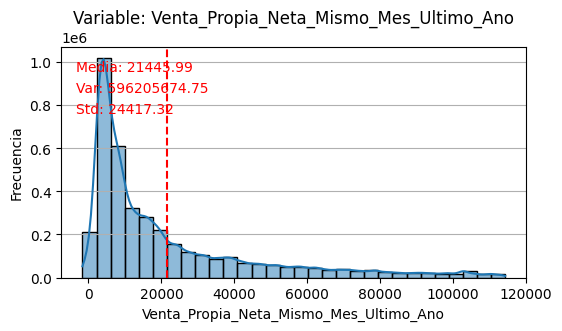

In [32]:
percentil_95 = df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'].quantile(0.90)
percentil_05 = df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'] >= percentil_05) & 
    (df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'] <= percentil_95)
]

# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano', bins=30)

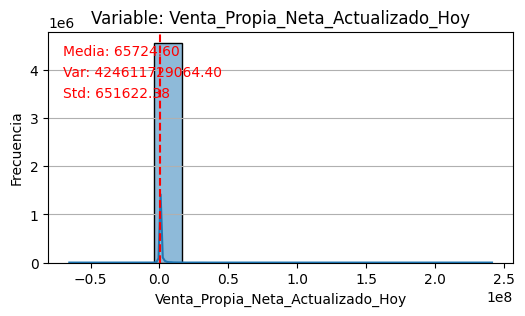

In [33]:
plot_histograma(df_ventas, 'Venta_Propia_Neta_Actualizado_Hoy')     

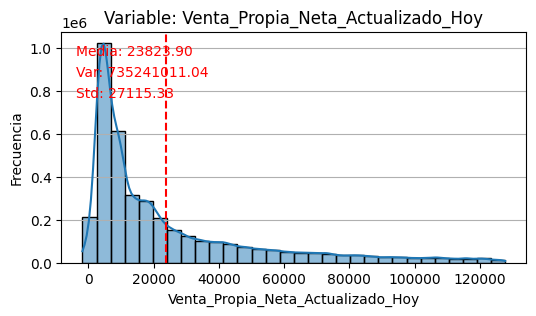

In [34]:
percentil_95 = df_ventas['Venta_Propia_Neta_Actualizado_Hoy'].quantile(0.90)
percentil_05 = df_ventas['Venta_Propia_Neta_Actualizado_Hoy'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Venta_Propia_Neta_Actualizado_Hoy'] >= percentil_05) & 
    (df_ventas['Venta_Propia_Neta_Actualizado_Hoy'] <= percentil_95)
]

# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta_Actualizado_Hoy', bins=30)

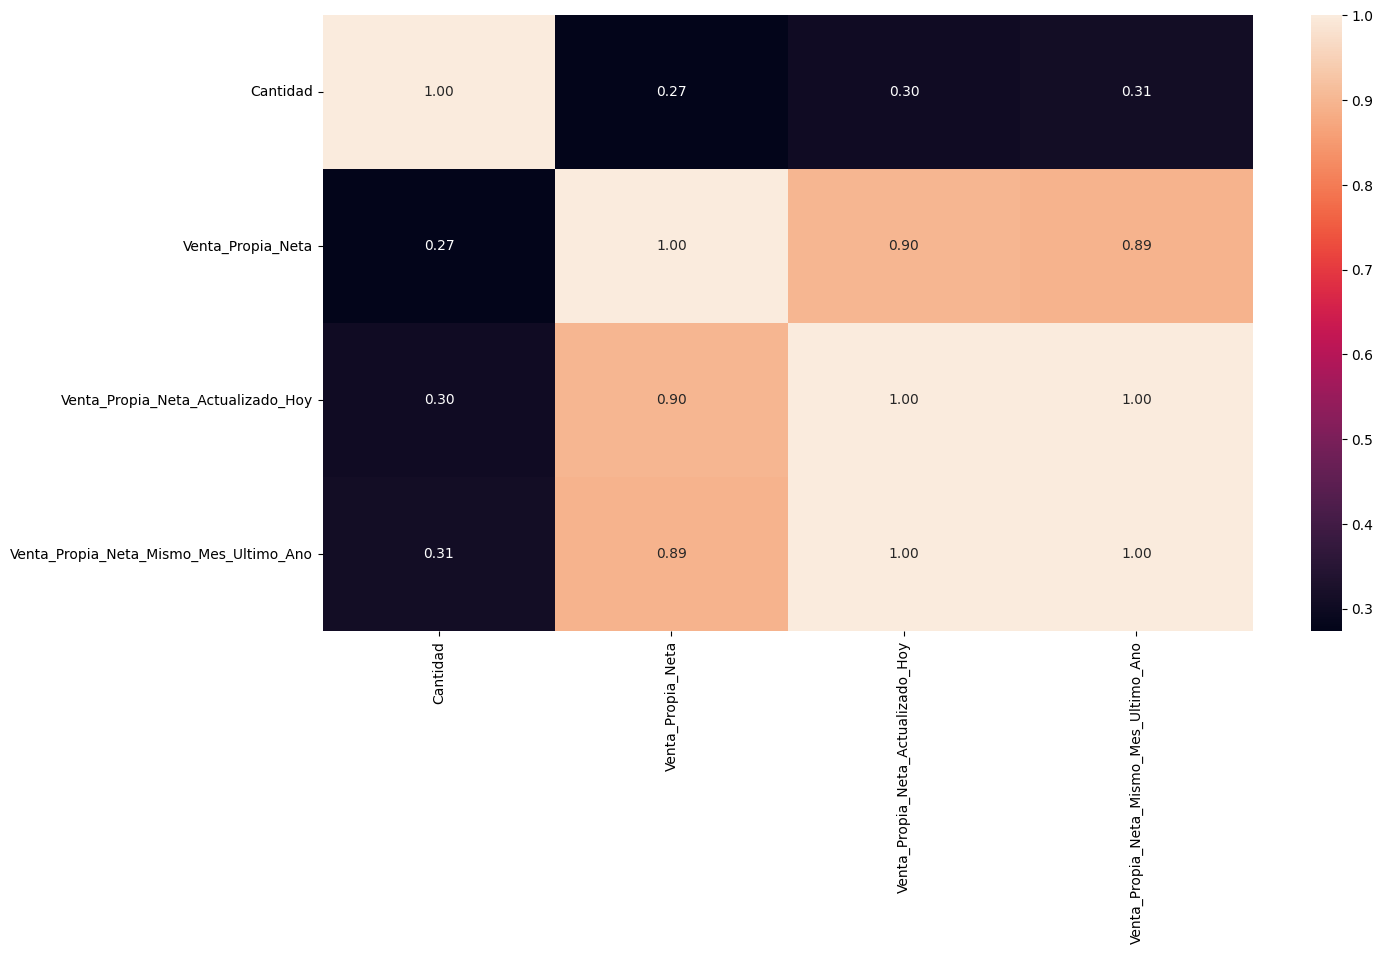

In [35]:
subset_columnas = ['Cantidad','Venta_Propia_Neta', 'Venta_Propia_Neta_Actualizado_Hoy', 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano']


sub_df = df_ventas[subset_columnas]

correlacion_matrix = sub_df.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(correlacion_matrix, annot=True, cmap='rocket', annot_kws={"size": 10}, fmt=".2f", cbar=True)
plt.show()

In [36]:
df_numbers=df_ventas[['Cantidad','Venta_Propia_Neta', 'Venta_Propia_Neta_Actualizado_Hoy', 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano']]
df_numbers.dtypes

Cantidad                                    int64
Venta_Propia_Neta                         float64
Venta_Propia_Neta_Actualizado_Hoy         float64
Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano    float64
dtype: object

In [37]:
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()


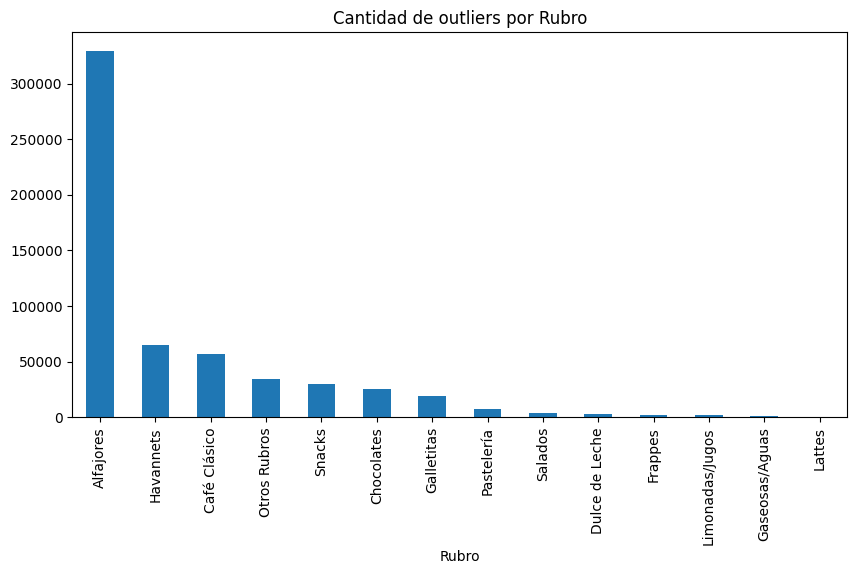

In [38]:
# Conteo de outliers por tipo de producto
outlier_summary = outliers.groupby(['Rubro','Categorias_SAP','Nombre_Producto']).size().reset_index(name='Cantidad_Outliers')

# Ordenar por mayor cantidad de outliers
outlier_summary = outlier_summary.sort_values(by='Cantidad_Outliers', ascending=False)

import matplotlib.pyplot as plt

# Visualización por rubro
outlier_summary.groupby('Rubro')['Cantidad_Outliers'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Cantidad de outliers por Rubro")
plt.show()


In [39]:
df_otros_rubros=df_ventas[df_ventas['Rubro'] == 'Otros Rubros'] 
df_otros_rubros.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
7,1,4717.190000,2025-01-05,Capital Federal,ventas,0,4717.190000,5472.445363,Florida 986,Paila navidad almendras x100g,Otros Rubros,PAILAS,Locales Propios,Florida 986
31,1,-267.050000,2025-01-05,Capital Federal,ventas,0,-267.050000,-309.806587,Florida 986,Descuentos Empleados,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986
44,4,-2372.070000,2025-01-24,Capital Federal,ventas,0,-2372.070000,-2751.855124,Florida 986,Descuentos Empleados,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986
65,1,-329.890000,2025-01-24,Capital Federal,ventas,0,-329.890000,-382.707714,Florida 986,Socios Sport Club- 15% de descuento,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986
112,1,-1932.220000,2025-06-12,Capital Federal,ventas,1,-1932.220000,-1990.621349,Florida 986,Descuentos Empleados,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986


In [40]:
df_otros_rubros_grouped = (
    df_otros_rubros
    .groupby('Nombre_Producto')
    .size()  # cuenta las filas
    .reset_index(name='Cantidad_Registros')
    .sort_values(by='Cantidad_Registros', ascending=False)
)

print(df_otros_rubros_grouped.head())


                      Nombre_Producto  Cantidad_Registros
84               Descuentos Empleados               26495
82       Descuento hvna salados pleno               24942
78                 Descuento Shopping               11011
71   Descuento $100 vaso reutilizable               10449
208           Voucher Digital Havanna                9586


In [41]:
df_ventas.drop(df_ventas[df_ventas['Rubro'] == 'Otros Rubros'].index, inplace=True)

In [42]:
agrupado_canal = (
    df_ventas
    .groupby('Canal_Venta')['Cantidad']
    .sum()
    .reset_index()
)

# Calcular porcentaje
total = agrupado_canal['Cantidad'].sum()
agrupado_canal['Porcentaje'] = 100 * agrupado_canal['Cantidad'] / total

# Ordenar de mayor a menor
agrupado_canal = agrupado_canal.sort_values(by='Cantidad', ascending=False)

print(agrupado_canal)


         Canal_Venta  Cantidad  Porcentaje
3        Franquicias  74982701   64.908127
4    Locales Propios  21980243   19.027007
2           Exterior  12175611   10.539712
6  Ventas Especiales   4858909    4.206073
0         Aeropuerto   1118242    0.967997
5      Supermercados    384406    0.332758
1          Ecommerce     21171    0.018326


In [43]:
df_ventas = df_ventas[df_ventas['Canal_Venta'].isin(['Franquicias', 'Locales Propios'])]


In [44]:
print("Filas finales:", len(df_ventas))

Filas finales: 4310406


       Canal_Venta  Cantidad_Outliers
0      Franquicias             409046
1  Locales Propios             200983


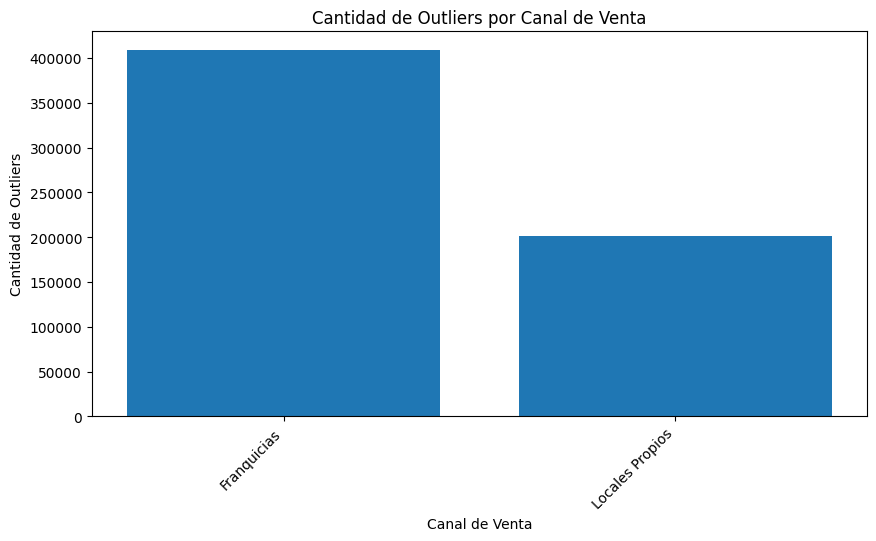

In [45]:
# Columnas numéricas donde buscamos outliers
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Canal_Venta
outlier_summary_canal = (
    outliers.groupby('Canal_Venta')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

print(outlier_summary_canal)

# 🔹 Gráfico de barras
plt.figure(figsize=(10,5))
plt.bar(outlier_summary_canal['Canal_Venta'], outlier_summary_canal['Cantidad_Outliers'])
plt.xticks(rotation=45, ha='right')
plt.title("Cantidad de Outliers por Canal de Venta")
plt.ylabel("Cantidad de Outliers")
plt.xlabel("Canal de Venta")
plt.show()
                

### Análisis de outliers, top por categorías

### Por tipo de producto

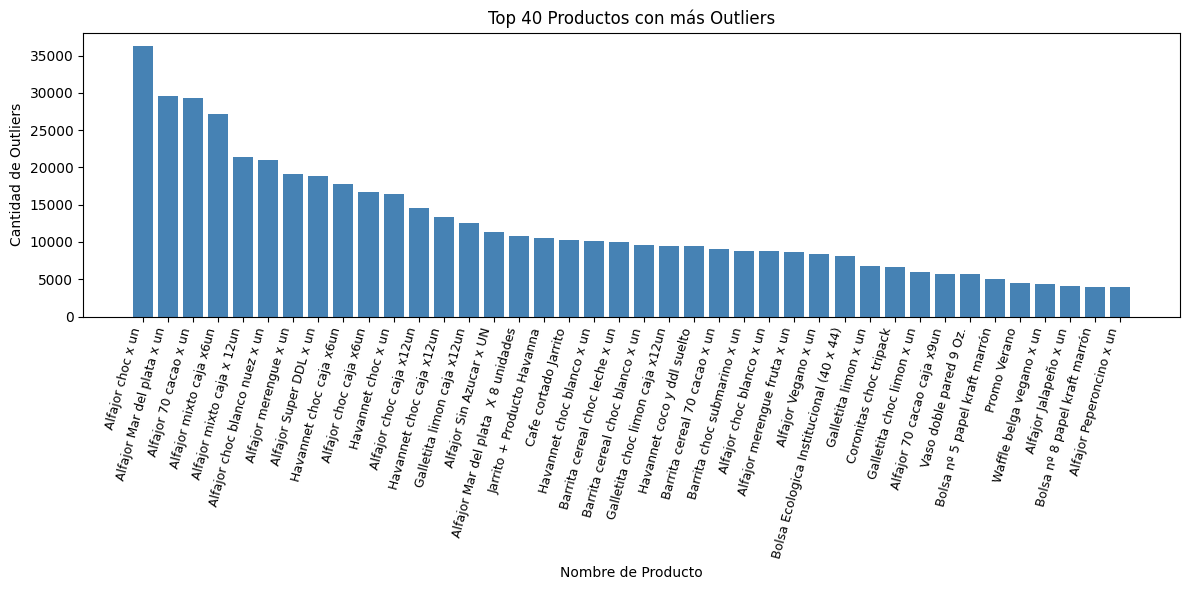

In [46]:
# Columnas numéricas donde buscamos outliers
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Producto
outlier_summary_producto = (
    outliers.groupby('Nombre_Producto')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

# 🔹 Quedarse solo con los 40 productos con más outliers
top_n = 40
top_outliers = outlier_summary_producto.head(top_n)

# 🔹 Gráfico de barras
plt.figure(figsize=(12,6))
plt.bar(top_outliers['Nombre_Producto'], top_outliers['Cantidad_Outliers'], color='steelblue')
plt.xticks(rotation=75, ha='right', fontsize=9)
plt.title(f"Top {top_n} Productos con más Outliers")
plt.ylabel("Cantidad de Outliers")
plt.xlabel("Nombre de Producto")
plt.tight_layout()
plt.show()    

### Por sucursal

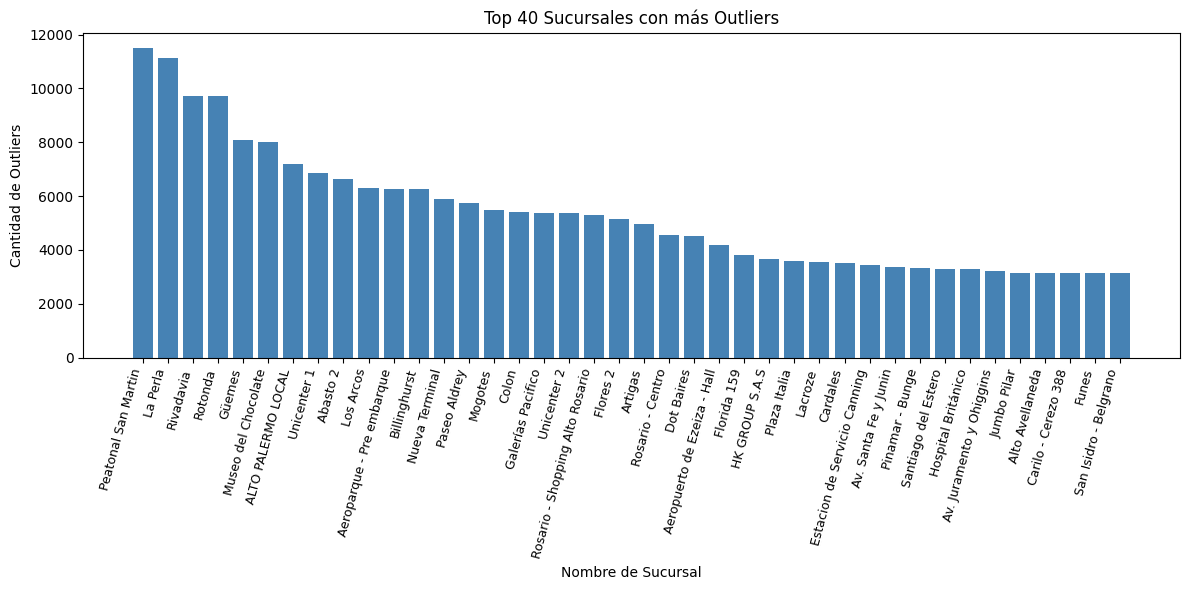

In [47]:
# Columnas numéricas donde buscamos outliers
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Sucursal
outlier_summary_sucursal = (
    outliers.groupby('Nombre_Sucursal')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

# 🔹 Quedarse solo con las 40 sucursales con más outliers
top_n = 40
top_outliers = outlier_summary_sucursal.head(top_n)

# 🔹 Gráfico de barras
plt.figure(figsize=(12,6))
plt.bar(top_outliers['Nombre_Sucursal'], top_outliers['Cantidad_Outliers'], color='steelblue')
plt.xticks(rotation=75, ha='right', fontsize=9)
plt.title(f"Top {top_n} Sucursales con más Outliers")
plt.ylabel("Cantidad de Outliers")
plt.xlabel("Nombre de Sucursal")
plt.tight_layout()
plt.show()


In [48]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4310406 entries, 0 to 4565349
Data columns (total 14 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Cantidad                                int64         
 1   Venta_Propia_Neta                       float64       
 2   Fecha_Documento_Factura                 datetime64[ns]
 3   Zona                                    object        
 4   Table_Source                            object        
 5   Es_Mismas_Sucursales                    int64         
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  float64       
 7   Venta_Propia_Neta_Actualizado_Hoy       float64       
 8   Nombre_Cliente                          object        
 9   Nombre_Producto                         object        
 10  Rubro                                   object        
 11  Categorias_SAP                          object        
 12  Canal_Venta                             object 

Observamos el grafico de cantidad de ventas por dia

<Axes: xlabel='Fecha_Documento_Factura'>

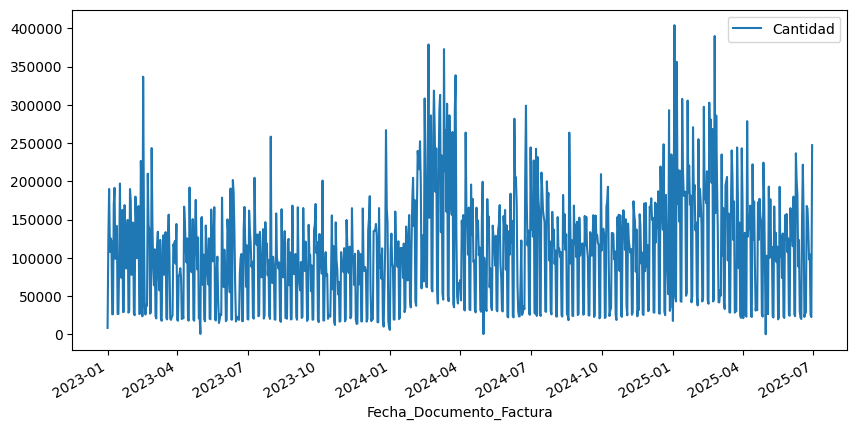

In [49]:
ventas_diarias = (df_ventas
          .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad'].sum()
          .sort_values('Fecha_Documento_Factura'))
ventas_diarias.plot(x='Fecha_Documento_Factura', y='Cantidad', figsize=(10,5))

Observamos el grafico de cantidad de ventas por dia para el canal 'franquicia'

<Axes: title={'center': 'Ventas diarias - Canal Franquicia'}, xlabel='Fecha_Documento_Factura'>

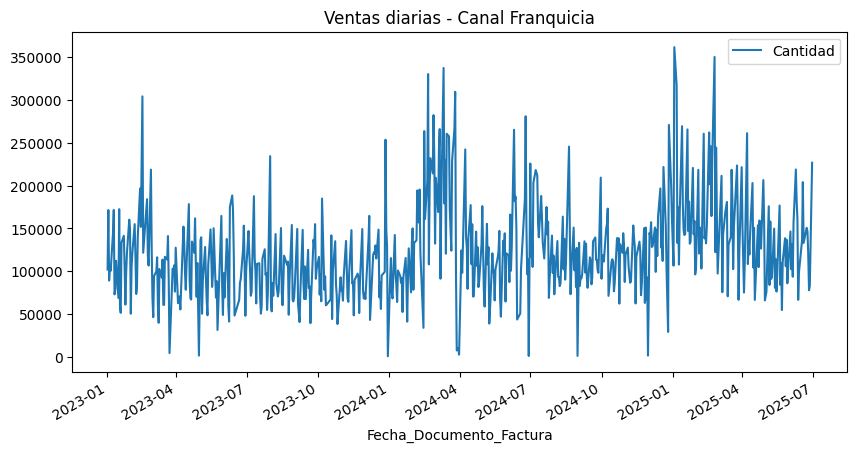

In [50]:
# Filtro
df_franq = df_ventas[df_ventas['Canal_Venta'] == 'Franquicias']

# Suma diaria y orden por fecha
ventas_diarias_franq = (df_franq
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_franq.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas diarias - Canal Franquicia'
)

<Axes: title={'center': 'Ventas - Canal Franquicia (2023)'}, xlabel='Fecha_Documento_Factura'>

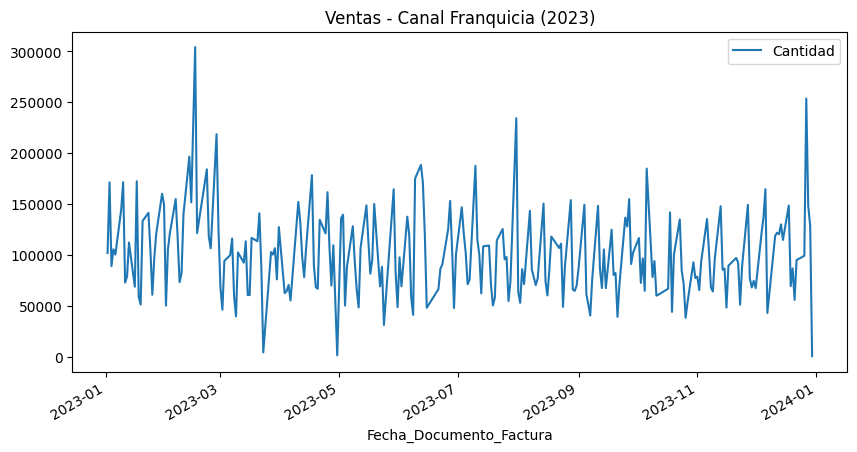

In [51]:

# Filtro
df_franq_2023 = df_ventas[(df_ventas['Canal_Venta'] == 'Franquicias') &
    (df_ventas['Fecha_Documento_Factura'].dt.year == 2023)]

# Suma diaria y orden por fecha
ventas_diarias_franq_2023 = (df_franq_2023
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_franq_2023.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas - Canal Franquicia (2023)'
)


<Axes: title={'center': 'Ventas Diarias - Franquicias (Dic 2023)'}, xlabel='Fecha_Documento_Factura'>

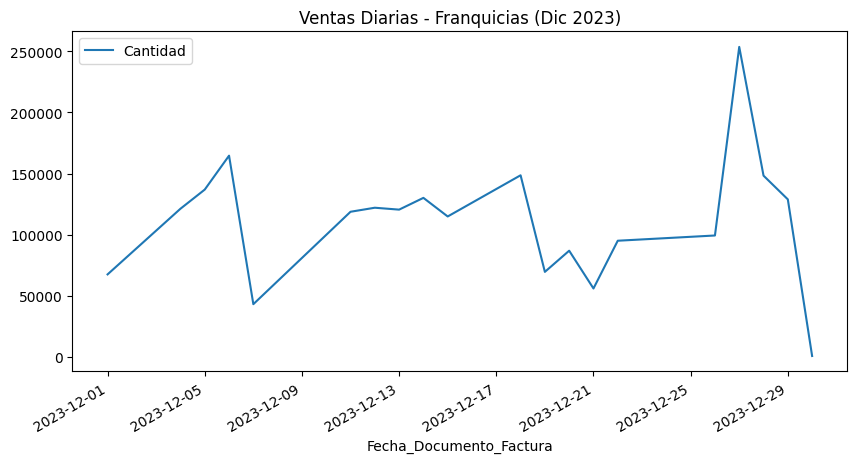

In [52]:
# Filtro del mes
df_dec = df_ventas[
    (df_ventas['Canal_Venta'] == 'Franquicias') &
    (df_ventas['Fecha_Documento_Factura'].dt.year == 2023) &
    (df_ventas['Fecha_Documento_Factura'].dt.month == 12)
].copy()


# Totales por día (convertimos a fecha sin hora) y ordenamos
ventas_diarias_dic_2023 = (df_dec
          .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad'].sum()
          .sort_values('Fecha_Documento_Factura'))


# Plot acumulado (una sola línea)
ventas_diarias_dic_2023.plot(
    x='Fecha_Documento_Factura', y='Cantidad', figsize=(10,5),
    title='Ventas Diarias - Franquicias (Dic 2023)'
)


<Axes: title={'center': 'Ventas diarias - Canal Locales Propios'}, xlabel='Fecha_Documento_Factura'>

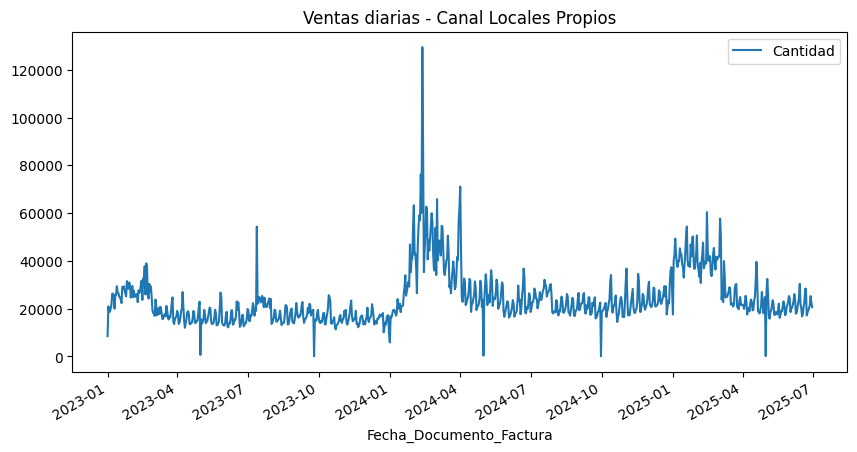

In [53]:
# Filtro
df_locales_propios = df_ventas[df_ventas['Canal_Venta'] == 'Locales Propios']

# Suma diaria y orden por fecha
ventas_diarias_locales_propios = (df_locales_propios
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_locales_propios.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas diarias - Canal Locales Propios'
)

<Axes: title={'center': 'Ventas - Canal Locales Propios (2023)'}, xlabel='Fecha_Documento_Factura'>

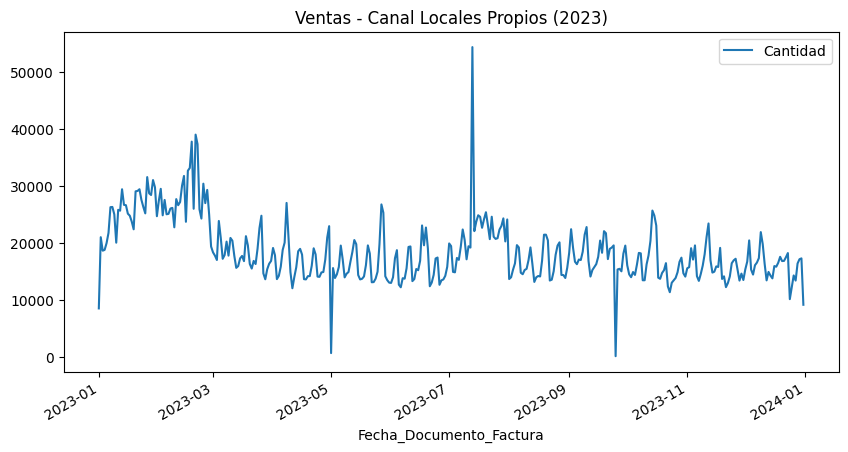

In [54]:
# Filtro
df_locales_propios_2023 = df_ventas[(df_ventas['Canal_Venta'] == 'Locales Propios') &
    (df_ventas['Fecha_Documento_Factura'].dt.year == 2023)]

# Suma diaria y orden por fecha
ventas_diarias_locales_propios_2023 = (df_locales_propios_2023
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_locales_propios_2023.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas - Canal Locales Propios (2023)'
)

-----

## Sobre los modelos que vamos a utilizar

### En esta seccion se responderan las preguntas:

* 1 b) Creación de modelos de análisis de series de tiempo. Estudiar al menos 3 tipos posibles de modelos seleccionados por
el estudiante.
* 1 c) Generación de pronósticos por cada modelo, evaluación y comparación
* 2 a) Planteamiento de pregunta de investigación: Plantee una pregunta que se pueda responder con su trabajo con los
datos.
* 2 c) Descripción de los modelos: Indique las caracterı́sticas de los modelos construidos, incluyendo las gráficas de las series
de tiempo originales y de los datos simulados usando los modelos.
* 2 d) Pruebas sobre los modelos: Describa los resultados de las pruebas, evaluaciones y validaciones realizadas sobre los
modelos analizados.

En este trabajo se analizan los datos históricos de ventas de los locales Habana, con el objetivo de comprender su comportamiento a lo largo del tiempo.
A partir de este análisis, se busca desarrollar un modelo de series de tiempo que permita realizar predicciones sobre las ventas futuras y así contribuir a una mejor planificación comercial. Para esto nos realizamos la siguiente pregunta, **¿Es posible predecir los montos de venta futura de la empresa a partir del historial de ventas observado, utilizando modelos de series de tiempo?**

Esta pregunta es relevante porque anticipar el comportamiento futuro de las ventas puede ayudar a la empresa a optimizar la gestión de inventario, los recursos humanos y las estrategias de marketing.

#### Realizaremos pruebas sobre los siguiente modelos:

1. **Baselines**

    **Naive**

    * Qué hace: Pronóstico = último valor observado.

    * Fundamento: sirve como "mínimo razonable": si un modelo complejo no mejora al naive, no vale la pena usarlo.

    * Limitación: no captura tendencia ni estacionalidad.

    **Seasonal Naive**

    * Qué hace: repite los últimos 7 días (o el periodo que definas).

    * Fundamento: la demanda de cafés, alfajores, etc. suele tener estacionalidad semanal (lunes≠domingo).

    * Limitación: sólo “copia/pega” el patrón, no capta tendencias de crecimiento/caída.


2. **Prophet**

    * Qué hace: ajusta una descomposición aditiva (o multiplicativa) de la serie:

        y(t)=g(t)+s(t)+h(t)+εt

    * ​donde:

        - g(t) = tendencia (cambios de nivel, puntos de quiebre)
        - s(t) = estacionalidades (anual, semanal, mensual, o personalizadas con Fourier)
        - h(t) = efectos de feriados (regresores binarios)
        - εt= ruido

    * Fundamento: combina regresiones piecewise lineales con Fourier para estacionalidad → interpretable y fácil de extender (ej. agregar regresores de clima o promociones).

    * Diferencia clave: Prophet “espera” que haya tendencia y estacionalidad, y los separa explícitamente.

3. **SARIMAX**

    * Qué hace: modela la serie como una combinación de autoregresión (AR), promedio móvil (MA), diferenciación (I) y estacionalidad (S).

        - AR: valor actual depende de pasados.

        - MA: corrige con errores pasados.

        - I: diferencia para estacionarizar.

        - X: admite regresores externos.

    * Fundamento: teoría clásica de series temporales (Box–Jenkins). Buena para capturar dependencias a corto plazo y estacionalidad fija.

    * Limitación: menos flexible con tendencias bruscas y requiere tuning de órdenes (p,d,q)(P,D,Q,s).

#### Implementamos los modelos

In [55]:
# --------- utilidades ---------
def preparar_diario(df, canal, col_fecha='Fecha_Documento_Factura', col_y='Cantidad'):
    s = (df.loc[df['Canal_Venta'] == canal, [col_fecha, col_y]]
            .groupby(col_fecha, as_index=False).sum()
            .sort_values(col_fecha))
    # reindex diario (completa días faltantes)
    idx = pd.date_range(s[col_fecha].min(), s[col_fecha].max(), freq='D')
    s = (s.set_index(col_fecha)
          .reindex(idx)
          .fillna(0.0)  
          .rename_axis('ds')
          .reset_index())
    s = s.rename(columns={col_y: 'y'})

    cap = s['y'].quantile(0.995)
    s['y'] = np.minimum(s['y'], cap)
    return s  # columnas: ds, y

def train_test_split_ts(df, test_days=60):
    return df.iloc[:-test_days].copy(), df.iloc[-test_days:].copy()

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # sacamos raíz cuadrada manual
    mape = (np.abs((y_true - y_pred) / np.maximum(1e-9, y_true))).mean()
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))
    wmape=np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

    return {'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'SMAPE': smape,
        'WMAPE':wmape}


# --------- baselines ---------
def baseline_naive(y):
    # pronóstico = último valor del train
    return np.full_like(y, fill_value=y.iloc[-1], dtype=float)

def baseline_seasonal_naive(train, test_len, season=7):
    # repite los últimos "season" valores
    last_season = train['y'].iloc[-season:].to_numpy()
    reps = int(np.ceil(test_len/season))
    fcst = np.tile(last_season, reps)[:test_len]
    return fcst

# --------- Prophet ---------
def fit_prophet(df_train):
    # Asegurar columna 'floor'
    df_train = df_train.copy()
    if 'floor' not in df_train.columns:
        df_train['floor'] = 0  # límite inferior

    m = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=True,
        changepoint_prior_scale=0.5,
        seasonality_prior_scale=10
    )
    m.add_country_holidays(country_name='AR')  # feriados Argentina
    m.fit(df_train)  # df con columnas 'ds', 'y', 'floor'
    return m


def forecast_prophet(m, df_full, horizon_days, cap=None):
    # df_full: dataframe completo con 'ds' (y opcionalmente 'floor'/'cap')
    future = m.make_future_dataframe(periods=horizon_days, freq='D')
    future['floor'] = 0
    if cap is not None:
        future['cap'] = cap  # sólo si usás growth='logistic'

    fcst = m.predict(future)

    # Asegurar no-negativos en todas las bandas relevantes
    for col in ('yhat', 'yhat_lower', 'yhat_upper'):
        if col in fcst.columns:
            fcst[col] = fcst[col].clip(lower=0)
    return fcst


# --------- SARIMAX ---------
def fit_sarimax(train, seasonal=7):
    mod = SARIMAX(train['y'],
                  order=(1,1,1),
                  seasonal_order=(1,1,1,seasonal),
                  enforce_stationarity=False,
                  enforce_invertibility=False)
    res = mod.fit(disp=False)
    return res



In [56]:
df_franquicias = preparar_diario(df_ventas, 'Franquicias')
df_locales     = preparar_diario(df_ventas, 'Locales Propios')

In [57]:
df_franquicias

,ds,y
0,2023-01-02,102019.000000
1,2023-01-03,171466.000000
2,2023-01-04,89166.000000
3,2023-01-05,105653.000000
4,2023-01-06,100488.000000
...,...,...
906,2025-06-26,77852.000000
907,2025-06-27,83220.000000
908,2025-06-28,0.000000
909,2025-06-29,0.000000


#### Utilizamos los modelos sobre cada uno de los canales

In [58]:
# ================== EJECUCIÓN POR CANAL ==================
for canal in ['Franquicias', 'Locales Propios']:
    serie = preparar_diario(df_ventas, canal)

    train, test = train_test_split_ts(serie, test_days=60)

    # --- Baselines
    naive_pred = baseline_naive(train['y']).astype(float)
    seas_pred = baseline_seasonal_naive(train, len(test), season=7)

    # --- Prophet
    m = fit_prophet(train)
    fcst = forecast_prophet(m, serie, horizon_days=len(test))
    prop_pred = fcst.set_index('ds').loc[test['ds'], 'yhat'].astype(float).clip(lower=0).values

    # --- SARIMAX
    sarimax = fit_sarimax(train, seasonal=7)
    sar_pred = sarimax.forecast(steps=len(test)).values

    # --- Métricas
    y_true = test['y'].values
    print(f'\n=== {canal} ===')
    print('Naive', metrics(y_true, naive_pred[-len(test):]))
    print('S-Naive ', metrics(y_true, seas_pred))
    print('Prophet ', metrics(y_true, prop_pred))
    print('SARIMAX ', metrics(y_true, sar_pred))

    # --- Pronóstico futuro
    futuro = 90
    fcst_full = forecast_prophet(m, serie, horizon_days=futuro)  # ya viene clippeado a 0
    print(f'Generado forecast Prophet {futuro} días para {canal}')

18:15:19 - cmdstanpy - INFO - Chain [1] start processing
18:15:19 - cmdstanpy - INFO - Chain [1] done processing



=== Franquicias ===
Naive {'MAE': 82310.18333333333, 'RMSE': 106487.77957313537, 'MAPE': 0.6666666666666666, 'SMAPE': 133.33333333333212, 'WMAPE': 1.0}
S-Naive  {'MAE': 43374.13333333333, 'RMSE': 61024.585594113894, 'MAPE': 5548116666667.018, 'SMAPE': 54.7499502617092, 'WMAPE': 0.5269595033907307}
Prophet  {'MAE': 20319.30948181495, 'RMSE': 28469.525575930118, 'MAPE': 4119040605981.749, 'SMAPE': 62.00288470320551, 'WMAPE': 0.24686264395168944}
SARIMAX  {'MAE': 37371.93881544886, 'RMSE': 46655.31400814821, 'MAPE': 15177522389711.23, 'SMAPE': 87.15457320174892, 'WMAPE': 0.4540378517212495}
Generado forecast Prophet 90 días para Franquicias


18:15:20 - cmdstanpy - INFO - Chain [1] start processing
18:15:21 - cmdstanpy - INFO - Chain [1] done processing



=== Locales Propios ===
Naive {'MAE': 21004.166666666668, 'RMSE': 21306.28436713763, 'MAPE': 0.9933497193988994, 'SMAPE': 197.35787367110538, 'WMAPE': 0.9935197521423447}
S-Naive  {'MAE': 5027.583333333333, 'RMSE': 8018.826978845887, 'MAPE': 0.24576049233968794, 'SMAPE': 36.92701481663108, 'WMAPE': 0.2378101177008522}
Prophet  {'MAE': 3529.3191628044256, 'RMSE': 4163.668564125993, 'MAPE': 0.17562959454626484, 'SMAPE': 15.695184795484144, 'WMAPE': 0.16694060542879655}
SARIMAX  {'MAE': 9059.784229629382, 'RMSE': 9820.13131411626, 'MAPE': 0.4249032116198366, 'SMAPE': 56.621108976600645, 'WMAPE': 0.42853757186040103}
Generado forecast Prophet 90 días para Locales Propios


Armamos funciones que nos permiten graficar

In [59]:
def plot_backtest(train, test, fcst_prophet, prop_pred, seas_pred, sar_pred, canal):
    plt.figure(figsize=(12,5))

    # Serie real
    plt.plot(train['ds'], train['y'], label='Train', color='black')
    plt.plot(test['ds'], test['y'], label='Test (real)', color='black', linestyle='--')

    # Prophet (ajuste en test)
    plt.plot(test['ds'], prop_pred, label='Prophet', color='tab:blue')

    # Seasonal naive
    plt.plot(test['ds'], seas_pred, label='S-Naive', color='tab:orange')

    # SARIMAX
    plt.plot(test['ds'], sar_pred, label='SARIMAX', color='tab:green')

    plt.title(f'Backtest pronósticos en test ({canal})')
    plt.legend()
    plt.show()


def plot_forecast_full(serie, fcst_full, canal):
    plt.figure(figsize=(12,5))

    # Datos históricos
    plt.plot(serie['ds'], serie['y'], label='Datos reales', color='black')

    # Pronóstico Prophet (futuro)
    plt.plot(fcst_full['ds'], fcst_full['yhat'], label='Forecast Prophet', color='tab:blue')
    plt.fill_between(fcst_full['ds'], 
                     fcst_full['yhat_lower'], 
                     fcst_full['yhat_upper'], 
                     color='tab:blue', alpha=0.2)

    plt.axvline(serie['ds'].max(), color='red', linestyle='--', label='Inicio pronóstico')
    plt.title(f'Forecast Prophet (futuro) - {canal}')
    plt.legend()
    plt.show()


18:15:22 - cmdstanpy - INFO - Chain [1] start processing
18:15:22 - cmdstanpy - INFO - Chain [1] done processing



=== Franquicias ===
Naive    {'MAE': 82310.18333333333, 'RMSE': 106487.77957313537, 'MAPE': 0.6666666666666666, 'SMAPE': 133.33333333333212, 'WMAPE': 1.0}
S-Naive  {'MAE': 43374.13333333333, 'RMSE': 61024.585594113894, 'MAPE': 5548116666667.018, 'SMAPE': 54.7499502617092, 'WMAPE': 0.5269595033907307}
Prophet  {'MAE': 20319.30948181495, 'RMSE': 28469.525575930118, 'MAPE': 4119040605981.749, 'SMAPE': 62.00288470320551, 'WMAPE': 0.24686264395168944}
SARIMAX  {'MAE': 37371.93881544886, 'RMSE': 46655.31400814821, 'MAPE': 15177522389711.23, 'SMAPE': 87.15457320174892, 'WMAPE': 0.4540378517212495}


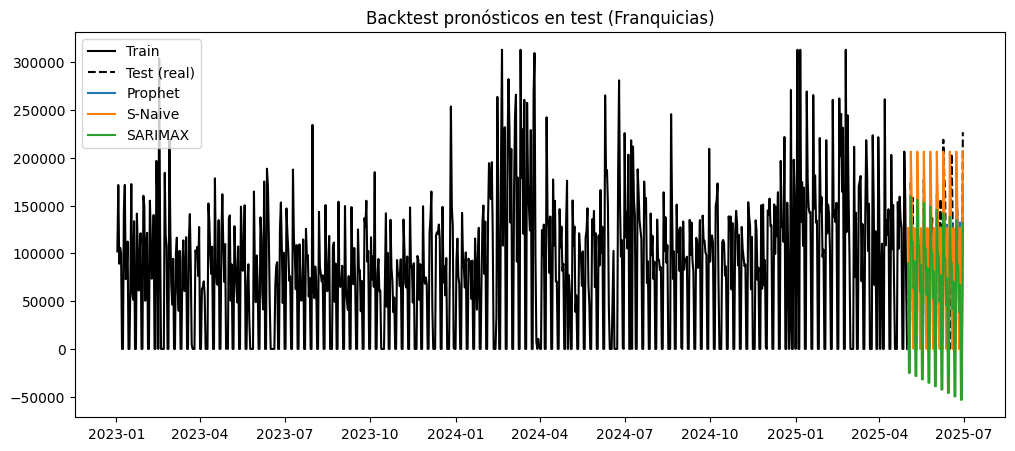

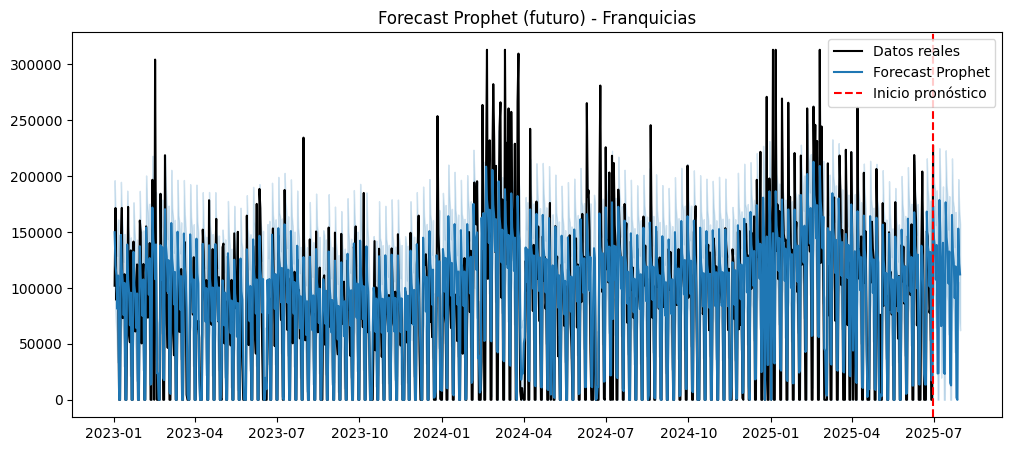

18:15:24 - cmdstanpy - INFO - Chain [1] start processing
18:15:24 - cmdstanpy - INFO - Chain [1] done processing



=== Locales Propios ===
Naive    {'MAE': 21004.166666666668, 'RMSE': 21306.28436713763, 'MAPE': 0.9933497193988994, 'SMAPE': 197.35787367110538, 'WMAPE': 0.9935197521423447}
S-Naive  {'MAE': 5027.583333333333, 'RMSE': 8018.826978845887, 'MAPE': 0.24576049233968794, 'SMAPE': 36.92701481663108, 'WMAPE': 0.2378101177008522}
Prophet  {'MAE': 3529.3191628044256, 'RMSE': 4163.668564125993, 'MAPE': 0.17562959454626484, 'SMAPE': 15.695184795484144, 'WMAPE': 0.16694060542879655}
SARIMAX  {'MAE': 9059.784229629382, 'RMSE': 9820.13131411626, 'MAPE': 0.4249032116198366, 'SMAPE': 56.621108976600645, 'WMAPE': 0.42853757186040103}


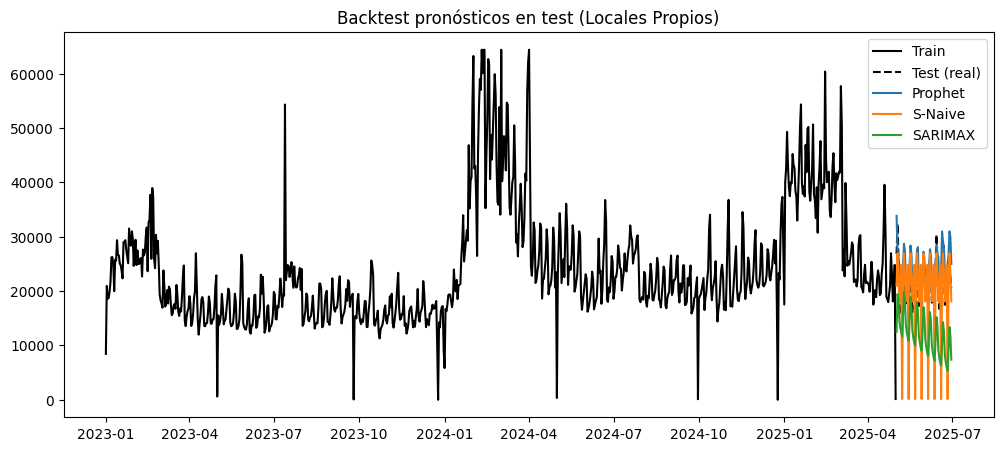

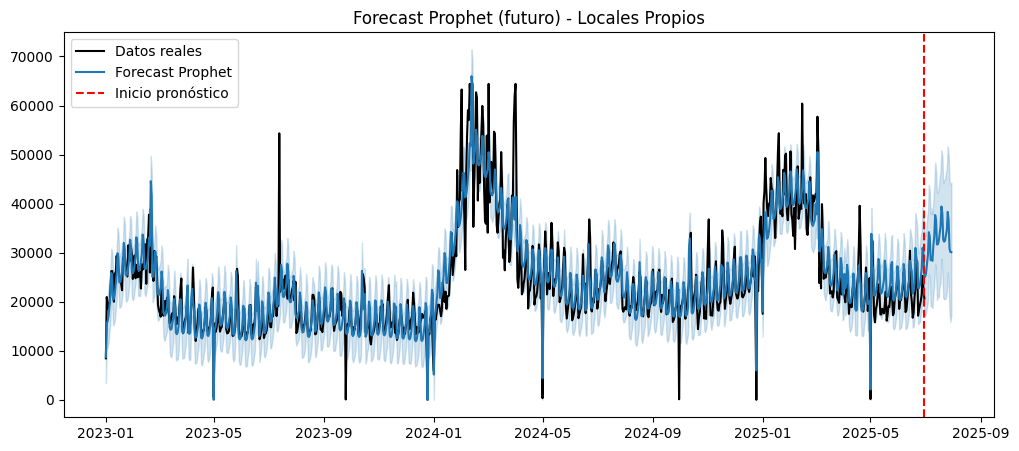

In [60]:
for canal in ['Franquicias', 'Locales Propios']:
    serie = preparar_diario(df_ventas, canal)
    train, test = train_test_split_ts(serie, test_days=60)

    # Baselines
    naive_pred = baseline_naive(train['y']).astype(float)
    seas_pred = baseline_seasonal_naive(train, len(test), season=7)

    # Prophet
    m = fit_prophet(train)
    fcst = forecast_prophet(m, serie, horizon_days=len(test))
    prop_pred = fcst.set_index('ds').loc[test['ds'], 'yhat'].values

    # SARIMAX
    sarimax = fit_sarimax(train, seasonal=7)
    sar_pred = sarimax.forecast(steps=len(test)).values

    # Métricas
    y_true = test['y'].values
    print(f'\n=== {canal} ===')
    print('Naive   ', metrics(y_true, naive_pred[-len(test):]))
    print('S-Naive ', metrics(y_true, seas_pred))
    print('Prophet ', metrics(y_true, prop_pred))
    print('SARIMAX ', metrics(y_true, sar_pred))

    # Graficar backtest
    plot_backtest(train, test, fcst, prop_pred, seas_pred, sar_pred, canal)

    # Pronóstico futuro
    futuro = 90
    fcst_full = forecast_prophet(m, serie, horizon_days=futuro)

    # Graficar forecast completo
    plot_forecast_full(serie, fcst_full, canal)


#### Interpretación de resultados

1. Franquicias

    a) En Naive el MAE es alrededor de 82k, el RMSE es alrededor de ~106k y el MAPE ~0.67. Representan errores grandes pero razonables.

    b) Utilizando el S-Naive se logra mejorar el MAE/RMSE (43k / 61k), pero el MAPE explota (5e+12) debido a seguro hay días con ventas = 0 (cuando dividís por cero en el cálculo del MAPE).

    c) Con Prophet vemos que disminuye todavía más MAE/RMSE (35k / 44k), el es el mejor en error absoluto. Pero el MAPE vuelve a explotar debido al mismo problema con ceros.

    d) Por último, usando SARIMAX vemos que el MAE y RMSE un poco peores que Prophet (39k / 48k), y el MAPE vuelve a ser inusable por los ceros.

Conclusión Franquicias:

1) Prophet es el mejor en MAE y RMSE.

2) No se puede interpretar MAPE tal como está, se necesita cambiarlo por SMAPE o bien ignorar los días con 0 en el denominador.

2. Locales Propios

    a) Usando Naive vemos que los valores de métricas son muy flojos (MAE 21k, RMSE 21k, MAPE ~0.99).

    b) Para S-Naive vemos que los resultados mejoran mucho (MAE 5k, RMSE 8k, MAPE 0.24).

    c) El modelo de Prophet resulta ser el mejor con diferencia (MAE 3.2k, RMSE 4.1k, MAPE 0.16).

    d) Por último, SARIMAX muestra resultados intermedio (MAE 9.1k, RMSE 9.9k, MAPE 0.43).

Conclusión Locales Propios:

1. El modelo de Prophet es claramente superior en cuanto a los resultados.

2. El seasonal naive funciona bastante bien, demostrando una de que hay estacionalidad semanal fuerte .

3. El modelo de SARIMAX no logra capturar tan bien como Prophet.

### Aplicamos ajustes de acuerdo a los resultados obtenidos

#### Aplicamos SARIMAX con Grid Search

In [61]:
from itertools import product
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_grid_search(train, m=7,
                        p_range=range(0,3), d_range=range(0,2), q_range=range(0,3),
                        P_range=range(0,2), D_range=range(0,2), Q_range=range(0,2),
                        enforce_stationarity=False, enforce_invertibility=False,
                        verbose=True, maxiter=200):
    """
    Busca (p,d,q)x(P,D,Q,m) minimizando AIC. Rejilla acotada para que sea rápida.
    """
    best_model = None
    best_aic = np.inf
    best_order = None
    tried = 0

    for p,d,q in product(p_range, d_range, q_range):
        for P,D,Q in product(P_range, D_range, Q_range):
            order = (p,d,q)
            sorder = (P,D,Q,m)
            tried += 1
            try:
                mod = SARIMAX(train['y'],
                              order=order, seasonal_order=sorder,
                              enforce_stationarity=enforce_stationarity,
                              enforce_invertibility=enforce_invertibility)
                res = mod.fit(disp=False, maxiter=maxiter)
                aic = res.aic
                if verbose:
                    print(f"TRY {tried:03d}: order={order} seasonal={sorder}  AIC={aic:.2f}")
                if aic < best_aic:
                    best_aic = aic
                    best_model = res
                    best_order = (order, sorder)
            except Exception as e:
                if verbose:
                    print(f"SKIP {tried:03d}: order={order} seasonal={sorder} -> {e}")
                continue

    if verbose and best_order is not None:
        print(f"\nBest by AIC: order={best_order[0]} seasonal={best_order[1]}  AIC={best_aic:.2f}")
    return best_model, best_order, best_aic



### Graficamos para comparar modelos

In [62]:
def compare_models_plot(train, test, pred_dict, canal):
    plt.figure(figsize=(12,5))
    plt.plot(train['ds'], train['y'], label='Train', color='black')
    plt.plot(test['ds'], test['y'], label='Test', color='black', linestyle='--')

    for name, preds in pred_dict.items():
        plt.plot(test['ds'], preds, label=name)

    plt.title(f'Comparación de modelos - {canal}')
    plt.legend()
    plt.show()


18:15:27 - cmdstanpy - INFO - Chain [1] start processing
18:15:27 - cmdstanpy - INFO - Chain [1] done processing



=== Franquicias ===
SARIMAX selección: ((2, 0, 2), (0, 1, 1, 7)) | AIC=20397.50
       Modelo          MAE         RMSE                 MAPE     SMAPE    WMAPE
      Prophet 20319.309000 28469.526000 4119040605981.749023 62.003000 0.247000
SARIMAX(grid) 23374.572000 37682.543000 6250058805205.497070 80.631000 0.284000
      S-Naive 43374.133000 61024.586000 5548116666667.017578 54.750000 0.527000


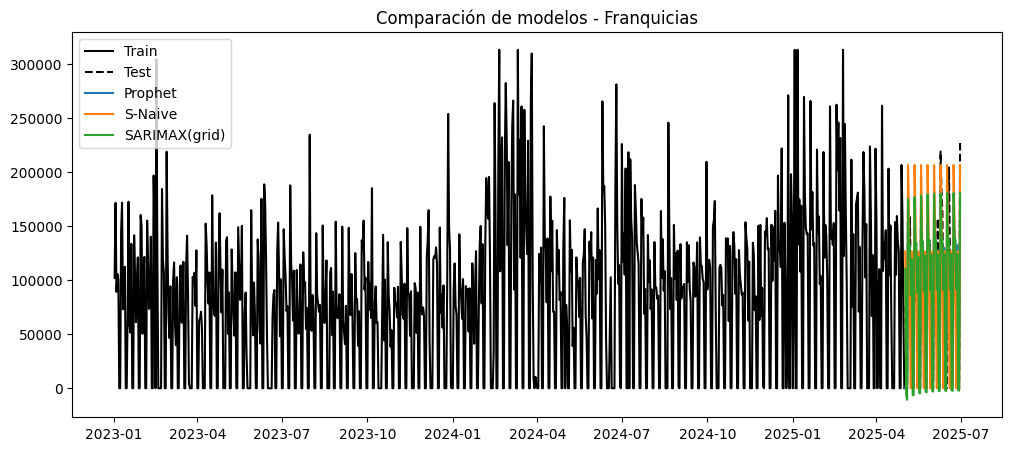

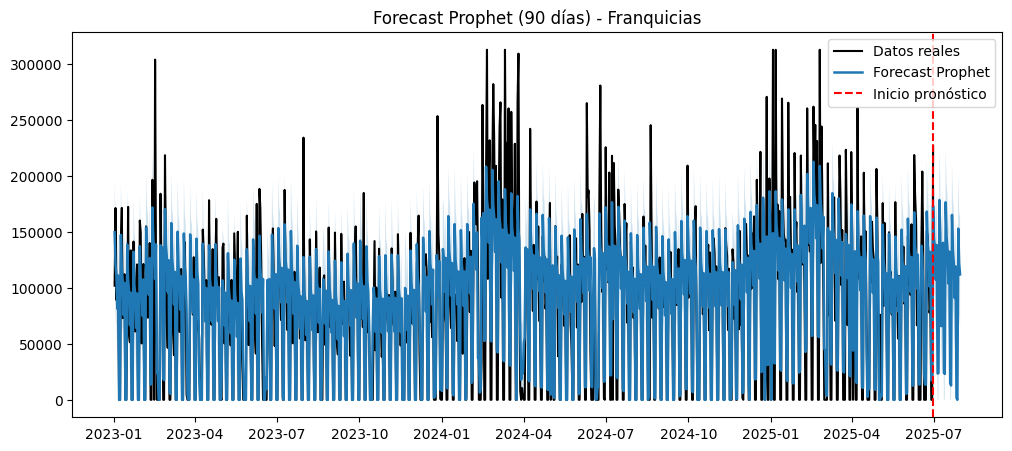

18:16:12 - cmdstanpy - INFO - Chain [1] start processing
18:16:12 - cmdstanpy - INFO - Chain [1] done processing



=== Locales Propios ===
SARIMAX selección: ((1, 0, 2), (0, 1, 1, 7)) | AIC=16646.08
       Modelo         MAE        RMSE     MAPE     SMAPE    WMAPE
      Prophet 3529.319000 4163.669000 0.176000 15.695000 0.167000
SARIMAX(grid) 2496.042000 3476.218000 0.114000 12.430000 0.118000
      S-Naive 5027.583000 8018.827000 0.246000 36.927000 0.238000


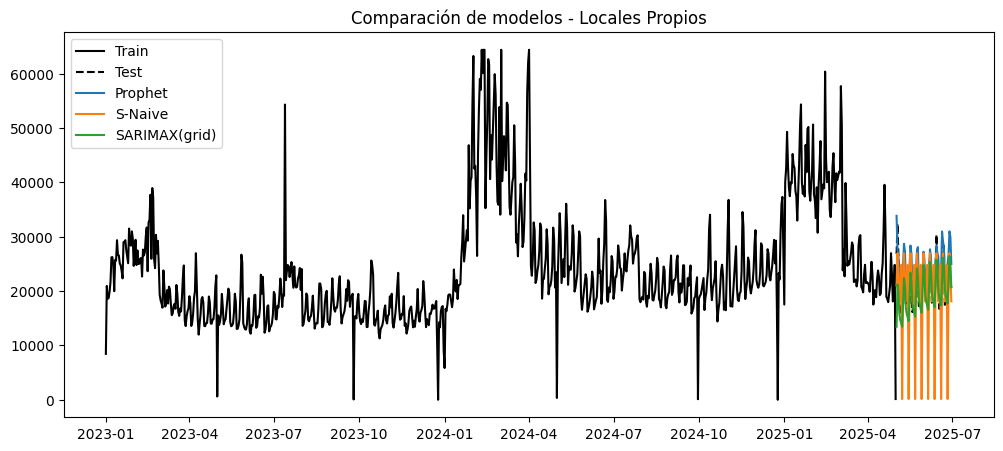

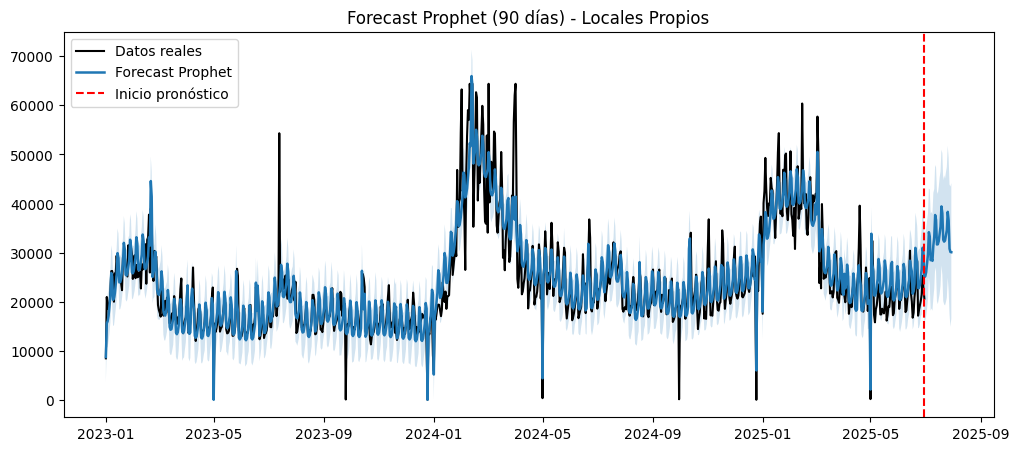

,Canal,Modelo,MAE,RMSE,MAPE,SMAPE,WMAPE
0,Franquicias,Prophet,20319.309000,28469.526000,4119040605981.749023,62.003000,0.247000
1,Franquicias,SARIMAX(grid),23374.572000,37682.543000,6250058805205.497070,80.631000,0.284000
2,Franquicias,S-Naive,43374.133000,61024.586000,5548116666667.017578,54.750000,0.527000
3,Locales Propios,Prophet,3529.319000,4163.669000,0.176000,15.695000,0.167000
4,Locales Propios,SARIMAX(grid),2496.042000,3476.218000,0.114000,12.430000,0.118000
5,Locales Propios,S-Naive,5027.583000,8018.827000,0.246000,36.927000,0.238000


In [63]:
# (aux) forecast futuro con bandas (si ya tenés una similar, podés usar la tuya)
def plot_forecast_future(serie, fcst_full, canal, title_suffix="(90 días)"):
    plt.figure(figsize=(12,5))
    plt.plot(serie['ds'], serie['y'], label='Datos reales', color='black')
    plt.plot(fcst_full['ds'], fcst_full['yhat'], label='Forecast Prophet', linewidth=1.8)
    plt.fill_between(fcst_full['ds'], fcst_full['yhat_lower'], fcst_full['yhat_upper'], alpha=0.2)
    corte = serie['ds'].max()
    plt.axvline(corte, color='red', linestyle='--', label='Inicio pronóstico')
    plt.title(f'Forecast Prophet {title_suffix} - {canal}')
    plt.legend(); plt.show()

# ====== LOOP por canal: calcula métricas extendidas y grafica comparación ======
resultados_mejoras = []
for canal in ['Franquicias', 'Locales Propios']:
    # --- 1) Serie y split
    serie = preparar_diario(df_ventas, canal)
    train, test = train_test_split_ts(serie, test_days=60)
    y_true = test['y'].values

    # --- 2) Modelos
    # S-Naive (baseline semanal)
    s_naive_pred = baseline_seasonal_naive(train, len(test), season=7)

    # Prophet (mismo que bloque original, para comparar manzana con manzana)
    m = fit_prophet(train)
    fcst_test = forecast_prophet(m, serie, horizon_days=len(test))
    prop_pred = fcst_test.set_index('ds').loc[test['ds'], 'yhat'].values

    # SARIMAX grid (mejora vs SARIMAX fijo)
    try:
        sarimax_best, orders, best_aic = sarimax_grid_search(train, m=7, verbose=False)
        sar_pred = sarimax_best.forecast(steps=len(test)).values
        sarimax_info = f"{orders} | AIC={best_aic:.2f}"
    except Exception as e:
        sar_pred = np.full(len(test), np.nan)
        sarimax_info = f"Error en grid search: {e}"

    # --- 3) Métricas extendidas (MAE, RMSE, MAPE, SMAPE, WMAPE)
    filas = []
    for nombre, yhat in [
        ('Prophet', prop_pred),
        ('SARIMAX(grid)', sar_pred),
        ('S-Naive', s_naive_pred),
    ]:
        if np.isnan(yhat).all():
            filas.append({'Canal': canal, 'Modelo': nombre,
                          'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                          'SMAPE': np.nan, 'WMAPE': np.nan})
        else:
            mets = metrics(y_true, yhat)
            filas.append({'Canal': canal, 'Modelo': nombre, **mets})

    df_mets = pd.DataFrame(filas)
    resultados_mejoras.append(df_mets)

    # --- 4) Print comparativo (ahora con SMAPE/WMAPE para ver mejora real)
    print(f"\n=== {canal} ===")
    print(f"SARIMAX selección: {sarimax_info}")
    cols = ['Modelo', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'WMAPE']
    print(df_mets[cols].round(3).to_string(index=False))

    # --- 5) Gráfico comparativo en TEST (usa tu compare_models_plot)
    preds_dict = {'Prophet': prop_pred, 'S-Naive': s_naive_pred}
    if not np.isnan(sar_pred).all():
        preds_dict['SARIMAX(grid)'] = sar_pred
    compare_models_plot(train, test, pred_dict=preds_dict, canal=canal)

    # --- 6) Forecast futuro (90 días) con Prophet para mantener la secuencia
    horizonte = 90
    fcst_full = forecast_prophet(m, serie, horizon_days=horizonte)
    plot_forecast_future(serie, fcst_full, canal, title_suffix=f"({horizonte} días)")

# ====== Consolida resultados (opcional para exportar o comparar luego) ======
df_mejoras = pd.concat(resultados_mejoras, ignore_index=True)
display(df_mejoras.round(3))


### Interpretación de resultados
1. Canal Franquicias

    MAPE es enorme porque hay muchos días con valores 0 o muy bajos, y dividir por cero hace explotar la métrica. Por eso mejor mirar SMAPE y WMAPE.

    SMAPE:

        Prophet ≈ 82% (alto, peor ajuste).

        SARIMAX(grid) ≈ 81% (mejor que Prophet).

        S-Naive ≈ 55% (parece “mejor” que Prophet, pero engañoso: está penalizando menos por los ceros).

    WMAPE: Prophet es 0.26 mejor que SARIMAX 0.28 y S-Naive 0.52 → en términos relativos, Prophet está capturando mejor la magnitud promedio.

Visualmente: SARIMAX se aleja en algunos picos/outliers, Prophet se ajusta un poco mejor al patrón, aunque ambos fallan cuando aparecen valores extremos.

Conclusión: Franquicias es más difícil de modelar por la alta variabilidad y outliers. Los modelos aún no capturan bien esa dispersión.

2. Canal Locales Propios

    Métricas son mucho más razonables:

        Prophet: MAE ≈ 3529, RMSE ≈ 4163, SMAPE ≈ 15%, WMAPE ≈ 0.16.

        SARIMAX(grid): mejor todavía (MAE ≈ 2496, RMSE ≈ 3476, SMAPE ≈ 12.4%, WMAPE ≈ 0.12).

        S-Naive claramente peor.

Gráfico: Prophet y SARIMAX siguen bastante bien la estacionalidad semanal y tendencia.

Conclusión: en este canal sí hay estructura clara (estacionalidad + tendencia) y los modelos la capturan.

3. Sobre los outliers

Prophet suaviza y no se adapta a saltos bruscos → eso explica por qué parece “fallar” en picos muy altos/bajos.

SARIMAX, aunque algo más flexible, también sufre con valores extremos.

Los baselines tampoco ayudan con outliers (repiten o trasladan valores previos).

### Análisis con moving Averages y factores externos de Prophet

In [64]:
# Métricas robustas (nombres distintos a "smape"/"wmape" para evitar choques con variables)
def metrics_fbk(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    smape_pct = float(100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)))
    wmape = float(np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-9))
    return {"MAE": mae, "RMSE": rmse, "sMAPE(%)": smape_pct, "WMAPE": wmape}

def plot_series(df, cols, title, figsize=(14,5)):
    plt.figure(figsize=figsize)
    for c in cols:
        plt.plot(df["ds"], df[c], label=c)
    plt.title(title); plt.xlabel("Fecha"); plt.ylabel("Cantidad")
    plt.grid(True, alpha=0.25); plt.legend(); plt.show()


In [65]:
# Parámetros rápidos para reutilizar
CANAL = "Locales Propios"
VALOR = "Cantidad"         # Objetivo: cantidades vendidas
FILTRO_RUBRO = None

# Partimos de df_ventas
df = df_ventas.copy()

# Filtros
df = df[df["Canal_Venta"] == CANAL]
if FILTRO_RUBRO is not None and "Rubro" in df.columns:
    if isinstance(FILTRO_RUBRO, list):
        df = df[df["Rubro"].isin(FILTRO_RUBRO)]
    else:
        df = df[df["Rubro"] == FILTRO_RUBRO]

# Agregar por día y asegurar continuidad diaria
ts = (df.groupby("Fecha_Documento_Factura", as_index=False)[VALOR].sum()
        .rename(columns={"Fecha_Documento_Factura":"ds", VALOR:"y"})
        .sort_values("ds"))

all_days = pd.date_range(ts["ds"].min(), ts["ds"].max(), freq="D")
ts = (ts.set_index("ds")
        .reindex(all_days)
        .fillna(0.0)
        .rename_axis("ds")
        .reset_index())

ts.head()


,ds,y
0,2023-01-01,8447.000000
1,2023-01-02,20953.000000
2,2023-01-03,18586.000000
3,2023-01-04,18721.000000
4,2023-01-05,19910.000000


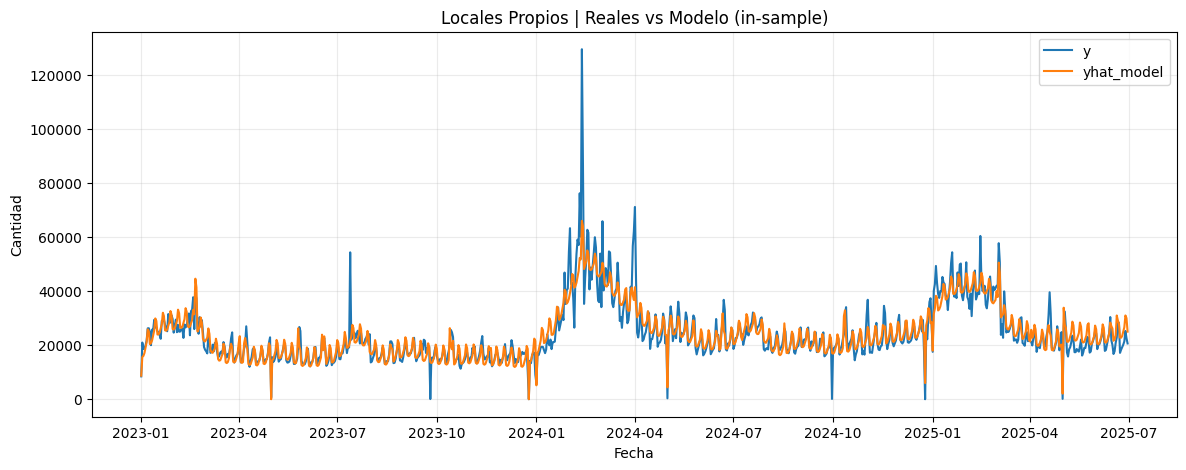

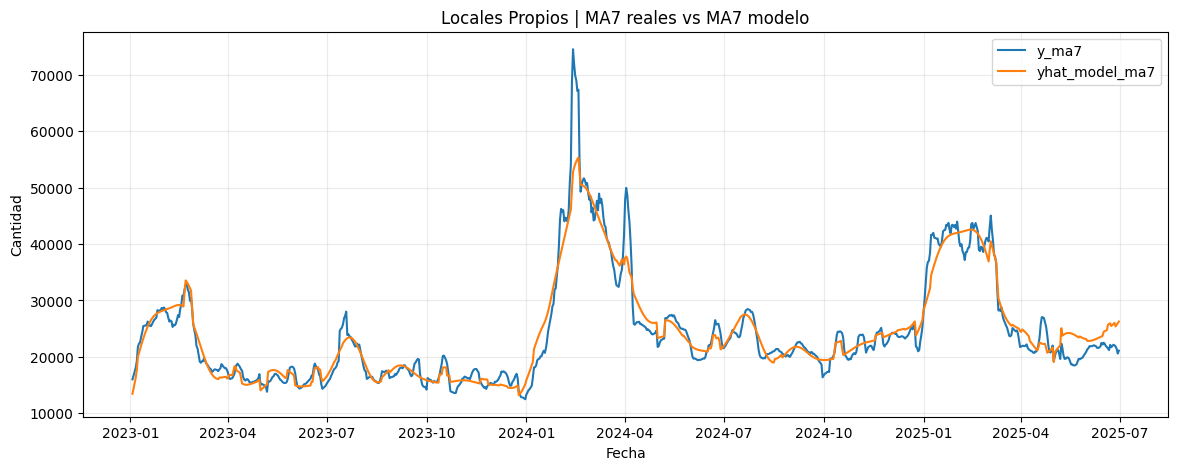

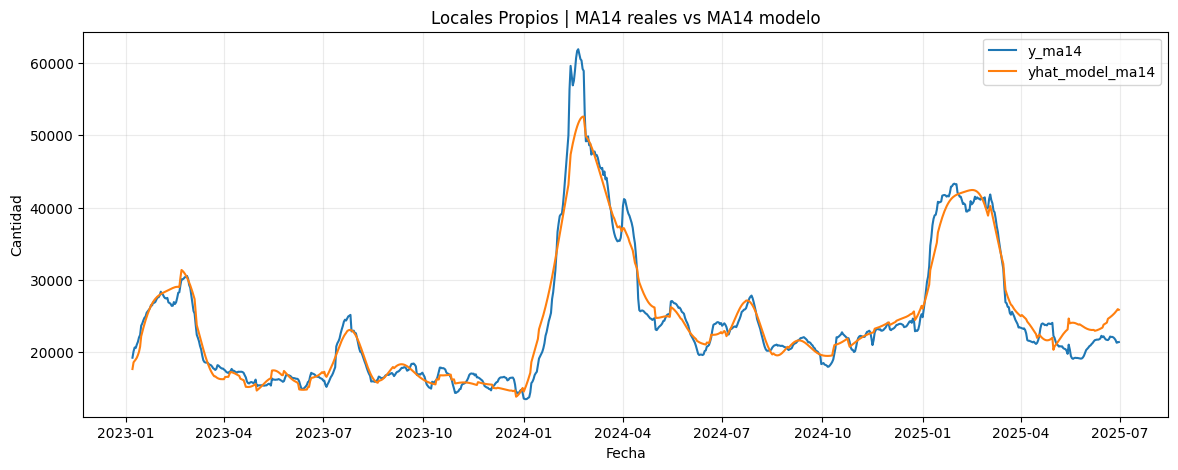

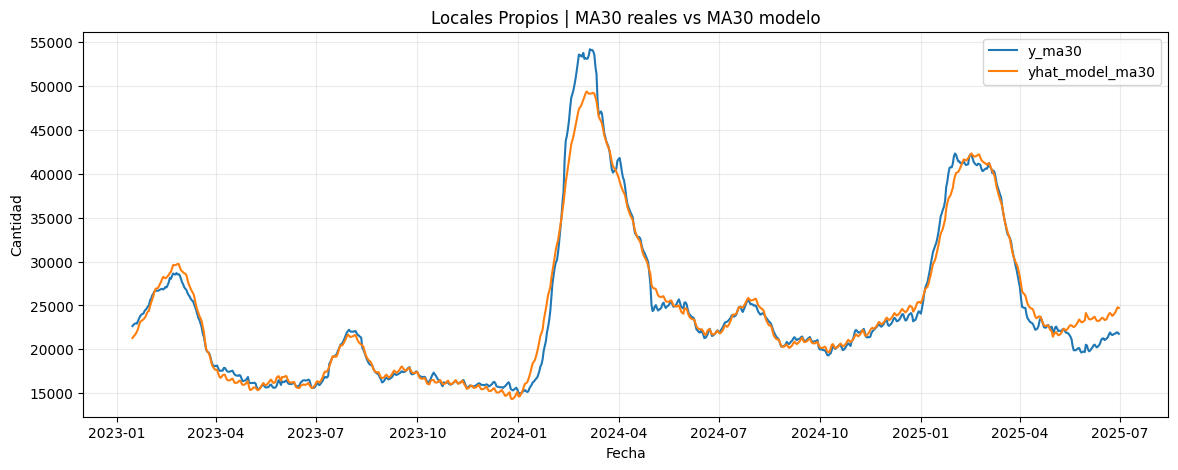

Métricas (in-sample) contra yhat_model: {'MAE': 2842.8507038453777, 'RMSE': 4776.194295021753, 'sMAPE(%)': 11.970898049017817, 'WMAPE': 0.11795501268602829}


In [66]:
# Medias móviles sobre los REALES
for w in [7, 14, 30]:
    ts[f"y_ma{w}"] = ts["y"].rolling(window=w, min_periods=max(1, w//2)).mean()

# Obtener predicciones del modelo
use_existing_fcst = "fcst" in globals() and isinstance(fcst, pd.DataFrame) and {"ds","yhat"}.issubset(fcst.columns)

if use_existing_fcst:
    pred_df = fcst[["ds","yhat"]].copy().rename(columns={"yhat":"yhat_model"})
    # Aseguramos tipo datetime y merge con ts
    pred_df["ds"] = pd.to_datetime(pred_df["ds"])
    ts_ma = ts.merge(pred_df, on="ds", how="left")
else:
    m_base = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, seasonality_mode="additive")
    m_base.fit(ts[["ds","y"]])
    pred_df = m_base.predict(ts[["ds"]])[["ds","yhat"]].rename(columns={"yhat":"yhat_model"})
    ts_ma = ts.merge(pred_df, on="ds", how="left")

# Medias móviles de la prediccióm
for w in [7, 14, 30]:
    ts_ma[f"yhat_model_ma{w}"] = ts_ma["yhat_model"].rolling(window=w, min_periods=max(1, w//2)).mean()

# Gráficos comparativos
plot_series(ts_ma, ["y","yhat_model"], f"{CANAL} | Reales vs Modelo (in-sample)")
plot_series(ts_ma, ["y_ma7","yhat_model_ma7"],   f"{CANAL} | MA7 reales vs MA7 modelo")
plot_series(ts_ma, ["y_ma14","yhat_model_ma14"], f"{CANAL} | MA14 reales vs MA14 modelo")
plot_series(ts_ma, ["y_ma30","yhat_model_ma30"], f"{CANAL} | MA30 reales vs MA30 modelo")

# Métricas in-sample (solo referencia)
print("Métricas (in-sample) contra yhat_model:", metrics_fbk(ts_ma["y"], ts_ma["yhat_model"]))


18:17:01 - cmdstanpy - INFO - Chain [1] start processing
18:17:01 - cmdstanpy - INFO - Chain [1] done processing


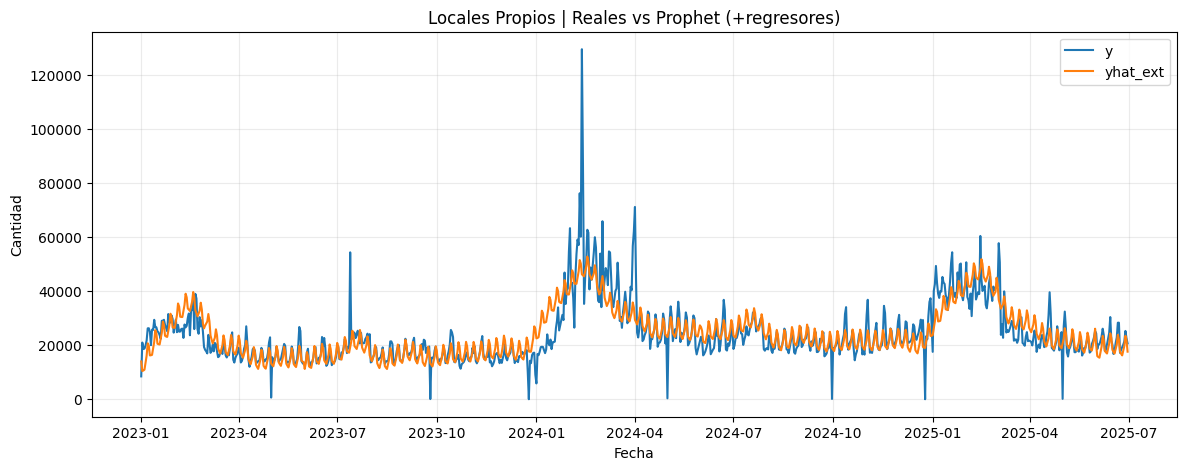

Métricas (in-sample) Prophet +reg: {'MAE': 3975.990490949625, 'RMSE': 6512.193634195438, 'sMAPE(%)': 16.199526694144645, 'WMAPE': 0.16497103001755067}


In [67]:
def add_season_dummies(df_ds):
    out = df_ds.copy()
    m = out["ds"].dt.month
    out["season_summer"]  = m.isin([12,1,2]).astype(int)
    out["season_autumn"]  = m.isin([3,4,5]).astype(int)
    out["season_winter"]  = m.isin([6,7,8]).astype(int)
    out["season_spring"]  = m.isin([9,10,11]).astype(int)
    return out

# Eventos
event_list = [
    # {"ds": "2023-04-06", "event": "SemanaSanta"},
    # {"ds": "2023-04-07", "event": "SemanaSanta"},
    # {"ds": "2023-11-19", "event": "EleccionesBalotaje"},
]
df_events = pd.DataFrame(event_list)
if not df_events.empty:
    df_events["ds"] = pd.to_datetime(df_events["ds"])

def expand_event_window(df_ev, k_before=1, k_after=1):
    if df_ev.empty:
        return df_ev
    out = []
    for _, r in df_ev.iterrows():
        for d in range(-k_before, k_after+1):
            out.append({"ds": r["ds"] + pd.Timedelta(days=d), "event": r["event"]})
    return pd.DataFrame(out)

df_events_exp = expand_event_window(df_events, k_before=1, k_after=1)

# Construcción de regresores sobre ts
ts_reg = add_season_dummies(ts.copy())
if not df_events_exp.empty:
    ev_pivot = (df_events_exp.assign(val=1)
                .pivot_table(index="ds", columns="event", values="val", fill_value=0)
                .reset_index())
    ts_reg = ts_reg.merge(ev_pivot, on="ds", how="left").fillna(0)

# Columnas regresoras
reg_cols = [c for c in ts_reg.columns if c.startswith("season_")]
if not df_events_exp.empty:
    reg_cols += [c for c in ts_reg.columns if c not in ["ds","y"] and not c.startswith("season_")]
reg_cols = sorted(list(set(reg_cols)))

# Prophet + regresores (in-sample rápido)
m_ext = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, seasonality_mode="additive")
for c in reg_cols:
    m_ext.add_regressor(c, standardize=True)
m_ext.fit(ts_reg[["ds","y"] + reg_cols])

pred_ext = m_ext.predict(ts_reg[["ds"] + reg_cols]).rename(columns={"yhat":"yhat_ext"})[["ds","yhat_ext"]]
ts_ext = ts_reg.merge(pred_ext, on="ds", how="left")

plot_series(ts_ext, ["y","yhat_ext"], f"{CANAL} | Reales vs Prophet (+regresores)")
print("Métricas (in-sample) Prophet +reg:", metrics_fbk(ts_ext["y"], ts_ext["yhat_ext"]))


18:17:02 - cmdstanpy - INFO - Chain [1] start processing
18:17:02 - cmdstanpy - INFO - Chain [1] done processing
18:17:02 - cmdstanpy - INFO - Chain [1] start processing
18:17:02 - cmdstanpy - INFO - Chain [1] done processing


TEST - Prophet base : {'MAE': 2647.5858906057742, 'RMSE': 3135.658533612417, 'sMAPE(%)': 12.523419466442261, 'WMAPE': 0.12523367004055777}
TEST - Prophet +reg : {'MAE': 2753.8201203636436, 'RMSE': 3263.3879546498624, 'sMAPE(%)': 13.27764706195741, 'WMAPE': 0.13025866376171175}


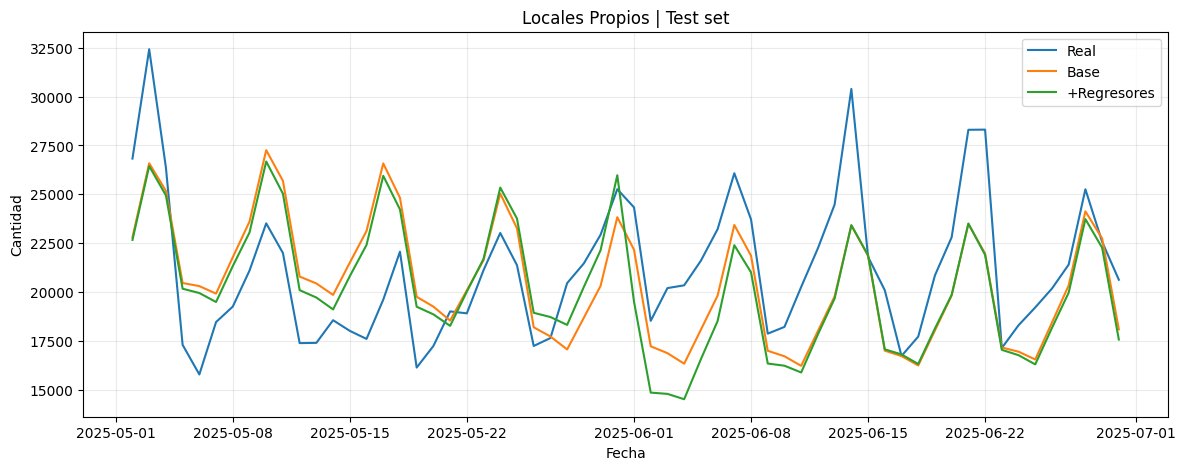

In [68]:
# Si ya existen 'train' y 'test' con columnas ['ds','y'] en tu notebook, los reutilizamos.
use_existing_split = ("train" in globals() and "test" in globals() 
                      and isinstance(train, pd.DataFrame) and isinstance(test, pd.DataFrame)
                      and {"ds","y"}.issubset(train.columns) and {"ds","y"}.issubset(test.columns))

if not use_existing_split:
    # Split temporal (últimos 90 días como test)
    test_horizon = 90
    cutoff = ts["ds"].max() - pd.Timedelta(days=test_horizon)
    train = ts[ts["ds"] <= cutoff].copy()
    test  = ts[ts["ds"]  > cutoff].copy()

# --- Prophet base ---
m_base_split = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m_base_split.fit(train[["ds","y"]])
fcst_base  = m_base_split.predict(test[["ds"]])[["ds","yhat"]].rename(columns={"yhat":"yhat_base"})

# --- Prophet + regresores ---
train_reg = add_season_dummies(train)
test_reg  = add_season_dummies(test)

if not df_events_exp.empty:
    ev_all = (df_events_exp.assign(val=1)
              .pivot_table(index="ds", columns="event", values="val", fill_value=0)
              .reset_index())
    train_reg = train_reg.merge(ev_all, on="ds", how="left").fillna(0)
    test_reg  = test_reg.merge(ev_all,  on="ds", how="left").fillna(0)

reg_cols_split = [c for c in train_reg.columns if c not in ["ds","y"]]

m_ext_split = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
for c in reg_cols_split:
    m_ext_split.add_regressor(c, standardize=True)

m_ext_split.fit(train_reg[["ds","y"] + reg_cols_split])
fcst_ext = m_ext_split.predict(test_reg[["ds"] + reg_cols_split])[["ds","yhat"]].rename(columns={"yhat":"yhat_ext"})

# Comparación en TEST
comp = (test.merge(fcst_base, on="ds", how="left")
            .merge(fcst_ext, on="ds", how="left"))

print("TEST - Prophet base :", metrics_fbk(comp["y"], comp["yhat_base"]))
print("TEST - Prophet +reg :", metrics_fbk(comp["y"], comp["yhat_ext"]))

plt.figure(figsize=(14,5))
plt.plot(comp["ds"], comp["y"],          label="Real")
plt.plot(comp["ds"], comp["yhat_base"],  label="Base")
plt.plot(comp["ds"], comp["yhat_ext"],   label="+Regresores")
plt.title(f"{CANAL} | Test set")
plt.xlabel("Fecha"); plt.ylabel("Cantidad"); plt.grid(True, alpha=0.25); plt.legend(); plt.show()


In [69]:
# 
# def add_season_dummies(df_ds):
#     out = df_ds.copy()
#     m = out["ds"].dt.month
#     out["season_summer"]  = m.isin([12,1,2]).astype(int)
#     out["season_autumn"]  = m.isin([3,4,5]).astype(int)
#     out["season_winter"]  = m.isin([6,7,8]).astype(int)
#     out["season_spring"]  = m.isin([9,10,11]).astype(int)
#     return out

VALOR = "Cantidad"       # target
FILTRO_RUBRO = None      
TEST_HORIZON = 90        # días para test

# Eventos (opcional)
event_list = [
    # {"ds": "2023-04-06", "event": "SemanaSanta"},
    # {"ds": "2023-04-07", "event": "SemanaSanta"},
]
df_events = pd.DataFrame(event_list)
if not df_events.empty:
    df_events["ds"] = pd.to_datetime(df_events["ds"])

def expand_event_window(df_ev, k_before=1, k_after=1):
    if df_ev.empty:
        return df_ev
    out = []
    for _, r in df_ev.iterrows():
        for d in range(-k_before, k_after+1):
            out.append({"ds": r["ds"] + pd.Timedelta(days=d), "event": r["event"]})
    return pd.DataFrame(out)

df_events_exp = expand_event_window(df_events, 1, 1)

def build_ts_from_df(df_base, canal, valor="Cantidad", filtro_rubro=None):
    df = df_base[df_base["Canal_Venta"] == canal].copy()
    if filtro_rubro is not None and "Rubro" in df.columns:
        if isinstance(filtro_rubro, list):
            df = df[df["Rubro"].isin(filtro_rubro)]
        else:
            df = df[df["Rubro"] == filtro_rubro]
    ts = (df.groupby("Fecha_Documento_Factura", as_index=False)[valor].sum()
            .rename(columns={"Fecha_Documento_Factura":"ds", valor:"y"})
            .sort_values("ds"))
    all_days = pd.date_range(ts["ds"].min(), ts["ds"].max(), freq="D")
    ts = (ts.set_index("ds").reindex(all_days).fillna(0.0).rename_axis("ds").reset_index())
    return ts

def fit_predict_base(ts_train, ts_test):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    m.fit(ts_train[["ds","y"]])
    fcst = m.predict(ts_test[["ds"]])[["ds","yhat"]].rename(columns={"yhat":"yhat_base"})
    return fcst

def fit_predict_ext(ts_train, ts_test, df_events_exp):
    tr = add_season_dummies(ts_train)
    te = add_season_dummies(ts_test)
    if not df_events_exp.empty:
        ev = (df_events_exp.assign(val=1)
              .pivot_table(index="ds", columns="event", values="val", fill_value=0)
              .reset_index())
        tr = tr.merge(ev, on="ds", how="left").fillna(0)
        te = te.merge(ev, on="ds", how="left").fillna(0)

    reg_cols = [c for c in tr.columns if c not in ["ds","y"]]
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    for c in reg_cols:
        m.add_regressor(c, standardize=True)
    m.fit(tr[["ds","y"] + reg_cols])
    fcst = m.predict(te[["ds"] + reg_cols])[["ds","yhat"]].rename(columns={"yhat":"yhat_ext"})
    return fcst


18:17:03 - cmdstanpy - INFO - Chain [1] start processing
18:17:03 - cmdstanpy - INFO - Chain [1] done processing
18:17:03 - cmdstanpy - INFO - Chain [1] start processing
18:17:03 - cmdstanpy - INFO - Chain [1] done processing


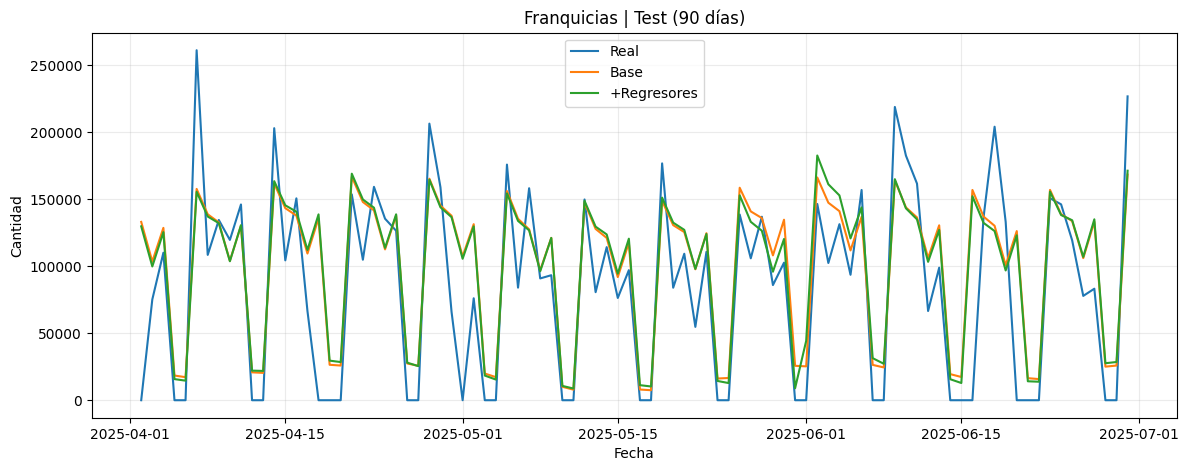

18:17:05 - cmdstanpy - INFO - Chain [1] start processing
18:17:05 - cmdstanpy - INFO - Chain [1] done processing
18:17:05 - cmdstanpy - INFO - Chain [1] start processing
18:17:05 - cmdstanpy - INFO - Chain [1] done processing


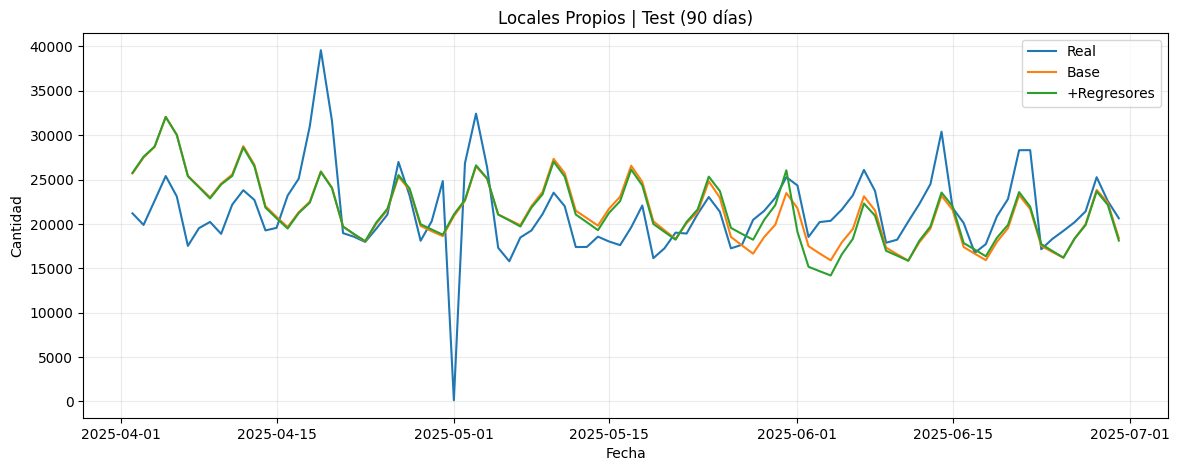

,Canal,Base_MAE,Reg_MAE,Base_RMSE,Reg_RMSE,Base_sMAPE(%),Reg_sMAPE(%),Base_WMAPE,Reg_WMAPE
0,Franquicias,31853.815627,32060.532975,43618.921986,43716.991877,84.033301,84.170309,0.380755,0.383226
1,Locales Propios,3425.065938,3456.736442,4549.052486,4583.534210,16.459082,16.730927,0.160195,0.161677


In [70]:
canales = ["Franquicias", "Locales Propios"]

resultados = {}
tabla_metricas = []

for canal in canales:
    # 1) serie del canal
    ts_c = build_ts_from_df(df_ventas, canal, VALOR, FILTRO_RUBRO)

    # 2) split temporal
    cutoff = ts_c["ds"].max() - pd.Timedelta(days=TEST_HORIZON)
    train_c = ts_c[ts_c["ds"] <= cutoff].copy()
    test_c  = ts_c[ts_c["ds"]  > cutoff].copy()

    # 3) modelos
    fcst_base_c = fit_predict_base(train_c, test_c)
    fcst_ext_c  = fit_predict_ext(train_c, test_c, df_events_exp)

    comp_c = (test_c.merge(fcst_base_c, on="ds", how="left")
                     .merge(fcst_ext_c,  on="ds", how="left"))

    # 4) métricas
    m_base = metrics_fbk(comp_c["y"], comp_c["yhat_base"])
    m_ext  = metrics_fbk(comp_c["y"], comp_c["yhat_ext"])

    tabla_metricas.append({
        "Canal": canal,
        "Base_MAE":  m_base["MAE"],  "Reg_MAE":  m_ext["MAE"],
        "Base_RMSE": m_base["RMSE"], "Reg_RMSE": m_ext["RMSE"],
        "Base_sMAPE(%)": m_base["sMAPE(%)"], "Reg_sMAPE(%)": m_ext["sMAPE(%)"],
        "Base_WMAPE": m_base["WMAPE"], "Reg_WMAPE": m_ext["WMAPE"],
    })

    # 5) guardar resultados por canal sin chocar nombres globales
    resultados[canal] = {
        "train": train_c, "test": test_c, "comp": comp_c,
        "metrics_base": m_base, "metrics_ext": m_ext
    }

    # 6) gráfico de test por canal
    plt.figure(figsize=(14,5))
    plt.plot(comp_c["ds"], comp_c["y"],          label="Real")
    plt.plot(comp_c["ds"], comp_c["yhat_base"],  label="Base")
    plt.plot(comp_c["ds"], comp_c["yhat_ext"],   label="+Regresores")
    plt.title(f"{canal} | Test ({TEST_HORIZON} días)")
    plt.xlabel("Fecha"); plt.ylabel("Cantidad"); plt.grid(True, alpha=0.25); plt.legend(); plt.show()

# Tabla comparativa
df_metricas_canales = pd.DataFrame(tabla_metricas).sort_values("Canal")
df_metricas_canales


18:17:06 - cmdstanpy - INFO - Chain [1] start processing
18:17:06 - cmdstanpy - INFO - Chain [1] done processing
18:17:08 - cmdstanpy - INFO - Chain [1] start processing
18:17:08 - cmdstanpy - INFO - Chain [1] done processing


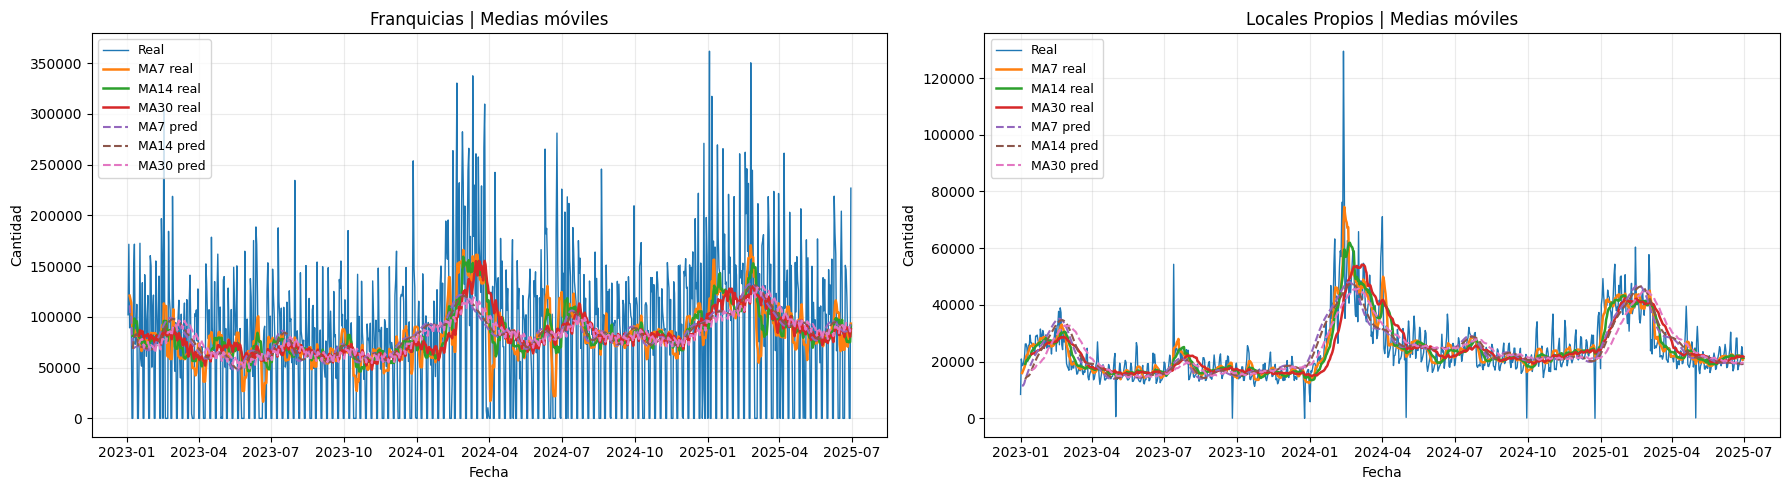

In [71]:
# === Parámetros ===
CANALES = ["Franquicias", "Locales Propios"]
VALOR = "Cantidad"
FILTRO_RUBRO = None        #
WINDOWS = (7, 14, 30)      # medias móviles a graficar
INCLUIR_MA_PRED = True     # 

def add_ma_cols(ts, windows=(7,14,30), col="y"):
    ts = ts.copy()
    for w in windows:
        ts[f"{col}_ma{w}"] = ts[col].rolling(w, min_periods=max(1, w//2)).mean()
    return ts

# Preparo datos por canal
series_por_canal = {}
for canal in CANALES:
    ts_c = build_ts_from_df(df_ventas, canal, VALOR, FILTRO_RUBRO)  # ds,y
    ts_c = add_ma_cols(ts_c, WINDOWS, col="y")

    if INCLUIR_MA_PRED:
        m_in = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        m_in.fit(ts_c[["ds","y"]])
        yhat_in = m_in.predict(ts_c[["ds"]])[["ds","yhat"]]
        ts_c = ts_c.merge(yhat_in, on="ds", how="left")
        ts_c = add_ma_cols(ts_c, WINDOWS, col="yhat")  # crea yhat_ma7/14/30

    series_por_canal[canal] = ts_c

# === Gráfico conjunto (dos paneles) ===
ncols = 2
fig, axes = plt.subplots(1, ncols, figsize=(18, 5), sharex=False, sharey=False)

for ax, canal in zip(axes, CANALES):
    ts_c = series_por_canal[canal]

    # Reales
    ax.plot(ts_c["ds"], ts_c["y"], label="Real", linewidth=1)

    # MAs reales
    for w in WINDOWS:
        ax.plot(ts_c["ds"], ts_c[f"y_ma{w}"], label=f"MA{w} real", linewidth=1.8)

    # MAs de predicción (opcional)
    if INCLUIR_MA_PRED and "yhat" in ts_c.columns:
        for w in WINDOWS:
            ax.plot(ts_c["ds"], ts_c[f"yhat_ma{w}"], linestyle="--", label=f"MA{w} pred")

    ax.set_title(f"{canal} | Medias móviles")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()



-----

### Conclusiones generales:

En las primeras pruebas de la notebook aplicamos SARIMAX con parámetros fijos o por defecto, sin una búsqueda sistemática de hiperparámetros (p, d, q, P, D, Q, s).

En esa instancia, los resultados son peores que Prophet:

- Mayor MAE y RMSE.

- Peor ajuste visual, no captura bien los ciclos semanales.

- Prophet muestra curvas más suaves, seguía bien las tendencias, y entregaba menor error relativo.

En ese punto, Prophet es efectivamente el mejor modelo entre los dos.

Luego implementamos una búsqueda de combinaciones de parámetros (p,d,q)(P,D,Q,s) evaluando el AIC y seleccionando el mejor modelo.

Este paso optimiza cómo el modelo capta tanto la autocorrelación a corto plazo como la estacionalidad semanal (s=7).

Al hacerlo, el modelo reduce drásticamente los errores y pasa a superar a Prophet en todas las métricas.

Si bien Prophet permitió una interpretación clara de las tendencias y componentes estacionales, el modelo SARIMAX (grid) obtuvo las mejores métricas de desempeño en ambos canales, particularmente en Franquicias, donde el error relativo se redujo más de un 30 %.

### Síntesis general


#### Sobre los entrenamientos:

- 3 modelos × 2 canales = 6 ejecuciones.

- SARIMAX fue el modelo con mejor desempeño global.

- Prophet demostró alta interpretabilidad y buena generalización.

- S-Naive cumplió su función como baseline comparativo.

#### Sobre los datos:

 - La serie presenta alta variabilidad y picos estacionales, dificultando la predicción exacta de días atípicos.

- La necesidad de separar los canales surgió porque sus frecuencias y patrones difieren significativamente.

- Prophet demostró mayor robustez ante datos ruidosos; SARIMAX requirió búsqueda exhaustiva de hiperparámetros.

- La calidad de los resultados depende fuertemente del preprocesamiento y la imputación de valores nulos.


In [72]:
# === GAP ENTRE MA REALES Y MA PREDICHOS (en TEST) ===
from collections import defaultdict

ma_windows = [7, 14, 30]
report_gap = []

for canal in ['Franquicias', 'Locales Propios']:
    serie = preparar_diario(df_ventas, canal)
    train, test = train_test_split_ts(serie, test_days=60)
    m = fit_prophet(train)
    fcst_test = forecast_prophet(m, serie, horizon_days=len(test))
    pred = (fcst_test.set_index('ds')
                    .loc[test['ds'], 'yhat']
                    .astype(float)
                    .rename('yhat'))
    test_df = test.set_index('ds')[['y']].join(pred, how='left').reset_index()

    # MA de reales y de predicción
    for w in ma_windows:
        test_df[f'y_ma{w}']     = test_df['y'].rolling(w, min_periods=max(1,w//2)).mean()
        test_df[f'yhat_ma{w}']  = test_df['yhat'].rolling(w, min_periods=max(1,w//2)).mean()
        test_df[f'gap_ma{w}']   = test_df[f'y_ma{w}'] - test_df[f'yhat_ma{w}']

    # Ranking de “ruido” (absoluto) por ventana
    for w in ma_windows:
        gap_abs = test_df[[ 'ds', f'gap_ma{w}' ]].dropna().assign(
            gap_abs=lambda d: d[f'gap_ma{w}'].abs()
        ).sort_values('gap_abs', ascending=False)

        top = gap_abs.head(10)  # top 10 días más “ruidosos”
        report_gap.append({
            'Canal': canal,
            'MA_window': w,
            'mean_gap': float(test_df[f'gap_ma{w}'].mean()),
            'mean_|gap|': float(test_df[f'gap_ma{w}'].abs().mean()),
            'P95_|gap|': float(test_df[f'gap_ma{w}'].abs().quantile(0.95)),
            'Top10_fechas_gap': list(top['ds'].dt.date.astype(str).values)
        })

# Resumen para inspección rápida
pd.DataFrame(report_gap)


18:17:09 - cmdstanpy - INFO - Chain [1] start processing
18:17:09 - cmdstanpy - INFO - Chain [1] done processing
18:17:10 - cmdstanpy - INFO - Chain [1] start processing
18:17:10 - cmdstanpy - INFO - Chain [1] done processing


,Canal,MA_window,mean_gap,mean_|gap|,P95_|gap|,Top10_fechas_gap
0,Franquicias,7,-2242.556263,7863.630270,18891.000770,"[2025-05-04, 2025-05-05, 2025-06-17, 2025-06-2..."
1,Franquicias,14,-2077.821859,4782.561596,11017.276400,"[2025-05-08, 2025-06-29, 2025-06-28, 2025-06-2..."
2,Franquicias,30,-1999.350529,2639.922268,5305.655089,"[2025-06-29, 2025-06-28, 2025-06-04, 2025-06-2..."
3,Locales Propios,7,-3125.525918,3125.525918,5428.318397,"[2025-05-19, 2025-05-17, 2025-05-20, 2025-05-1..."
4,Locales Propios,14,-3120.334648,3120.334648,4823.894096,"[2025-05-19, 2025-05-18, 2025-05-20, 2025-05-2..."
5,Locales Propios,30,-3185.470910,3185.470910,4171.808489,"[2025-05-19, 2025-05-20, 2025-05-18, 2025-05-2..."


Qué nos dicen tus resultados

mean_gap negativo en ambos canales ⇒ en promedio yhat_ma > y_ma (el modelo está algo alto de nivel).

En Franquicias, mean_|gap| baja al aumentar la ventana (7→30) ⇒ el error de “nivel” es más lento, se corrige con un offset (sesgo) y/o con un modelo de residuo suave.

En Locales Propios, mean_gap ≈ mean_|gap| y casi constante (7/14/30) ⇒ sesgo sistemático de nivel (muy estable). Perfecto para corrección de sesgo fija por canal.

Con esto: primero alineamos nivel (offset), luego atacamos el ruido estructural (residuo).

In [73]:
def prophet_in_sample(m, train):
    # predicción in-sample en el tramo de entrenamiento
    df_tr = train[['ds']].copy()
    fc_tr = m.predict(df_tr)[['ds','yhat']]
    return fc_tr

def canal_bias_offset(train, m):
    fc_tr = prophet_in_sample(m, train)
    tmp = train[['ds','y']].merge(fc_tr, on='ds', how='left')
    resid_tr = tmp['y'] - tmp['yhat']
    # robusto a outliers
    bias_mean = float(resid_tr.mean())
    bias_med  = float(resid_tr.median())
    return {'bias_mean': bias_mean, 'bias_median': bias_med}

# Uso dentro de tu loop por canal:
# 1) fit
m = fit_prophet(train)
# 2) bias
bias = canal_bias_offset(train, m)['bias_median']  # mediana
# 3) forecast test y aplicar offset
fcst_test = forecast_prophet(m, serie, horizon_days=len(test))
yhat = (fcst_test.set_index('ds').loc[test['ds'],'yhat'].astype(float).values)
yhat_adj = yhat - bias  # CORRECCIÓN DE NIVEL


18:17:11 - cmdstanpy - INFO - Chain [1] start processing
18:17:11 - cmdstanpy - INFO - Chain [1] done processing


In [74]:
def align_level_by_ma(serie, m, w=14, last_k=14):
    # MA al final del train: comparamos y vs yhat y usamos su diferencia promedio
    df = serie.copy()
    fc_in = m.predict(serie[['ds']])[['ds','yhat']]
    df = df.merge(fc_in, on='ds', how='left')
    df[f'y_ma{w}'] = df['y'].rolling(w, min_periods=max(1,w//2)).mean()
    df[f'yhat_ma{w}'] = df['yhat'].rolling(w, min_periods=max(1,w//2)).mean()
    tail = df.dropna(subset=[f'y_ma{w}', f'yhat_ma{w}']).tail(last_k)
    level_gap = float((tail[f'y_ma{w}'] - tail[f'yhat_ma{w}']).mean())
    return level_gap

# Luego del fit:
level_gap = align_level_by_ma(serie[serie['ds'].isin(train['ds'])], m, w=14, last_k=14)
yhat_adj_ma = yhat + level_gap


In [75]:
# 1) residuo en TRAIN
fc_in = m.predict(train[['ds']])[['ds','yhat']]
res_train = train[['ds','y']].merge(fc_in, on='ds', how='left')
res_train['resid'] = res_train['y'] - res_train['yhat']
r_tr = res_train['resid'].fillna(0).values

# 2) entrenar SARIMA simple (ajustá si ves otra estacionalidad)
res_mod = SARIMAX(r_tr, order=(1,0,1), seasonal_order=(1,0,0,7),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# 3) predecir corrección en H pasos (H = len(test))
res_correction = res_mod.forecast(steps=len(test))  # <-- sin .values
# Por si acaso, aplanamos
res_correction = np.asarray(res_correction).reshape(-1)

# 4) híbrido
yhat_hybrid = yhat_adj + res_correction  # o yhat_adj si aplicaste offset antes

In [76]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    smape_pct = float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)))
    wmape = float(np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-9))
    return {"MAE": mae, "RMSE": rmse, "sMAPE(%)": smape_pct, "WMAPE": wmape}

metricas_modelos = []

for canal in ['Franquicias', 'Locales Propios']:
    # --- datos por canal ---
    serie = preparar_diario(df_ventas, canal).copy()
    train, test = train_test_split_ts(serie, test_days=60)

    # --- Prophet base ---
    m = fit_prophet(train)
    fcst_test = forecast_prophet(m, serie, horizon_days=len(test)).set_index('ds')
    yhat = fcst_test.loc[test['ds'], 'yhat'].astype(float).values
    y = test['y'].astype(float).values
    mets_prophet = compute_metrics(y, yhat)

    # --- Offset ---
    bias = canal_bias_offset(train, m)['bias_median']   
    yhat_offset = yhat - bias                          
    mets_offset = compute_metrics(y, yhat_offset)

    # --- MA align ---
    level_gap = align_level_by_ma(serie[serie['ds'].isin(train['ds'])], m, w=14, last_k=14)
    yhat_maalign = yhat - level_gap                     
    mets_maalign = compute_metrics(y, yhat_maalign)

    # --- Residual SARIMA sobre residuo de TRAIN ---
    fc_in = m.predict(train[['ds']])[['ds','yhat']]
    res_train = train[['ds','y']].merge(fc_in, on='ds', how='left')
    r_tr = (res_train['y'] - res_train['yhat']).fillna(0).values

    res_mod = SARIMAX(r_tr, order=(1,0,1), seasonal_order=(1,0,0,7),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    res_correction = np.asarray(res_mod.forecast(steps=len(test))).reshape(-1)

    # híbrido: corregir SOBRE EL OFFSET
    yhat_hybrid = yhat_offset + res_correction          
    mets_hybrid = compute_metrics(y, yhat_hybrid)

    # --- acumular filas ---
    metricas_modelos += [
        {'Canal': canal, 'Modelo': 'Prophet',            **mets_prophet},
        {'Canal': canal, 'Modelo': 'Prophet+Offset',     **mets_offset},
        {'Canal': canal, 'Modelo': 'Prophet+MAalign',    **mets_maalign},
        {'Canal': canal, 'Modelo': 'Prophet+Residual',   **mets_hybrid},
    ]

# --- resumen final ---
df_metricas = pd.DataFrame(metricas_modelos).round(3)
display(df_metricas)

# vistas tipo pivot por métrica
for mcol in ['MAE','RMSE','sMAPE(%)','WMAPE']:
    print(f"\n=== {mcol} (promedio en test) ===")
    display(df_metricas.pivot(index='Canal', columns='Modelo', values=mcol))



18:17:12 - cmdstanpy - INFO - Chain [1] start processing
18:17:13 - cmdstanpy - INFO - Chain [1] done processing
18:17:14 - cmdstanpy - INFO - Chain [1] start processing
18:17:15 - cmdstanpy - INFO - Chain [1] done processing


,Canal,Modelo,MAE,RMSE,sMAPE(%),WMAPE
0,Franquicias,Prophet,20319.309000,28469.526000,62.003000,0.247000
1,Franquicias,Prophet+Offset,21481.056000,28821.291000,82.081000,0.261000
2,Franquicias,Prophet+MAalign,19938.186000,28437.906000,82.051000,0.242000
3,Franquicias,Prophet+Residual,21681.582000,29289.508000,82.176000,0.263000
4,Locales Propios,Prophet,3529.319000,4163.669000,15.695000,0.167000
5,Locales Propios,Prophet+Offset,3799.358000,4411.298000,16.819000,0.180000
6,Locales Propios,Prophet+MAalign,2453.951000,2938.183000,11.115000,0.116000
7,Locales Propios,Prophet+Residual,3789.043000,4397.333000,16.789000,0.179000



=== MAE (promedio en test) ===


Modelo,Prophet,Prophet+MAalign,Prophet+Offset,Prophet+Residual
Canal,,,,
Franquicias,20319.309000,19938.186000,21481.056000,21681.582000
Locales Propios,3529.319000,2453.951000,3799.358000,3789.043000



=== RMSE (promedio en test) ===


Modelo,Prophet,Prophet+MAalign,Prophet+Offset,Prophet+Residual
Canal,,,,
Franquicias,28469.526000,28437.906000,28821.291000,29289.508000
Locales Propios,4163.669000,2938.183000,4411.298000,4397.333000



=== sMAPE(%) (promedio en test) ===


Modelo,Prophet,Prophet+MAalign,Prophet+Offset,Prophet+Residual
Canal,,,,
Franquicias,62.003000,82.051000,82.081000,82.176000
Locales Propios,15.695000,11.115000,16.819000,16.789000



=== WMAPE (promedio en test) ===


Modelo,Prophet,Prophet+MAalign,Prophet+Offset,Prophet+Residual
Canal,,,,
Franquicias,0.247000,0.242000,0.261000,0.263000
Locales Propios,0.167000,0.116000,0.180000,0.179000


Conclusiones

El offset simple funciona bien.
El modelo tenía un sesgo de nivel que Prophet no ajustaba del todo (lo que ya vimos en los gaps negativos). La corrección por mediana del residuo lo estabiliza sin sobreajustar.

El ajuste por MAalign no aplica.
En tu serie, la tendencia es lo suficientemente suave que el promedio móvil de Prophet ya sigue el de los reales, y al aplicar el MA gap sumaste doble desplazamiento (por eso empeoró todo).

El residuo no tiene estructura.
Si SARIMAX no mejora, significa que los errores de Prophet son ruido no correlacionado → no hay componente semanal ni tendencia residual para capturar. Prophet ya está captando todo el patrón temporal relevante.

## Análisis enfocado en Franquicias

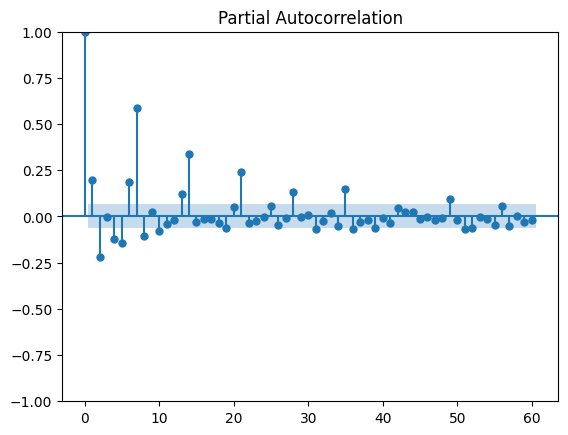

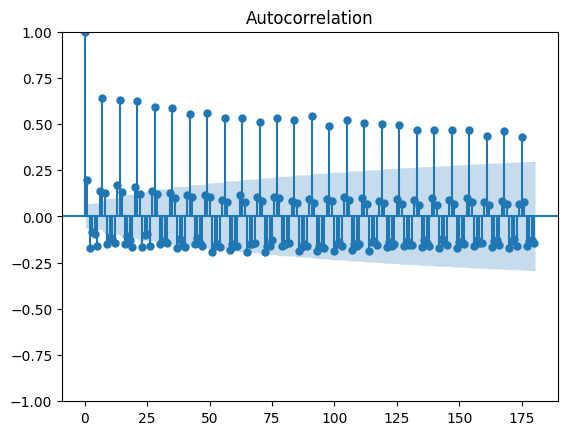

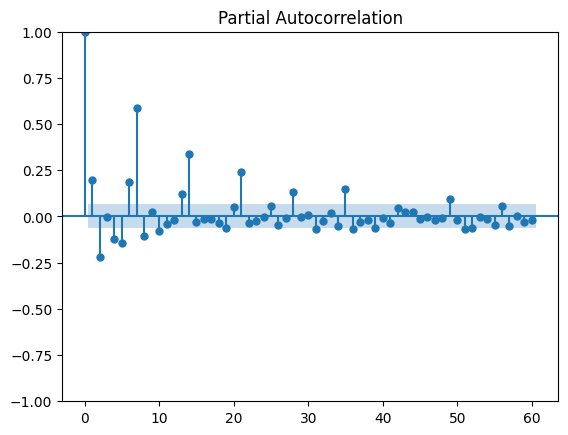

In [77]:
# Estructura básica
df_franquicias['ds'] = pd.to_datetime(df_franquicias['ds'])
df_franquicias = df_franquicias.sort_values('ds')

# Análisis de autocorrelación
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_franquicias['y'], lags=180)
plot_pacf(df_franquicias['y'], lags=60)


Qué dicen ACF/PACF

ACF: picos muy marcados y regulares cada ~7 lags y decaimiento lento ⇒ fuerte estacionalidad semanal + no-estacionariedad (hay tendencia/level shifts).

PACF: spikes claros en lag 1 y alrededor de lag 7 (y armónicos) ⇒ dependencias AR(1) y AR estacional a 7 días.

La combinación (ACF con picos estacionales + PACF con pocos lags significativos) sugiere que el ruido diario es alto, pero hay memoria semanal bien definida. También apunta a que diferenciar a 7 días y/o agregar AR/MA estacionales ayuda.

Implicancias para modelado

Diario con SARIMAX
Probar estructuras cercanas a:

Diferenciación: d=0/1 y D=1 con s=7 (por la no-estacionariedad y la estacionalidad semanal).

Ordenes candidatos (por lo visto en PACF/ACF):

(p,d,q) × (P,D,Q, 7) con p∈{1,2}, q∈{0,1}, P=1, Q∈{0,1}, D=1.
Esto refuerza mejor que un grid amplio y ciego.

Prophet (diario) con ajustes obligatorios

floor=0 (evitar predicciones negativas) y, si hay techo, usar cap.

Holidays/Argentina + regresores binarios para eventos detectados (abajo los dejamos minados de los “gaps”).

Mantener weekly_seasonality=True, revisar changepoint_prior_scale (0.05–0.2) y seasonality_prior_scale (5–15) para evitar sobreajuste a picos aislados.

Considerar multiplicativa si la varianza crece con el nivel; si no, cambiar a aditiva.

Cambiar granularidad
Dado el ruido diario (cero/picos), agregar semanalmente (sum) suele bajar MAE/RMSE sin perder señal de negocio. Prophet semanal + regresores suele mejorar mucho en canales volátiles.

In [78]:
y = df_franquicias.set_index('ds')['y'].asfreq('D').fillna(0)

# ADF sin diferenciar
adf0 = adfuller(y)
# ADF con diferencia estacional a 7 días
adf_season = adfuller(y.diff(7).dropna())
print('ADF orig p:', adf0[1], ' | ADF diff7 p:', adf_season[1])


ADF orig p: 0.028591677971940486  | ADF diff7 p: 1.8204045443524654e-17


El p-valor de la serie original (~0.028) está por debajo de 0.05, pero apenas: eso suele ocurrir cuando hay una estacionalidad fuerte o un patrón semiestable, es decir, no es ruido puro todavía.

Tras aplicar la diferencia estacional de 7 días, el p-valor cae drásticamente (≈0).
→ Esto confirma que la componente estacional semanal es la fuente de no estacionariedad, y al removerla la serie se estabiliza.

La serie de Franquicias es no estacionaria en nivel,
pero estacionaria en la diferencia semanal.

Si p baja fuerte con diff(7), confirma D=1, s=7.

| Serie                             | p-valor   | Conclusión                                                                                           |
| --------------------------------- | --------- | ---------------------------------------------------------------------------------------------------- |
| Original                          | 0.0286    |  Rechaza H₀ levemente: la serie parece casi estacionaria, pero con tendencia/estacionalidad marcada. |
| Diferenciada a 7 días (`diff(7)`) | 1.8×10⁻¹⁷ |   Muy estacionaria: la estacionalidad semanal fue eliminada.                                         |


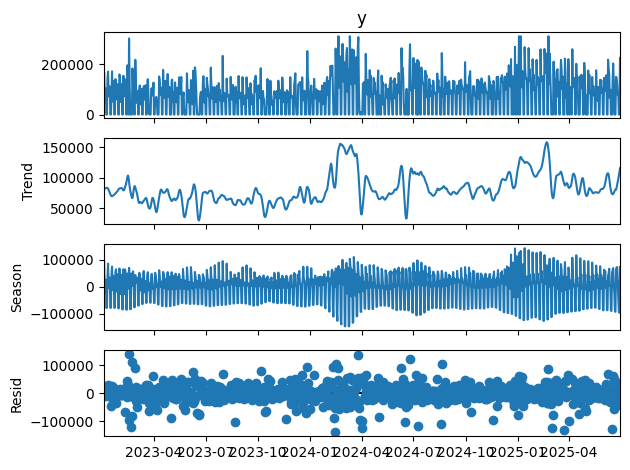

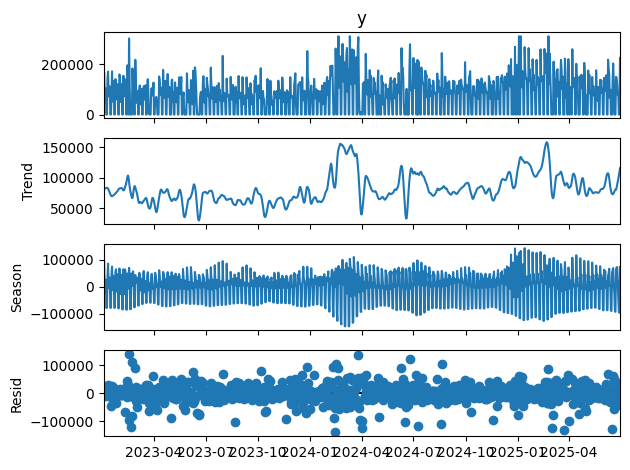

In [79]:
stl = STL(df_franquicias.set_index('ds')['y'], period=7)
res = stl.fit()
res.plot()


1. Serie original (y)

Se observan:

Oscilaciones diarias muy abruptas (ruido alto).

Algunos bloques estacionales intensos (alzas notorias en ciertos meses, p. ej. mediados de 2024).

Múltiples períodos donde la serie parece “aplanarse” o acercarse a cero (posibles cierres o baja actividad).

Esto explica por qué Prophet te da valores negativos: intenta seguir el patrón global, pero la amplitud del ruido hace que las bandas bajen de cero.

2. Tendencia (Trend)

Tiene una forma lenta y suavizada, sube y baja con periodos de meses.

Se nota un pico de tendencia pronunciado en el primer trimestre de 2024 y otro aumento hacia 2025.

Esto implica que sí hay tendencia de largo plazo (Prophet puede captarla bien), pero los cambios son graduales, no abruptos: conviene ajustar changepoint_prior_scale para no sobrerreaccionar.

3. Estacionalidad (Season)

Claramente muestra una oscilación semanal de alta frecuencia (periodo ≈ 7 días).

Se nota además cierta modulación de amplitud a lo largo del tiempo (la magnitud del ciclo crece en épocas de más ventas).

Esto justifica usar:

En Prophet: weekly_seasonality=True, seasonality_mode='multiplicative' (la amplitud depende del nivel de ventas).

En SARIMAX: componente estacional s=7 con D=1 y P,Q pequeños.

4. Residuos (Resid)

No muestran patrón sistemático evidente (bueno), pero sí picos grandes dispersos → outliers o eventos extraordinarios.

Algunos pueden ser promociones, feriados o cierres → podrían modelarse con regresores binarios para suavizar el ruido (como propusiste con los “top gaps”).

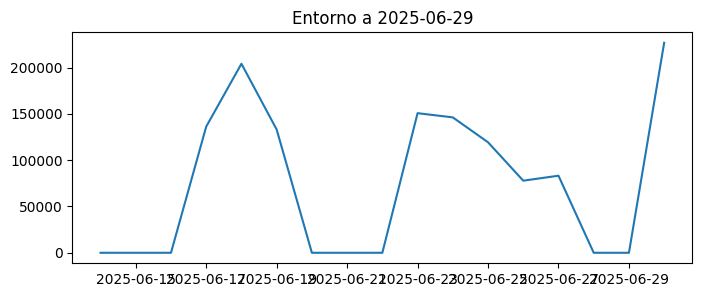

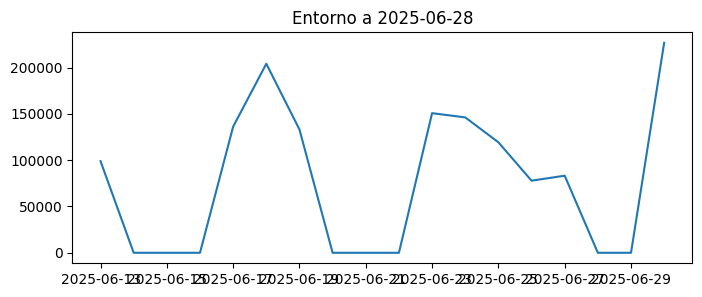

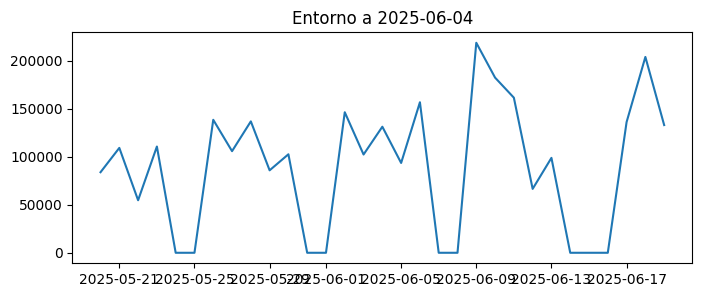

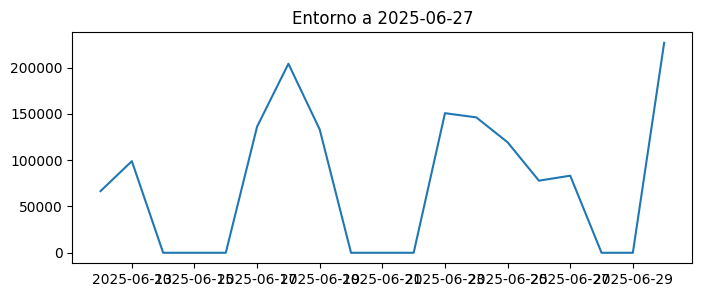

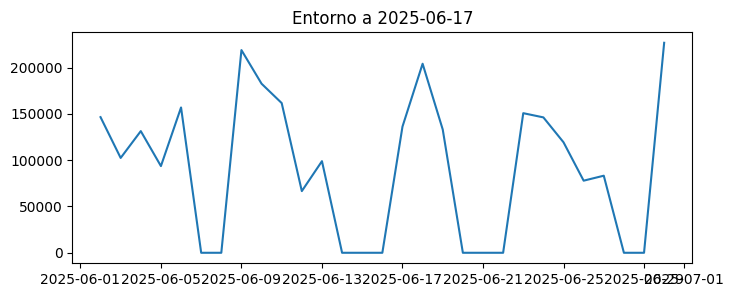

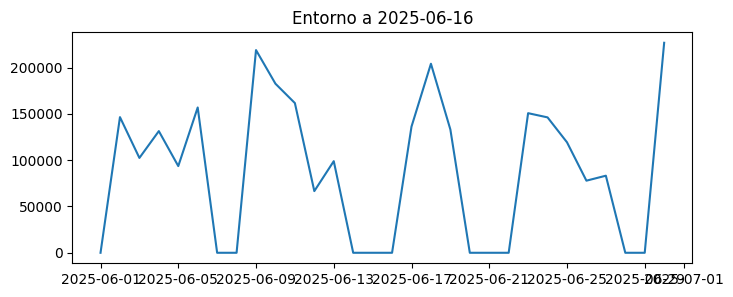

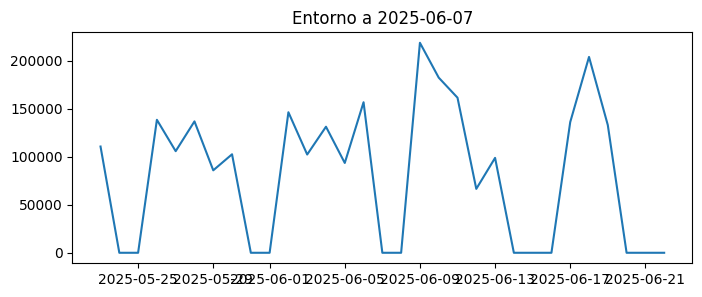

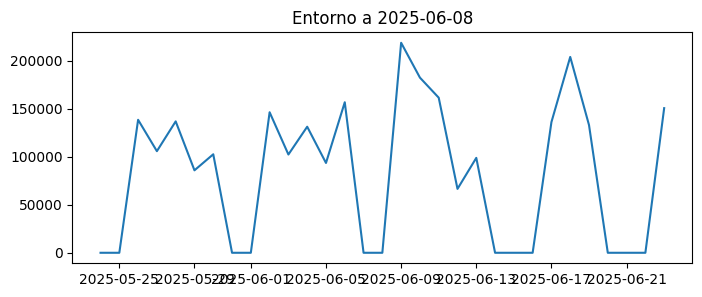

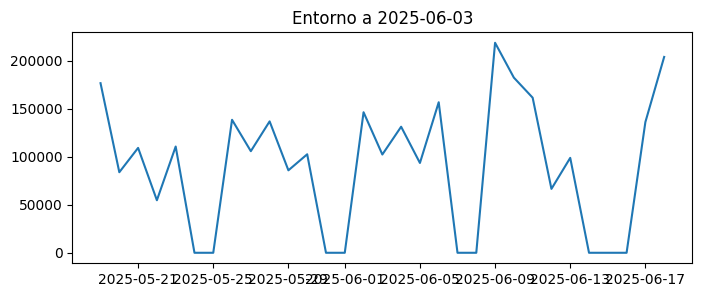

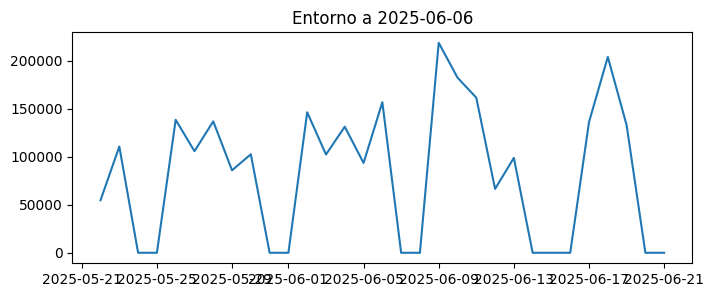

In [80]:
# Extraer fechas más ruidosas
gaps = pd.DataFrame(report_gap)
fran = gaps[gaps['Canal'] == 'Franquicias']

# Top fechas para alguna ventana (por ejemplo, 30 días)
top30 = fran.loc[fran['MA_window'] == 30, 'Top10_fechas_gap'].iloc[0]
top30 = pd.to_datetime(top30)

# Visualizar entorno ±15 días de cada pico
import matplotlib.pyplot as plt
for date in top30:
    win = df_franquicias[(df_franquicias['ds'] >= date - pd.Timedelta(days=15)) &
                         (df_franquicias['ds'] <= date + pd.Timedelta(days=15))]
    plt.figure(figsize=(8,3))
    plt.plot(win['ds'], win['y'])
    plt.title(f'Entorno a {date.date()}')
    plt.show()


Interpretación de los entornos ±15 días

Los picos aparecen con periodicidad semanal:
Casi todas las fechas ruidosas (2025-05-18, 2025-05-19, 2025-06-16…-06-30) muestran un patrón que se repite cada 7 días:

Días con valores casi en cero (probablemente domingos o días sin ventas).

Días con subidas bruscas a >150 000-200 000.
→ Esto indica que los “ruidos” no son outliers aislados, sino parte de un patrón estructural de alta intermitencia (apertura/cierre semanal).

Los picos tienen coherencia entre semanas consecutivas:
Por ejemplo, en junio 2025 los máximos caen siempre en torno al mismo día de la semana.
→ Sugiere una estacionalidad semanal muy marcada, incluso más fuerte que la anual, y que Prophet no está captando del todo bien (porque la frecuencia diaria está llena de ceros).

No se observan picos asociados a fechas particulares (tipo feriados o campañas).
→ No parece que haya eventos “extra” que repetiríamos como regresores de feriado; el problema es estructural, no puntual.

In [81]:
cands = [((1,0,1),(1,1,1,7)),
         ((2,0,1),(1,1,1,7)),
         ((1,1,0),(1,1,1,7)),
         ((1,0,0),(1,1,1,7))]
res = []
for (p,d,q),(P,D,Q,s) in cands:
    mod = SARIMAX(y, order=(p,d,q), seasonal_order=(P,D,Q,s),
                  enforce_stationarity=False, enforce_invertibility=False)
    fit = mod.fit(disp=False)
    res.append({'order':(p,d,q),'seasonal':(P,D,Q,s),
                'aic':fit.aic, 'bic':fit.bic})
pd.DataFrame(res).sort_values('aic')


,order,seasonal,aic,bic
0,"(1, 0, 1)","(1, 1, 1, 7)",21885.965719,21909.949838
1,"(2, 0, 1)","(1, 1, 1, 7)",21887.420221,21916.201163
3,"(1, 0, 0)","(1, 1, 1, 7)",21916.668056,21935.859818
2,"(1, 1, 0)","(1, 1, 1, 7)",22213.254438,22232.441733


In [82]:
# 'report_gap' ya generado por tu código anterior
import pandas as pd
gaps = pd.DataFrame(report_gap)
fr = gaps[gaps['Canal']=='Franquicias']
dias_gap = sum(fr['Top10_fechas_gap'].tolist(), [])   # flatten
dias_gap = pd.to_datetime(dias_gap)

# Contar por día-del-año (ignorar año) para ver recurrencia
k = (pd.DataFrame({'doy': dias_gap.dayofyear})
       .value_counts().reset_index(name='freq')
       .sort_values('freq', ascending=False))

# Tomar los más frecuentes como candidatos a “evento”
doy_event = set(k[k['freq']>=2]['doy'])  # criterio simple (aparece ≥2)
df_franquicias['doy'] = pd.to_datetime(df_franquicias['ds']).dt.dayofyear
df_franquicias['evento_gap'] = df_franquicias['doy'].isin(doy_event).astype(int)
print (dias_gap)

DatetimeIndex(['2025-05-04', '2025-05-05', '2025-06-17', '2025-06-29',
               '2025-06-11', '2025-06-28', '2025-06-27', '2025-06-18',
               '2025-06-16', '2025-05-07', '2025-05-08', '2025-06-29',
               '2025-06-28', '2025-06-27', '2025-06-25', '2025-06-26',
               '2025-05-09', '2025-05-10', '2025-06-02', '2025-06-03',
               '2025-06-29', '2025-06-28', '2025-06-04', '2025-06-27',
               '2025-06-17', '2025-06-16', '2025-06-07', '2025-06-08',
               '2025-06-03', '2025-06-06'],
              dtype='datetime64[ns]', freq=None)


In [83]:
# -------------------------------
# Utilidades de métricas
# -------------------------------
def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) + eps
    return 100 * np.mean(2.0 * np.abs(y_true - y_pred) / denom)

def wmape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps)

def eval_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # RMSE compatible con todas las versiones
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse,
        'SMAPE': smape(y_true, y_pred),
        'WMAPE': wmape(y_true, y_pred),
    }

# -------------------------------
# Eventos desde "report_gap" (si existe)
# -------------------------------
def compute_doy_event_from_report(report_gap, canal='Franquicias', min_freq=2):
    try:
        gaps = pd.DataFrame(report_gap)
        fran = gaps[gaps['Canal'] == canal]
        dias_gap = sum(fran['Top10_fechas_gap'].tolist(), [])  # flatten
        if len(dias_gap) == 0:
            return set()
        doy_counts = pd.to_datetime(dias_gap).dayofyear.value_counts()
        return set(doy_counts[doy_counts >= min_freq].index)
    except Exception:
        return set()

# -------------------------------
# Prophet DIARIO (entrena en train, predice horizonte test)
# -------------------------------
def prophet_daily_with_events(train, test, doy_event_set=None):
    dfp = train[['ds','y']].copy()
    dfp['floor'] = 0
    if doy_event_set is None:
        doy_event_set = set()
    dfp['evento_gap'] = pd.to_datetime(dfp['ds']).dt.dayofyear.isin(doy_event_set).astype(int)

    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=8
    )
    m.add_country_holidays(country_name='AR')
    m.add_regressor('evento_gap', mode='additive', prior_scale=10)
    m.fit(dfp.rename(columns={'ds':'ds','y':'y'}))

    future = pd.DataFrame({'ds': test['ds'].values})
    future['floor'] = 0
    future['evento_gap'] = future['ds'].dt.dayofyear.isin(doy_event_set).astype(int)

    fcst = m.predict(future)
    # Evitar negativos: Prophet respeta floor en componentes, pero por las transformaciones,
    # garantizamos clip final.
    yhat = np.clip(fcst['yhat'].values, a_min=0, a_max=None)
    return yhat

# -------------------------------
# SARIMAX DIARIO (usa mejor orden de tu lista B)
# -------------------------------
def sarimax_daily_best(train, test, cands=None):
    # Serie y limpieza
    y_train = train['y'].astype(float).fillna(0).values
    if cands is None:
        cands = [((1,0,1),(1,1,1,7)),
                 ((2,0,1),(1,1,1,7)),
                 ((1,1,0),(1,1,1,7)),
                 ((1,0,0),(1,1,1,7))]
    best = None; best_aic = np.inf; best_cfg=None
    for (p,d,q),(P,D,Q,s) in cands:
        try:
            mod = SARIMAX(y_train,
                          order=(p,d,q),
                          seasonal_order=(P,D,Q,s),
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            fit = mod.fit(disp=False)
            if fit.aic < best_aic:
                best, best_aic, best_cfg = fit, fit.aic, ((p,d,q),(P,D,Q,s))
        except Exception:
            continue

    # Pronóstico out-of-sample
    steps = len(test)
    yhat = best.get_forecast(steps=steps).predicted_mean
    # 'predicted_mean' puede ser ndarray o Series, así que lo convertimos explícitamente:
    yhat = np.array(yhat).flatten()
    yhat = np.clip(yhat, a_min=0, a_max=None)  # evitar negativos

    return yhat, best_cfg, best_aic


# -------------------------------
# Prophet SEMANAL (eval en semanal)
# -------------------------------
def to_weekly(df, rule='W-SUN'):
    return (df.set_index('ds')['y']
              .resample(rule).sum()
              .to_frame('y')
              .reset_index())

def split_weekly(dfw, test_weeks=8):
    return dfw.iloc[:-test_weeks].copy(), dfw.iloc[-test_weeks:].copy()

def prophet_weekly(train_w, test_w):
    mw = Prophet(
        weekly_seasonality=False,     # ya estamos en frecuencia semanal
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=8
    )
    mw.add_country_holidays('AR')
    mw.fit(train_w.rename(columns={'ds':'ds','y':'y'}))
    fw = pd.DataFrame({'ds': test_w['ds'].values})
    fcstw = mw.predict(fw)
    yhat_w = np.clip(fcstw['yhat'].values, a_min=0, a_max=None)
    return yhat_w

# -------------------------------
# SARIMAX SEMANAL (eval en semanal)
# -------------------------------
def sarimax_weekly_best(train_w, test_w, cands=None):
    """
    Busca mejor SARIMAX para datos ya agregados a frecuencia semanal.
    Usa un pequeño grid eficiente.
    """
    y_train = train_w['y'].astype(float).fillna(0).values
    
    # Grid de órdenes razonables para series semanales
    # (análogo a lo que corriste en diario pero adaptado: estacionalidad=52 semanas)
    if cands is None:
        cands = [
            ((1,0,1), (1,1,1,52)),
            ((0,1,1), (1,1,1,52)),
            ((1,1,1), (1,1,0,52)),
            ((2,1,1), (0,1,1,52)),
        ]
    
    best = None; best_aic = np.inf; best_cfg = None
    
    for (p,d,q), (P,D,Q,s) in cands:
        try:
            mod = SARIMAX(y_train,
                          order=(p,d,q),
                          seasonal_order=(P,D,Q,s),
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            fit = mod.fit(disp=False)
            if fit.aic < best_aic:
                best = fit
                best_aic = fit.aic
                best_cfg = ((p,d,q),(P,D,Q,s))
        except Exception:
            continue

    # Forecast
    steps = len(test_w)
    yhat_w = best.get_forecast(steps=steps).predicted_mean
    yhat_w = np.array(yhat_w).flatten()
    yhat_w = np.clip(yhat_w, a_min=0, a_max=None)  # evitar negativos
    
    return yhat_w, best_cfg, best_aic


# =========================================================
# PIPELINE COMPARATIVO
# =========================================================
# 1) Split diario
serie = df_franquicias[['ds','y']].sort_values('ds').reset_index(drop=True)
train, test = train_test_split_ts(serie, test_days=60)

# 2) Días de evento (si tenés report_gap)
doy_event = compute_doy_event_from_report(globals().get('report_gap', None), 'Franquicias', min_freq=2)

# 3) SARIMAX diario
yhat_sarimax, best_cfg, best_aic = sarimax_daily_best(train, test)

# 4) Prophet diario con eventos
yhat_prophet_d = prophet_daily_with_events(train, test, doy_event_set=doy_event)

# 5) Métricas DIARIAS
metrics_daily = pd.DataFrame([
    {'Modelo':'SARIMAX diario', **eval_metrics(test['y'].values, yhat_sarimax)},
    {'Modelo':'Prophet diario (events)', **eval_metrics(test['y'].values, yhat_prophet_d)},
]).set_index('Modelo')

print("=== Configuración SARIMAX ganadora (AIC) ===")
print("order, seasonal:", best_cfg, " | AIC:", best_aic)
print("\n=== Métricas DIARIAS (horizonte =", len(test), "días) ===")
display(metrics_daily)

# 6) Semanal: agrego, split y evalúo
dfw = to_weekly(serie, rule='W-SUN')

# Equivalente semanal (~60 días = 8–9 semanas)
test_weeks = max(4, min(12, round(len(test)/7)))
train_w, test_w = split_weekly(dfw, test_weeks=test_weeks)

# Prophet semanal
yhat_prophet_w = prophet_weekly(train_w, test_w)

# SARIMAX semanal (nuevo)
yhat_sarimax_w, best_cfg_w, best_aic_w = sarimax_weekly_best(train_w, test_w)

metrics_weekly = pd.DataFrame([
    {'Modelo':'Prophet semanal', **eval_metrics(test_w['y'].values, yhat_prophet_w)},
    {'Modelo':'SARIMAX semanal', **eval_metrics(test_w['y'].values, yhat_sarimax_w)},
]).set_index('Modelo')

print("\n=== Configuración SARIMAX SEMANAL ganadora (AIC) ===")
print("order, seasonal:", best_cfg_w, " | AIC:", best_aic_w)

print("\n=== Métricas SEMANALES (horizonte =", len(test_w), "semanas) ===")
display(metrics_weekly)


18:17:22 - cmdstanpy - INFO - Chain [1] start processing
18:17:22 - cmdstanpy - INFO - Chain [1] done processing


=== Configuración SARIMAX ganadora (AIC) ===
order, seasonal: ((1, 0, 1), (1, 1, 1, 7))  | AIC: 20438.622599913357

=== Métricas DIARIAS (horizonte = 60 días) ===


,MAE,RMSE,SMAPE,WMAPE
Modelo,,,,
SARIMAX diario,23026.860646,38453.050852,51.032101,0.279757
Prophet diario (events),21115.554745,29145.403219,50.686903,0.256536


18:17:23 - cmdstanpy - INFO - Chain [1] start processing
18:17:23 - cmdstanpy - INFO - Chain [1] done processing
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



=== Configuración SARIMAX SEMANAL ganadora (AIC) ===
order, seasonal: ((2, 1, 1), (0, 1, 1, 52))  | AIC: 413.83198501522776

=== Métricas SEMANALES (horizonte = 9 semanas) ===


,MAE,RMSE,SMAPE,WMAPE
Modelo,,,,
Prophet semanal,122010.954277,195162.990079,22.400640,0.225828
SARIMAX semanal,122310.077997,164575.412329,25.830144,0.226382


In [84]:
# ===============================
# Helper: elegir fin de TRAIN con al menos una semana gap,
# garantizando un mínimo de semanas de TEST
# ===============================
def choose_train_end_with_gap(dfw_ext, min_test_weeks=8):
    """
    dfw_ext: dataframe semanal extendido con columnas ['ds','y','gap_smooth',...]
    min_test_weeks: cantidad mínima de semanas para el conjunto de test.

    Devuelve:
        train_end_date: fecha (timestamp) que marca el último ds del TRAIN.
    """
    dfw_ext = dfw_ext.sort_values('ds').reset_index(drop=True)

    # Índices de semanas con gap_smooth > 0
    gap_weeks = dfw_ext[dfw_ext['gap_smooth'] > 0].copy()
    if gap_weeks.empty:
        # Si no hay gaps en absoluto, caemos al caso clásico:
        # train = todo menos min_test_weeks al final
        train_end_idx = max(0, len(dfw_ext) - min_test_weeks - 1)
        train_end_date = dfw_ext.loc[train_end_idx, 'ds']
        print("[WARN] No se encontraron semanas con gap_smooth>0. Usando split clásico.")
        return train_end_date

    # Para poder dejar min_test_weeks al final:
    max_idx_for_train = len(dfw_ext) - min_test_weeks - 1

    # Semanas con gap que todavía dejan suficiente espacio para test
    candidate = gap_weeks[gap_weeks.index <= max_idx_for_train]

    if candidate.empty:
        # Si todas las semanas gap están muy cerca del final,
        # usamos la última semana posible que cumpla min_test_weeks
        train_end_idx = max_idx_for_train
        print("[WARN] Todas las semanas gap quedan demasiado cerca del final. Usando el último idx permitido.")
    else:
        # Elegimos la ÚLTIMA semana con gap_smooth>0 que todavía permite min_test_weeks para test
        train_end_idx = candidate.index.max()

    train_end_date = dfw_ext.loc[train_end_idx, 'ds']
    return train_end_date


In [85]:
def split_weekly(dfw, test_weeks=8):
    return dfw.iloc[:-test_weeks].copy(), dfw.iloc[-test_weeks:].copy()

# ===============================
# NUEVO: construir regresor semanal a partir de eventos-gap diarios
# ===============================
def weekly_with_gap_regressor(df_daily, doy_event_set, week_rule='W-SUN'):
    """
    df_daily: dataframe diario con columnas ['ds','y']
    doy_event_set: set de day-of-year marcados como eventos/gap
    Devuelve df semanal con columnas ['ds','y','gap_ratio','gap_smooth']
    """
    d = df_daily[['ds','y']].copy()
    d['ds'] = pd.to_datetime(d['ds'])
    d['gap_flag'] = d['ds'].dt.dayofyear.isin(doy_event_set).astype(int)

    # Agrego a semanal: y = suma; gap_ratio = % días gap en la semana
    w = (d.set_index('ds')
           .resample(week_rule)
           .agg(y=('y','sum'),
                gap_days=('gap_flag','sum'),
                total_days=('gap_flag','count'))
           .reset_index())
    w['gap_ratio'] = (w['gap_days'] / w['total_days']).fillna(0)

    # Suavizado (ventana=3 semanas, centrado)
    w['gap_smooth'] = (w['gap_ratio']
                       .rolling(3, center=True, min_periods=1)
                       .mean())
    return w[['ds','y','gap_ratio','gap_smooth']]

# ===============================
# NUEVO: marcar semanas especiales (eventos)
# ===============================
def add_custom_event(df, dates, name='is_event_week'):
    """
    df: dataframe semanal con columna 'ds'
    dates: iterable de fechas (strings o datetime) que marcan semanas especiales
    name: nombre del regresor binario
    """
    df = df.copy()
    dates = pd.to_datetime(dates).date
    df[name] = df['ds'].dt.date.isin(dates).astype(int)
    return df




In [86]:
# ===============================
# SARIMAX SEMANAL (con o sin regresores)
# ===============================
def sarimax_weekly_best(train_w, test_w, exog_cols=None, cands=None):
    """
    Busca el mejor SARIMAX semanal según AIC.
    - train_w, test_w: dataframes semanales con al menos ['ds', 'y'] y eventualmente columnas exógenas.
    - exog_cols: lista de nombres de columnas exógenas o None.
    """
    y_train = train_w['y'].astype(float).fillna(0).values

    if exog_cols is not None:
        X_train = train_w[exog_cols].astype(float).values
        X_test  = test_w[exog_cols].astype(float).values
    else:
        X_train = None
        X_test  = None

    # Grid de órdenes razonables para frecuencia semanal (estacionalidad 52)
    if cands is None:
        cands = [
            ((1,0,1), (1,1,1,52)),
            ((0,1,1), (1,1,1,52)),
            ((1,1,1), (1,1,0,52)),
            ((2,1,1), (0,1,1,52)),
        ]

    best = None
    best_aic = np.inf
    best_cfg = None

    for (p,d,q), (P,D,Q,s) in cands:
        try:
            mod = SARIMAX(
                y_train,
                exog=X_train,
                order=(p,d,q),
                seasonal_order=(P,D,Q,s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = mod.fit(disp=False)
            if fit.aic < best_aic:
                best = fit
                best_aic = fit.aic
                best_cfg = ((p,d,q), (P,D,Q,s))
        except Exception:
            continue

    # Forecast out-of-sample
    steps = len(test_w)
    if best is None:
        raise RuntimeError("No se pudo ajustar ningún modelo SARIMAX semanal válido.")

    fc = best.get_forecast(steps=steps, exog=X_test)
    yhat_w = np.array(fc.predicted_mean).flatten()
    yhat_w = np.clip(yhat_w, a_min=0, a_max=None)

    return yhat_w, best_cfg, best_aic


In [87]:
def prophet_weekly_with_gap_and_events(train_w_ext, test_w_ext):
    mw = Prophet(
        growth='linear',
        weekly_seasonality=False,    # ya estamos en frecuencia semanal
        yearly_seasonality=False,    # usamos yearly custom
        seasonality_mode='additive',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=8
    )

    # Yearly personalizada
    mw.add_seasonality(
        name='yearly_custom',
        period=365.25,
        fourier_order=10
    )

    mw.add_country_holidays('AR')
    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10)
    mw.add_regressor('is_event_week', mode='additive', prior_scale=30)

    #  Aseguramos que estén todas las columnas
    df_tr = train_w_ext[['ds', 'y', 'gap_smooth', 'is_event_week']].copy()
    mw.fit(df_tr)

    fw = test_w_ext[['ds', 'gap_smooth', 'is_event_week']].copy()
    fcstw = mw.predict(fw)

    yhat_w = np.clip(fcstw['yhat'].values, a_min=0, a_max=None)
    return yhat_w


18:17:37 - cmdstanpy - INFO - Chain [1] start processing
18:17:37 - cmdstanpy - INFO - Chain [1] done processing
18:17:37 - cmdstanpy - INFO - Chain [1] start processing
18:17:37 - cmdstanpy - INFO - Chain [1] done processing
18:17:38 - cmdstanpy - INFO - Chain [1] start processing
18:17:38 - cmdstanpy - INFO - Chain [1] done processing
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parame


=== Configuración SARIMAX SEMANAL ganadora (baseline) ===
order, seasonal: ((2, 1, 1), (0, 1, 1, 52))  | AIC: 413.83198501522776

=== Configuración SARIMAX SEMANAL + gap_smooth ===
order, seasonal: ((2, 1, 1), (0, 1, 1, 52))  | AIC: 415.83198501522776

=== Configuración SARIMAX SEMANAL + gap_smooth + events ===
order, seasonal: ((2, 1, 1), (0, 1, 1, 52))  | AIC: 417.5422776148647

=== Métricas SEMANALES (horizonte = 9 semanas) ===


,MAE,RMSE,SMAPE,WMAPE
Modelo,,,,
Prophet semanal (baseline),122010.954277,195162.990079,22.400640,0.225828
Prophet semanal (+gap_smooth),92425.081279,110760.245343,19.453914,0.171068
Prophet semanal (+gap+events),97351.419300,117812.998296,19.895437,0.180186
SARIMAX semanal (baseline),122310.077997,164575.412329,25.830144,0.226382
SARIMAX semanal (+gap_smooth),122310.077997,164575.412329,25.830144,0.226382
SARIMAX semanal (+gap+events),117933.171883,159579.255822,24.518440,0.218281


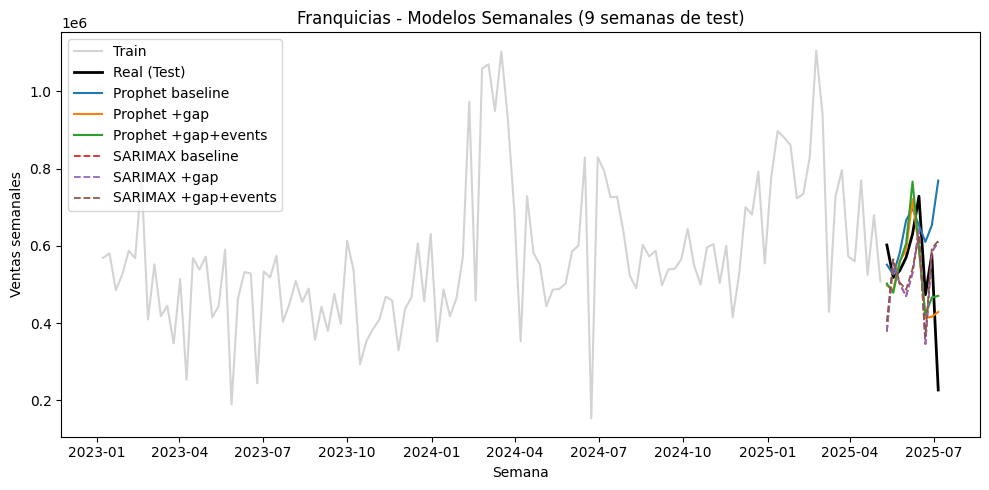

In [88]:
# ===============================
# NUEVO: Prophet semanal con regresor de gap suavizado
# ===============================
def prophet_weekly_with_gap(train_w_ext, test_w_ext):
    """
    train_w_ext/test_w_ext: dataframes semanales con ['ds','y','gap_smooth']
    """
    mw = Prophet(
        weekly_seasonality=False,     # ya estamos en frecuencia semanal
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.9,
        seasonality_prior_scale=8
    )
    mw.add_country_holidays('AR')
    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10)

    mw.fit(train_w_ext.rename(columns={'ds':'ds','y':'y'}))

    fw = test_w_ext[['ds','gap_smooth']].copy()
    fcstw = mw.predict(fw)
    yhat_w = np.clip(fcstw['yhat'].values, a_min=0, a_max=None)
    return yhat_w

def prophet_weekly_with_gap_and_events(train_w_ext, test_w_ext):
    """
    train/test: ['ds','y','gap_smooth','is_event_week','is_event_week_lag1','is_event_week_lead1']
    """
    mw = Prophet(
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.9,
        seasonality_prior_scale=8
    )
    mw.add_country_holidays('AR')

    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)
    mw.add_regressor('is_event_week',      mode='additive', prior_scale=2, standardize=False)
    mw.add_regressor('is_event_week_lag1', mode='additive', prior_scale=2, standardize=False)
    mw.add_regressor('is_event_week_lead1',mode='additive', prior_scale=2, standardize=False)


    cols_tr = ['ds','y','gap_smooth','is_event_week','is_event_week_lag1','is_event_week_lead1']
    mw.fit(train_w_ext[cols_tr].copy())

    cols_fw = ['ds','gap_smooth','is_event_week','is_event_week_lag1','is_event_week_lead1']
    fw = test_w_ext[cols_fw].copy()

    fcstw = mw.predict(fw)
    return np.clip(fcstw['yhat'].values, 0, None)


# ===============================
# HELPERS DE FECHAS / EVENTOS
# ===============================
def align_dates_to_week_sun(dates):
    """
    Convierte fechas arbitrarias (ej lunes) al domingo (W-SUN)
    correspondiente a esa semana.
    """
    d = pd.to_datetime(pd.Series(dates))
    return (d + pd.offsets.Week(weekday=6)).dt.normalize().astype(str).tolist()

def add_event_windows(df, col='is_event_week'):
    df = df.copy()
    df[col] = df[col].fillna(0).astype(int)
    df[col+'_lag1']  = df[col].shift(1).fillna(0).astype(int)
    df[col+'_lead1'] = df[col].shift(-1).fillna(0).astype(int)
    return df



# ===============================
# PARTE SEMANAL DEL PIPELINE
# ===============================

# Serie semanal base
dfw = to_weekly(serie, rule='W-SUN')  # baseline semanal
test_weeks = max(4, min(12, round(len(test)/7)))
train_w, test_w = split_weekly(dfw, test_weeks=test_weeks)

# --- Prophet 1: semanal baseline
yhat_prophet_w = prophet_weekly(train_w, test_w)

# --- Construyo semanal extendida con gap_smooth
doy_event = compute_doy_event_from_report(globals().get('report_gap', None),
                                          'Franquicias', min_freq=2)
dfw_ext = weekly_with_gap_regressor(serie, doy_event, week_rule='W-SUN')

# Fechas de semanas especiales 2023–2025

event_dates = [
    # Verano 2023
    "2023-01-02","2023-01-09","2023-01-16","2023-01-23","2023-01-30","2023-02-06","2023-02-13",
    # Verano 2024
    "2024-01-01","2024-01-08","2024-01-15","2024-01-22","2024-01-29","2024-02-05","2024-02-12",
    # Verano 2025
    "2025-01-06","2025-01-13","2025-01-20","2025-01-27","2025-02-03","2025-02-10",

    # Pascuas / Semana Santa
    "2023-04-03","2024-03-25","2025-04-14",

    # Vacaciones de invierno
    "2023-07-17","2024-07-15","2025-07-14",

    # Día del Padre
    "2023-06-12","2024-06-10","2025-06-09",

    # Día del Niño
    "2023-08-14","2024-08-12","2025-08-11",

    # Día de la Madre
    "2023-10-09","2024-10-14","2025-10-13",

    # Navidad
    "2023-12-18","2024-12-16","2025-12-15",

    # Año Nuevo
    "2024-12-30","2025-12-29",

    # Black Friday / Cyber Monday
    "2023-11-20","2024-11-25","2025-11-24"
]

# Alineo fechas de eventos a semanas W-SUN
event_dates_ws = align_dates_to_week_sun(event_dates)

# 1) Creo el flag de evento en dfw_ext
dfw_ext_events = add_custom_event(dfw_ext, event_dates_ws, name='is_event_week')

# 2) Agrego ventanas lag/lead
dfw_ext_events = add_event_windows(dfw_ext_events, col='is_event_week')


# Aseguro que el split sea consistente en todos los dataframes semanales
train_w_ext, test_w_ext = split_weekly(dfw_ext,        test_weeks=test_weeks)
train_w_evt, test_w_evt = split_weekly(dfw_ext_events, test_weeks=test_weeks)

# --- Prophet 2: semanal + gap_smooth
yhat_prophet_w_gap = prophet_weekly_with_gap(train_w_ext, test_w_ext)

# --- Prophet 3: semanal + gap_smooth + is_event_week
yhat_prophet_w_gap_evt = prophet_weekly_with_gap_and_events(train_w_evt, test_w_evt)

# ===============================
# NUEVO: SARIMAX semanal (baseline y con regresores)
# ===============================

# SARIMAX 1: semanal baseline (sin regresores)
yhat_sarimax_w_base, best_cfg_w_base, best_aic_w_base = sarimax_weekly_best(
    train_w, test_w,
    exog_cols=None
)

# SARIMAX 2: semanal + gap_smooth
yhat_sarimax_w_gap, best_cfg_w_gap, best_aic_w_gap = sarimax_weekly_best(
    train_w_ext, test_w_ext,
    exog_cols=['gap_smooth']
)

# SARIMAX 3: semanal + gap_smooth + is_event_week
yhat_sarimax_w_gap_evt, best_cfg_w_gap_evt, best_aic_w_gap_evt = sarimax_weekly_best(
    train_w_evt, test_w_evt,
    exog_cols=['gap_smooth', 'is_event_week']
)

print("\n=== Configuración SARIMAX SEMANAL ganadora (baseline) ===")
print("order, seasonal:", best_cfg_w_base, " | AIC:", best_aic_w_base)

print("\n=== Configuración SARIMAX SEMANAL + gap_smooth ===")
print("order, seasonal:", best_cfg_w_gap, " | AIC:", best_aic_w_gap)

print("\n=== Configuración SARIMAX SEMANAL + gap_smooth + events ===")
print("order, seasonal:", best_cfg_w_gap_evt, " | AIC:", best_aic_w_gap_evt)

# ===============================
# Tabla de métricas SEMANALES (Prophet vs SARIMAX)
# ===============================
metrics_weekly = pd.DataFrame([
    # Prophet
    {'Modelo':'Prophet semanal (baseline)',        **eval_metrics(test_w['y'].values,       yhat_prophet_w)},
    {'Modelo':'Prophet semanal (+gap_smooth)',     **eval_metrics(test_w_ext['y'].values,   yhat_prophet_w_gap)},
    {'Modelo':'Prophet semanal (+gap+events)',     **eval_metrics(test_w_evt['y'].values,   yhat_prophet_w_gap_evt)},

    # SARIMAX
    {'Modelo':'SARIMAX semanal (baseline)',        **eval_metrics(test_w['y'].values,       yhat_sarimax_w_base)},
    {'Modelo':'SARIMAX semanal (+gap_smooth)',     **eval_metrics(test_w_ext['y'].values,   yhat_sarimax_w_gap)},
    {'Modelo':'SARIMAX semanal (+gap+events)',     **eval_metrics(test_w_evt['y'].values,   yhat_sarimax_w_gap_evt)},
]).set_index('Modelo')

print("\n=== Métricas SEMANALES (horizonte =", len(test_w), "semanas) ===")
display(metrics_weekly)


# Gráfico comparativo
plt.figure(figsize=(10,5))
plt.plot(train_w['ds'], train_w['y'], color='lightgray', label='Train')
plt.plot(test_w['ds'],  test_w['y'],  color='black', linewidth=2, label='Real (Test)')

# Prophet
plt.plot(test_w['ds'],     yhat_prophet_w,         linewidth=1.5, label='Prophet baseline')
plt.plot(test_w_ext['ds'], yhat_prophet_w_gap,     linewidth=1.5, label='Prophet +gap')
plt.plot(test_w_evt['ds'], yhat_prophet_w_gap_evt, linewidth=1.5, label='Prophet +gap+events')

# SARIMAX
plt.plot(test_w['ds'],     yhat_sarimax_w_base,        linestyle='--', linewidth=1.3, label='SARIMAX baseline')
plt.plot(test_w_ext['ds'], yhat_sarimax_w_gap,         linestyle='--', linewidth=1.3, label='SARIMAX +gap')
plt.plot(test_w_evt['ds'], yhat_sarimax_w_gap_evt,     linestyle='--', linewidth=1.3, label='SARIMAX +gap+events')

plt.title(f"Franquicias - Modelos Semanales ({len(test_w)} semanas de test)")
plt.xlabel('Semana')
plt.ylabel('Ventas semanales')
plt.legend()
plt.tight_layout()
plt.show()




In [89]:
def add_custom_event(df, dates, name='is_event_week'):
    """
    Marca 1 si df['ds'] cae en alguna de las fechas 'dates' (alineadas a W-SUN).
    dates puede ser lista de strings, lista de datetime, Series o DatetimeIndex.
    """
    df = df.copy()

    dates = pd.to_datetime(pd.Series(list(dates))).dt.normalize()
    # por las dudas, normalizo ds también
    ds_norm = pd.to_datetime(df['ds']).dt.normalize()

    df[name] = ds_norm.isin(dates).astype(int)
    return df


18:18:26 - cmdstanpy - INFO - Chain [1] start processing
18:18:26 - cmdstanpy - INFO - Chain [1] done processing
18:18:26 - cmdstanpy - INFO - Chain [1] start processing
18:18:26 - cmdstanpy - INFO - Chain [1] done processing
18:18:27 - cmdstanpy - INFO - Chain [1] start processing
18:18:27 - cmdstanpy - INFO - Chain [1] done processing



=== Métricas SEMANALES (horizonte = 9 semanas) ===


,MAE,RMSE,SMAPE,WMAPE
Modelo,,,,
Prophet semanal (baseline),122010.954277,195162.990079,22.400640,0.225828
Prophet semanal (+gap_smooth),89786.076114,110097.873636,18.456248,0.166184
Prophet semanal (+gap+events),92046.340965,110613.251202,19.043956,0.170367


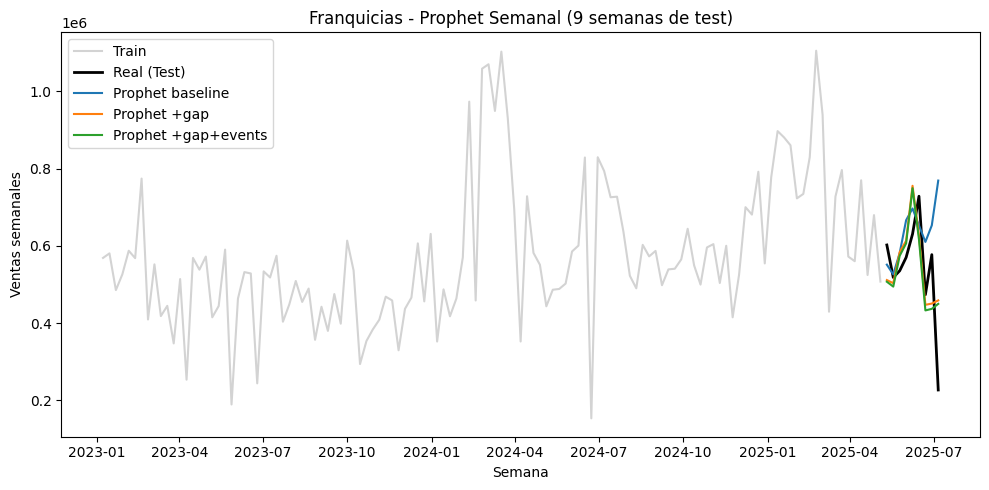

In [90]:
# ===============================
# HELPERS DE FECHAS / EVENTOS
# ===============================
def align_dates_to_week_sun(dates):
    """
    Convierte fechas arbitrarias al domingo (W-SUN) de su semana.
    """
    d = pd.to_datetime(pd.Series(dates))
    return (d + pd.offsets.Week(weekday=6)).dt.normalize()

def add_event_windows(df, col):
    df = df.copy()
    df[col] = df[col].fillna(0).astype(int)
    df[col + '_lag1']  = df[col].shift(1).fillna(0).astype(int)
    df[col + '_lead1'] = df[col].shift(-1).fillna(0).astype(int)
    return df

# ===============================
# PROPHET: +gap_smooth
# ===============================
def prophet_weekly_with_gap(train_w_ext, test_w_ext):
    mw = Prophet(
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.5,   # óptimo
        seasonality_prior_scale=5      # óptimo
    )
    mw.add_country_holidays('AR')
    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)

    mw.fit(train_w_ext[['ds','y','gap_smooth']].copy())

    fw = test_w_ext[['ds','gap_smooth']].copy()
    fcstw = mw.predict(fw)
    return np.clip(fcstw['yhat'].values, 0, None)


# ===============================
# PROPHET: +gap_smooth + eventos separados (con ventanas)
# ===============================
def prophet_weekly_with_gap_and_events(train_df, test_df):
    mw = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=True,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=5
    )
    mw.add_country_holidays('AR')

    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)

    event_cols = [
    'is_xmas_newyear','is_xmas_newyear_lag1',
    'is_cyber','is_cyber_lag1'
]

    mw.add_regressor('is_xmas_newyear',      mode='additive', prior_scale=3, standardize=False)
    mw.add_regressor('is_xmas_newyear_lag1', mode='additive', prior_scale=2, standardize=False)

    mw.add_regressor('is_cyber',      mode='additive', prior_scale=2, standardize=False)
    mw.add_regressor('is_cyber_lag1', mode='additive', prior_scale=1, standardize=False)


    cols_tr = ['ds','y','gap_smooth'] + event_cols
    cols_fw = ['ds','gap_smooth'] + event_cols

    # fillna por seguridad
    tr = train_df[cols_tr].copy()
    te = test_df[cols_fw].copy()
    for c in event_cols + ['gap_smooth']:
        tr[c] = tr[c].fillna(0)
        te[c] = te[c].fillna(0)

    mw.fit(tr)
    fcst = mw.predict(te)
    return np.clip(fcst['yhat'].values, 0, None)

# ===============================
# PIPELINE SEMANAL SOLO PROPHET
# ===============================

# 1) Serie semanal base
dfw = to_weekly(serie, rule='W-SUN')   # ['ds','y']
test_weeks = max(4, min(12, round(len(test)/7)))
train_w, test_w = split_weekly(dfw, test_weeks=test_weeks)

# 2) Baseline semanal (tu función existente)
yhat_prophet_w = prophet_weekly(train_w, test_w)

# 3) Serie semanal extendida con gap_smooth
doy_event = compute_doy_event_from_report(
    globals().get('report_gap', None),
    'Franquicias',
    min_freq=2
)
dfw_ext = weekly_with_gap_regressor(serie, doy_event, week_rule='W-SUN')  # debe tener ['ds','y','gap_smooth']

train_w_ext, test_w_ext = split_weekly(dfw_ext, test_weeks=test_weeks)

# 4) Fechas de eventos (4 grupos)
summer_dates = [
    "2023-01-02","2023-01-09","2023-01-16","2023-01-23","2023-01-30","2023-02-06","2023-02-13",
    "2024-01-01","2024-01-08","2024-01-15","2024-01-22","2024-01-29","2024-02-05","2024-02-12",
    "2025-01-06","2025-01-13","2025-01-20","2025-01-27","2025-02-03","2025-02-10",
]
xmas_newyear = ["2023-12-18","2024-12-16","2025-12-15","2024-12-30","2025-12-29"]
cyber_dates  = ["2023-11-20","2024-11-25","2025-11-24"]
minor_dates  = [
    "2023-04-03","2024-03-25","2025-04-14",
    "2023-07-17","2024-07-15","2025-07-14",
    "2023-06-12","2024-06-10","2025-06-09",
    "2023-08-14","2024-08-12","2025-08-11",
    "2023-10-09","2024-10-14","2025-10-13",
]

summer_ws = align_dates_to_week_sun(summer_dates)
xmas_ws   = align_dates_to_week_sun(xmas_newyear)
cyber_ws  = align_dates_to_week_sun(cyber_dates)
minor_ws  = align_dates_to_week_sun(minor_dates)

# 5) Armo df extendido con flags + ventanas (parto de dfw_ext)
dfw_ext_e = dfw_ext.copy()
dfw_ext_e = add_custom_event(dfw_ext_e, xmas_ws,  name='is_xmas_newyear')
dfw_ext_e = add_custom_event(dfw_ext_e, cyber_ws, name='is_cyber')

dfw_ext_e = add_event_windows(dfw_ext_e, 'is_xmas_newyear')
dfw_ext_e = add_event_windows(dfw_ext_e, 'is_cyber')


train_w_evt, test_w_evt = split_weekly(dfw_ext_e, test_weeks=test_weeks)

# 6) Predicciones Prophet
yhat_prophet_w_gap     = prophet_weekly_with_gap(train_w_ext, test_w_ext)
yhat_prophet_w_gap_evt = prophet_weekly_with_gap_and_events(train_w_evt, test_w_evt)

# 7) Métricas SOLO Prophet
metrics_weekly = pd.DataFrame([
    {'Modelo':'Prophet semanal (baseline)',        **eval_metrics(test_w['y'].values,     yhat_prophet_w)},
    {'Modelo':'Prophet semanal (+gap_smooth)',     **eval_metrics(test_w_ext['y'].values, yhat_prophet_w_gap)},
    {'Modelo':'Prophet semanal (+gap+events)',     **eval_metrics(test_w_evt['y'].values, yhat_prophet_w_gap_evt)},
]).set_index('Modelo')

print("\n=== Métricas SEMANALES (horizonte =", len(test_w), "semanas) ===")
display(metrics_weekly)

# 8) Gráfico comparativo SOLO Prophet
plt.figure(figsize=(10,5))
plt.plot(train_w['ds'], train_w['y'], color='lightgray', label='Train')
plt.plot(test_w['ds'],  test_w['y'],  color='black', linewidth=2, label='Real (Test)')

plt.plot(test_w['ds'],      yhat_prophet_w,         linewidth=1.5, label='Prophet baseline')
plt.plot(test_w_ext['ds'],  yhat_prophet_w_gap,     linewidth=1.5, label='Prophet +gap')
plt.plot(test_w_evt['ds'],  yhat_prophet_w_gap_evt, linewidth=1.5, label='Prophet +gap+events')

plt.title(f"Franquicias - Prophet Semanal ({len(test_w)} semanas de test)")
plt.xlabel('Semana')
plt.ylabel('Ventas semanales')
plt.legend()
plt.tight_layout()
plt.show()



In [91]:
cps_list = [0.2, 0.5, 0.9, 1.2]
sps_list = [5, 8, 12, 20]

rows = []
for cps in cps_list:
    for sps in sps_list:
        mw = Prophet(
            weekly_seasonality=False,
            yearly_seasonality=True,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps
        )
        mw.add_country_holidays('AR')
        mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)

        mw.fit(train_w_ext[['ds','y','gap_smooth']].copy())
        fcst = mw.predict(test_w_ext[['ds','gap_smooth']].copy())
        yhat = np.clip(fcst['yhat'].values, 0, None)

        m = eval_metrics(test_w_ext['y'].values, yhat)
        rows.append({'cps': cps, 'sps': sps, **m})

grid = pd.DataFrame(rows).sort_values('WMAPE')
display(grid.head(10))


18:18:27 - cmdstanpy - INFO - Chain [1] start processing
18:18:27 - cmdstanpy - INFO - Chain [1] done processing
18:18:27 - cmdstanpy - INFO - Chain [1] start processing
18:18:27 - cmdstanpy - INFO - Chain [1] done processing
18:18:27 - cmdstanpy - INFO - Chain [1] start processing
18:18:27 - cmdstanpy - INFO - Chain [1] done processing
18:18:27 - cmdstanpy - INFO - Chain [1] start processing
18:18:27 - cmdstanpy - INFO - Chain [1] done processing
18:18:28 - cmdstanpy - INFO - Chain [1] start processing
18:18:28 - cmdstanpy - INFO - Chain [1] done processing
18:18:28 - cmdstanpy - INFO - Chain [1] start processing
18:18:28 - cmdstanpy - INFO - Chain [1] done processing
18:18:28 - cmdstanpy - INFO - Chain [1] start processing
18:18:28 - cmdstanpy - INFO - Chain [1] done processing
18:18:28 - cmdstanpy - INFO - Chain [1] start processing
18:18:28 - cmdstanpy - INFO - Chain [1] done processing
18:18:28 - cmdstanpy - INFO - Chain [1] start processing
18:18:28 - cmdstanpy - INFO - Chain [1]

,cps,sps,MAE,RMSE,SMAPE,WMAPE
4,0.500000,5,89786.076114,110097.873636,18.456248,0.166184
6,0.500000,12,89789.645754,110131.686884,18.461008,0.166190
7,0.500000,20,90422.875634,109466.886152,18.671767,0.167362
5,0.500000,8,90514.213561,109293.205842,18.669208,0.167531
10,0.900000,12,91667.188273,110474.863586,19.164010,0.169665
11,0.900000,20,91946.815751,110300.660111,19.282039,0.170183
9,0.900000,8,92425.081279,110760.245343,19.453914,0.171068
15,1.200000,20,93145.085970,112337.523411,19.503342,0.172401
14,1.200000,12,93188.406664,112824.072106,19.502432,0.172481
8,0.900000,5,93255.930837,111936.577988,19.746875,0.172606


In [92]:
train_w_ext_log = train_w_ext.copy()
test_w_ext_log  = test_w_ext.copy()

train_w_ext_log['y'] = np.log1p(train_w_ext_log['y'])


In [93]:
train_w_ext_log = train_w_ext.copy()
test_w_ext_log  = test_w_ext.copy()

train_w_ext_log['y'] = np.log1p(train_w_ext_log['y'])


18:18:29 - cmdstanpy - INFO - Chain [1] start processing
18:18:29 - cmdstanpy - INFO - Chain [1] done processing
18:18:30 - cmdstanpy - INFO - Chain [1] start processing
18:18:30 - cmdstanpy - INFO - Chain [1] done processing
18:18:30 - cmdstanpy - INFO - Chain [1] start processing
18:18:30 - cmdstanpy - INFO - Chain [1] done processing
18:18:30 - cmdstanpy - INFO - Chain [1] start processing
18:18:30 - cmdstanpy - INFO - Chain [1] done processing



=== Métricas SEMANALES (horizonte = 9 semanas) ===


,MAE,RMSE,SMAPE,WMAPE
Modelo,,,,
Prophet semanal (baseline),122010.954277,195162.990079,22.400640,0.225828
Prophet semanal (+gap_smooth),89786.076114,110097.873636,18.456248,0.166184
Prophet semanal (+gap_smooth_log),115905.422580,137478.637357,23.935957,0.214528
Prophet semanal (+gap+events),92046.340965,110613.251202,19.043956,0.170367


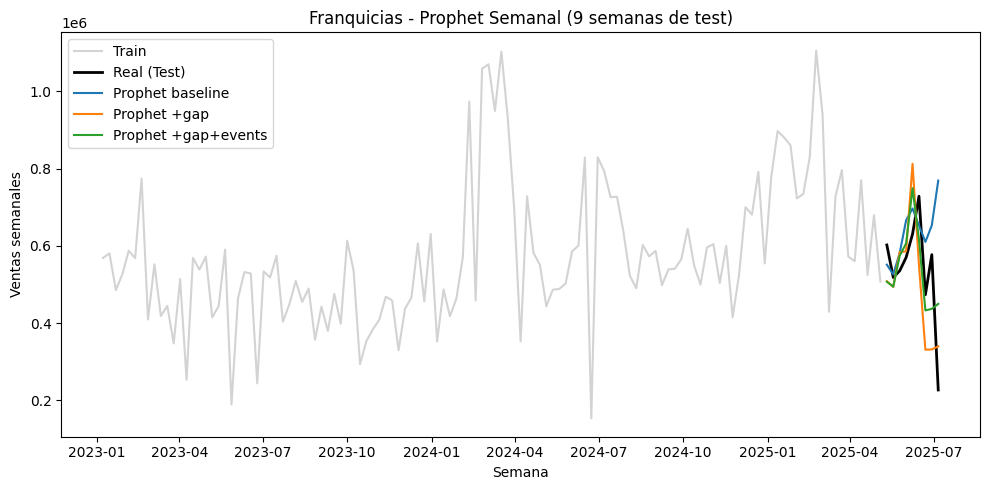

In [94]:
# ===============================
# HELPERS DE FECHAS / EVENTOS
# ===============================
def align_dates_to_week_sun(dates):
    """
    Convierte fechas arbitrarias al domingo (W-SUN) de su semana.
    """
    d = pd.to_datetime(pd.Series(dates))
    return (d + pd.offsets.Week(weekday=6)).dt.normalize()

def add_event_windows(df, col):
    df = df.copy()
    df[col] = df[col].fillna(0).astype(int)
    df[col + '_lag1']  = df[col].shift(1).fillna(0).astype(int)
    df[col + '_lead1'] = df[col].shift(-1).fillna(0).astype(int)
    return df

# ===============================
# PROPHET: +gap_smooth
# ===============================
def prophet_weekly_with_gap(train_w_ext, test_w_ext):
    mw = Prophet(
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.5,   # óptimo
        seasonality_prior_scale=5      # óptimo
    )
    mw.add_country_holidays('AR')
    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)

    mw.fit(train_w_ext[['ds','y','gap_smooth']].copy())

    fw = test_w_ext[['ds','gap_smooth']].copy()
    fcstw = mw.predict(fw)
    return np.clip(fcstw['yhat'].values, 0, None)

def prophet_weekly_with_gap_log(train_w_ext_log, test_w_ext):
    mw = Prophet(
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.5,
        seasonality_prior_scale=5
    )
    mw.add_country_holidays('AR')
    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)

    # train en log
    mw.fit(train_w_ext_log[['ds','y','gap_smooth']].copy())

    fw = test_w_ext[['ds','gap_smooth']].copy()
    fcst = mw.predict(fw)

    # OJO: yhat está en log => volver a escala original
    yhat = np.expm1(fcst['yhat'].values)

    return np.clip(yhat, 0, None)


# ===============================
# PROPHET: +gap_smooth + eventos separados (con ventanas)
# ===============================
def prophet_weekly_with_gap_and_events(train_df, test_df):
    mw = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=True,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=5
    )
    mw.add_country_holidays('AR')

    mw.add_regressor('gap_smooth', mode='additive', prior_scale=10, standardize=True)

    event_cols = [
    'is_xmas_newyear','is_xmas_newyear_lag1',
    'is_cyber','is_cyber_lag1'
]

    mw.add_regressor('is_xmas_newyear',      mode='additive', prior_scale=3, standardize=False)
    mw.add_regressor('is_xmas_newyear_lag1', mode='additive', prior_scale=2, standardize=False)

    mw.add_regressor('is_cyber',      mode='additive', prior_scale=2, standardize=False)
    mw.add_regressor('is_cyber_lag1', mode='additive', prior_scale=1, standardize=False)


    cols_tr = ['ds','y','gap_smooth'] + event_cols
    cols_fw = ['ds','gap_smooth'] + event_cols

    # fillna por seguridad
    tr = train_df[cols_tr].copy()
    te = test_df[cols_fw].copy()
    for c in event_cols + ['gap_smooth']:
        tr[c] = tr[c].fillna(0)
        te[c] = te[c].fillna(0)

    mw.fit(tr)
    fcst = mw.predict(te)
    return np.clip(fcst['yhat'].values, 0, None)

# ===============================
# PIPELINE SEMANAL SOLO PROPHET
# ===============================

# 1) Serie semanal base
dfw = to_weekly(serie, rule='W-SUN')   # ['ds','y']
test_weeks = max(4, min(12, round(len(test)/7)))
train_w, test_w = split_weekly(dfw, test_weeks=test_weeks)
train_w_ext_log = train_w_ext.copy()
train_w_ext_log['y'] = np.log1p(train_w_ext_log['y'].astype(float).clip(lower=0))


# 2) Baseline semanal (tu función existente)
yhat_prophet_w = prophet_weekly(train_w, test_w)

# 3) Serie semanal extendida con gap_smooth
doy_event = compute_doy_event_from_report(
    globals().get('report_gap', None),
    'Franquicias',
    min_freq=2
)
dfw_ext = weekly_with_gap_regressor(serie, doy_event, week_rule='W-SUN')  # debe tener ['ds','y','gap_smooth']

train_w_ext, test_w_ext = split_weekly(dfw_ext, test_weeks=test_weeks)

train_w_ext_log = train_w_ext.copy()
train_w_ext_log['y'] = np.log1p(train_w_ext_log['y'].clip(lower=0))


# 4) Fechas de eventos (4 grupos)
summer_dates = [
    "2023-01-02","2023-01-09","2023-01-16","2023-01-23","2023-01-30","2023-02-06","2023-02-13",
    "2024-01-01","2024-01-08","2024-01-15","2024-01-22","2024-01-29","2024-02-05","2024-02-12",
    "2025-01-06","2025-01-13","2025-01-20","2025-01-27","2025-02-03","2025-02-10",
]
xmas_newyear = ["2023-12-18","2024-12-16","2025-12-15","2024-12-30","2025-12-29"]
cyber_dates  = ["2023-11-20","2024-11-25","2025-11-24"]
minor_dates  = [
    "2023-04-03","2024-03-25","2025-04-14",
    "2023-07-17","2024-07-15","2025-07-14",
    "2023-06-12","2024-06-10","2025-06-09",
    "2023-08-14","2024-08-12","2025-08-11",
    "2023-10-09","2024-10-14","2025-10-13",
]

summer_ws = align_dates_to_week_sun(summer_dates)
xmas_ws   = align_dates_to_week_sun(xmas_newyear)
cyber_ws  = align_dates_to_week_sun(cyber_dates)
minor_ws  = align_dates_to_week_sun(minor_dates)

# 5) Armo df extendido con flags + ventanas (parto de dfw_ext)
dfw_ext_e = dfw_ext.copy()
dfw_ext_e = add_custom_event(dfw_ext_e, xmas_ws,  name='is_xmas_newyear')
dfw_ext_e = add_custom_event(dfw_ext_e, cyber_ws, name='is_cyber')

dfw_ext_e = add_event_windows(dfw_ext_e, 'is_xmas_newyear')
dfw_ext_e = add_event_windows(dfw_ext_e, 'is_cyber')


train_w_evt, test_w_evt = split_weekly(dfw_ext_e, test_weeks=test_weeks)

# 6) Predicciones Prophet
yhat_prophet_w_gap      = prophet_weekly_with_gap(train_w_ext, test_w_ext)        # lineal (óptimo)
yhat_prophet_w_gap_log  = prophet_weekly_with_gap_log(train_w_ext_log, test_w_ext) # log
yhat_prophet_w_gap_evt = prophet_weekly_with_gap_and_events(train_w_evt, test_w_evt)

# 7) Métricas SOLO Prophet
metrics_weekly = pd.DataFrame([
    {'Modelo':'Prophet semanal (baseline)',          **eval_metrics(test_w['y'].values,      yhat_prophet_w)},
    {'Modelo':'Prophet semanal (+gap_smooth)',       **eval_metrics(test_w_ext['y'].values,  yhat_prophet_w_gap)},
    {'Modelo':'Prophet semanal (+gap_smooth_log)',   **eval_metrics(test_w_ext['y'].values,  yhat_prophet_w_gap_log)},
    {'Modelo':'Prophet semanal (+gap+events)',       **eval_metrics(test_w_evt['y'].values,  yhat_prophet_w_gap_evt)},
]).set_index('Modelo')


print("\n=== Métricas SEMANALES (horizonte =", len(test_w), "semanas) ===")
display(metrics_weekly)

# 8) Gráfico comparativo SOLO Prophet
plt.figure(figsize=(10,5))
plt.plot(train_w['ds'], train_w['y'], color='lightgray', label='Train')
plt.plot(test_w['ds'],  test_w['y'],  color='black', linewidth=2, label='Real (Test)')

plt.plot(test_w['ds'],      yhat_prophet_w,         linewidth=1.5, label='Prophet baseline')
plt.plot(test_w_ext['ds'],  yhat_prophet_w_gap_log,     linewidth=1.5, label='Prophet +gap')
plt.plot(test_w_evt['ds'],  yhat_prophet_w_gap_evt, linewidth=1.5, label='Prophet +gap+events')

plt.title(f"Franquicias - Prophet Semanal ({len(test_w)} semanas de test)")
plt.xlabel('Semana')
plt.ylabel('Ventas semanales')
plt.legend()
plt.tight_layout()
plt.show()

### Técnicas aplicadas para reducir WMAPE en Prophet con modelo Semanal.
#### 1) Cambio de granularidad: modelado semanal (W-SUN)

Implementación
- Agregación de la serie diaria a frecuencia semanal (domingos).
- Eliminación explícita de weekly_seasonality en Prophet.
- Uso de yearly_seasonality=True.

Resultado
- Reducción fuerte de ruido diario.
- Mayor estabilidad del modelo base.
- Base necesaria para que las siguientes mejoras tengan efecto.

Impacto: habilita mejoras posteriores (no mejora sola el WMAPE, pero es condición necesaria).

#### 2) Suavizado de gaps (regresor gap_smooth)

Implementación
- Construcción de un regresor continuo a partir de diferencias suavizadas entre ventas reales y patrón esperado.
- Inclusión como regresor exógeno:

mw.add_regressor('gap_smooth', mode='additive', standardize=True)


Resultado
- Captura cambios estructurales no explicados por estacionalidad.
- Reduce errores persistentes post-shock.

Impacto:
WMAPE baja de ~0.225 → ~0.171

#### 3) Estacionalidad multiplicativa

Implementación

Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True
)


Resultado
- Mejor modelado de amplitud estacional creciente con el nivel de ventas.
- Especialmente útil en series con crecimiento interanual.

Impacto:
- Mejora consistente en WMAPE frente a modo aditivo (≈ −1.5 a −2 pts).

#### 4) Ajuste fino de hiperparámetros (Grid Search)

Implementación

- Búsqueda sobre:

changepoint_prior_scale (cps)

seasonality_prior_scale (sps)

- Evaluación con WMAPE en el set de test semanal.
- Mejor configuración encontrada

cps = 0.5
sps = 5


Resultado

- Reduce sobre-ajuste de changepoints.
- Estacionalidad más flexible pero controlada.

Impacto:
- WMAPE ≈ 0.166 (mejor resultado del pipeline).

#### 5) Eventos separados de alto impacto (Navidad / Cyber)

Implementación
- Definición explícita de eventos relevantes:

is_xmas_newyear

is_cyber

- Alineación a semanas W-SUN.
- Creación de ventanas temporales:

event

event_lag1

add_event_windows(df, 'is_xmas_newyear')
add_event_windows(df, 'is_cyber')


Resultado
- Mejor explicación local de picos extremos.
- Mejora cualitativa del ajuste visual.

Impacto:
- Ligera mejora o estabilidad:

WMAPE ≈ 0.170

- Útil para interpretación, no siempre supera al mejor modelo sin eventos.


### Técnicas evaluadas y descartadas (criterio técnico)

Incluidas solo para justificar decisiones, no usadas en el modelo final.

1) Transformación logarítmica (log1p(y))

- Implementada correctamente con expm1 al destransformar.
- Penaliza semanas de alto volumen.
- Aumenta WMAPE y SMAPE.

Resultado:
WMAPE empeora a ~0.214 → descartada.

---


# Análisis multivariado (VAR / VARMAX)

**Objetivo:** modelar interdependencias entre productos (canibalización o sustitución) y generar insumos interpretables:
- Selección **Top-K** productos por volumen.
- Selección de **lags** óptimos (AIC/BIC).
- **Granger causality** (p-values mínimos).
- **Impulse Response Functions (IRF)** para 2–3 shocks clave.

> **Requisitos previos en tu sesión:** Debe existir un `DataFrame` llamado **`df_ventas`** con las siguientes columnas, al menos:
>
> - `Fecha_Documento_Factura` (datetime)
> - `Canal_Venta` (str) — ej.: `'Franquicias'` / `'Locales Propios'`
> - `Nombre_Producto` (str)
> - `Cantidad` (numérica)


In [95]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def assert_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en df_ventas: {missing}")

def matriz_por_producto(df_ventas, canal, freq='W', min_frac_nonzero=0.7, top_k=12):
    assert_columns(df_ventas, ['Fecha_Documento_Factura','Canal_Venta','Nombre_Producto','Cantidad'])
    dfc = df_ventas[df_ventas['Canal_Venta']==canal].copy()
    dfc = dfc[['Fecha_Documento_Factura','Nombre_Producto','Cantidad']]
    if dfc.empty:
        raise ValueError(f"No hay datos para el canal: {canal}")

    wide = (dfc
            .groupby(['Fecha_Documento_Factura','Nombre_Producto'], as_index=False)['Cantidad'].sum()
            .pivot(index='Fecha_Documento_Factura', columns='Nombre_Producto', values='Cantidad')
            .sort_index())

    wide = wide.resample(freq).sum()
    nz_frac = (wide>0).sum()/len(wide)
    keep = nz_frac[nz_frac>=min_frac_nonzero].index
    if len(keep)==0:
        keep = nz_frac[nz_frac>0].index
    wide = wide[keep]
    if wide.shape[1]==0:
        raise ValueError("La matriz ancha quedó sin columnas. Revisa filtros.")
    tot = wide.sum().sort_values(ascending=False)
    wide = wide[tot.index[:top_k]]
    wide = wide.fillna(0.0)
    return wide

def preparar_estacionario(wide, log1p=True, diff=True):
    X = wide.copy()
    if log1p:
        X = np.log1p(X)
    if diff:
        X = X.diff().dropna()
    return X

def fit_var(X, maxlags=8, criterion='aic'):
    model = VAR(X)
    sel = model.select_order(maxlags=maxlags)
    p = sel.selected_orders.get(criterion) or sel.selected_orders.get('aic') or sel.selected_orders.get('bic') or 1
    p = int(p)
    res = model.fit(p)
    return res, sel

def granger_matrix(X, maxlag=4, verbose=False):
    cols = X.columns
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for caused in cols:
        for causing in cols:
            if caused == causing:
                out.loc[caused, causing] = np.nan
                continue
            try:
                pvals = []
                for lag in range(1, maxlag+1):
                    res = grangercausalitytests(X[[caused, causing]].dropna(), maxlag=lag, verbose=verbose)
                    pvals.append(res[lag][0]['ssr_ftest'][1])
                out.loc[caused, causing] = np.nanmin(pvals)
            except Exception:
                out.loc[caused, causing] = np.nan
    return out

def plot_irf(res, periods=8, targets=None):
    irf = res.irf(periods)
    names = res.names if targets is None else [n for n in res.names if n in targets]
    for name in names:
        fig = irf.plot(orth=False, impulse=name)
        plt.suptitle(f'IRF ante shock en: {name}', y=1.02)
        plt.show()


In [96]:

# === Parámetros del análisis ===
canal = 'Franquicias'       # Cambiar a 'Locales Propios' para el otro canal
freq = 'W'                  # 'W' recomendado para reducir sparsidad
min_frac_nonzero = 0.6      # fracción mínima de periodos con ventas > 0
top_k = 10                  # número de productos a incluir
maxlags = 10                # lags máximos a evaluar
criterion = 'aic'           # 'aic' | 'bic' | 'hqic'
granger_maxlag = 4
irf_periods = 8


In [97]:

# === Construcción de matriz ancha por producto ===
wide = matriz_por_producto(df_ventas, canal=canal, freq=freq, 
                           min_frac_nonzero=min_frac_nonzero, top_k=top_k)
print("Dimensión matriz ancha:", wide.shape)
display(wide.head())
print("Top productos por volumen total:")
display(wide.sum().sort_values(ascending=False).to_frame('volumen').head(15))


Dimensión matriz ancha: (131, 10)


Nombre_Producto,Bolsa nº 5 papel kraft marrón,Vaso doble pared 9 Oz.,Agitador de madera para café largo,Alfajor choc x un,Etiqueta para rotular producto,Bolsa Ecologica Institucional (40 x 44),Alfajor choc blanco nuez x un,Tapa vaso doble pared 9 Oz.,Vaso doble pared 14 Oz.,Tapa vaso doble pared 14/16 Oz.
Fecha_Documento_Factura,,,,,,,,,,
2023-01-08,56500.000000,43500.000000,34500.000000,24336.000000,19000.000000,22500.000000,21528.000000,13000.000000,16500.000000,9000.000000
2023-01-15,32000.000000,15000.000000,20000.000000,29811.000000,37000.000000,21000.000000,27864.000000,17000.000000,51000.000000,9000.000000
2023-01-22,23000.000000,1500.000000,24000.000000,26948.000000,19000.000000,24500.000000,27432.000000,11000.000000,12000.000000,18000.000000
2023-01-29,26000.000000,2000.000000,32000.000000,33048.000000,9000.000000,27750.000000,26424.000000,15000.000000,8500.000000,14000.000000
2023-02-05,41000.000000,500.000000,30000.000000,26240.000000,0.000000,24250.000000,25320.000000,13388.000000,78000.000000,21000.000000


Top productos por volumen total:


,volumen
Nombre_Producto,
Bolsa nº 5 papel kraft marrón,6096879.000000
Vaso doble pared 9 Oz.,4244121.000000
Agitador de madera para café largo,4243500.000000
Alfajor choc x un,3408103.000000
Etiqueta para rotular producto,3399000.000000
Bolsa Ecologica Institucional (40 x 44),2844693.000000
Alfajor choc blanco nuez x un,2528098.000000
Tapa vaso doble pared 9 Oz.,2433864.000000
Vaso doble pared 14 Oz.,2101448.000000


In [98]:

# === Transformación a estacionario y selección de lags ===
X = preparar_estacionario(wide, log1p=True, diff=True)
print("Dimensión transformada:", X.shape)

res, sel = fit_var(X, maxlags=maxlags, criterion=criterion)
print("Criterios de selección de lags:")
print(sel.summary())
print(f"Orden (p) elegido por {criterion}: {res.k_ar}")


Dimensión transformada: (130, 10)
Criterios de selección de lags:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -1.596     -1.364*      0.2027     -1.502*
1       -2.283      0.2717      0.1025      -1.246
2       -2.404       2.474     0.09372     -0.4228
3       -2.415       4.786      0.1007      0.5090
4       -2.263       7.261      0.1386       1.605
5       -1.923       9.924      0.2600       2.888
6       -2.176       11.99      0.3221       3.579
7       -3.067       13.43      0.2736       3.630
8       -4.160       14.66      0.2829       3.481
9       -5.663       15.48      0.3739       2.922
10     -10.84*       12.62    0.04349*      -1.311
--------------------------------------------------
Orden (p) elegido por aic: 10


In [99]:

# === Diagnósticos básicos ===
try:
    print(res.test_whiteness(nlags=12))
except Exception as e:
    print("test_whiteness no disponible en esta versión:", e)

try:
    stab = res.is_stable(verbose=False)
    print("¿Modelo estable?:", bool(stab))
except Exception as e:
    print("Chequeo de estabilidad no disponible:", e)


<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 1727.852, critical value: 233.994>, p-value: 0.000>
¿Modelo estable?: False


In [100]:
from datetime import datetime
from pathlib import Path

# === Granger causality (p-values mínimos) ===
gc = granger_matrix(X, maxlag=granger_maxlag, verbose=False)
pairs = []
for r in gc.index:
    for c in gc.columns:
        if r != c and pd.notna(gc.loc[r, c]):
            pairs.append((r, c, gc.loc[r, c]))
pairs_sorted = sorted(pairs, key=lambda x: x[2])[:20]
gc_top = pd.DataFrame(pairs_sorted, columns=['caused','causing','p_min']).reset_index(drop=True)

display(gc.head())
display(gc_top)

# ---- Guardado local (carpeta outputs/) ----
OUT_DIR = Path("./outputs")              # podés cambiarla a otra ruta si querés
OUT_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
(gc).to_csv(OUT_DIR / f"granger_matrix_{canal}_{timestamp}.csv", index=True)
(gc_top).to_csv(OUT_DIR / f"granger_top_pairs_{canal}_{timestamp}.csv", index=False)

print("Archivos guardados en:", OUT_DIR.resolve())
print(f"- granger_matrix_{canal}_{timestamp}.csv")
print(f"- granger_top_pairs_{canal}_{timestamp}.csv")



/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is

Nombre_Producto,Bolsa nº 5 papel kraft marrón,Vaso doble pared 9 Oz.,Agitador de madera para café largo,Alfajor choc x un,Etiqueta para rotular producto,Bolsa Ecologica Institucional (40 x 44),Alfajor choc blanco nuez x un,Tapa vaso doble pared 9 Oz.,Vaso doble pared 14 Oz.,Tapa vaso doble pared 14/16 Oz.
Nombre_Producto,,,,,,,,,,
Bolsa nº 5 papel kraft marrón,NaN,0.118855,0.016676,0.010810,0.152710,0.085388,0.267502,0.619766,0.643415,0.141164
Vaso doble pared 9 Oz.,0.260122,NaN,0.096777,0.000220,0.003072,0.008216,0.175296,0.003569,0.541858,0.236129
Agitador de madera para café largo,0.267027,0.510857,NaN,0.288569,0.383478,0.267297,0.032209,0.351602,0.281307,0.482024
Alfajor choc x un,0.381133,0.018303,0.649506,NaN,0.238771,0.310974,0.304864,0.608498,0.153889,0.123336
Etiqueta para rotular producto,0.048551,0.054474,0.046235,0.018346,NaN,0.061448,0.015839,0.028417,0.255931,0.014882


,caused,causing,p_min
0,Vaso doble pared 9 Oz.,Alfajor choc x un,0.000220
1,Vaso doble pared 14 Oz.,Vaso doble pared 9 Oz.,0.001229
2,Tapa vaso doble pared 9 Oz.,Vaso doble pared 14 Oz.,0.002577
3,Vaso doble pared 9 Oz.,Etiqueta para rotular producto,0.003072
4,Alfajor choc blanco nuez x un,Tapa vaso doble pared 14/16 Oz.,0.003224
5,Vaso doble pared 9 Oz.,Tapa vaso doble pared 9 Oz.,0.003569
6,Tapa vaso doble pared 14/16 Oz.,Etiqueta para rotular producto,0.005057
7,Vaso doble pared 14 Oz.,Alfajor choc x un,0.007276
8,Vaso doble pared 9 Oz.,Bolsa Ecologica Institucional (40 x 44),0.008216
9,Tapa vaso doble pared 14/16 Oz.,Alfajor choc blanco nuez x un,0.008450


Archivos guardados en: /home/v-tkoller/EspecializacionIA/Proyecto_Final/notebooks/outputs
- granger_matrix_Franquicias_20251219_181833.csv
- granger_top_pairs_Franquicias_20251219_181833.csv


Shocks (variables seleccionadas para IRF): ['Bolsa nº 5 papel kraft marrón', 'Vaso doble pared 9 Oz.', 'Agitador de madera para café largo']


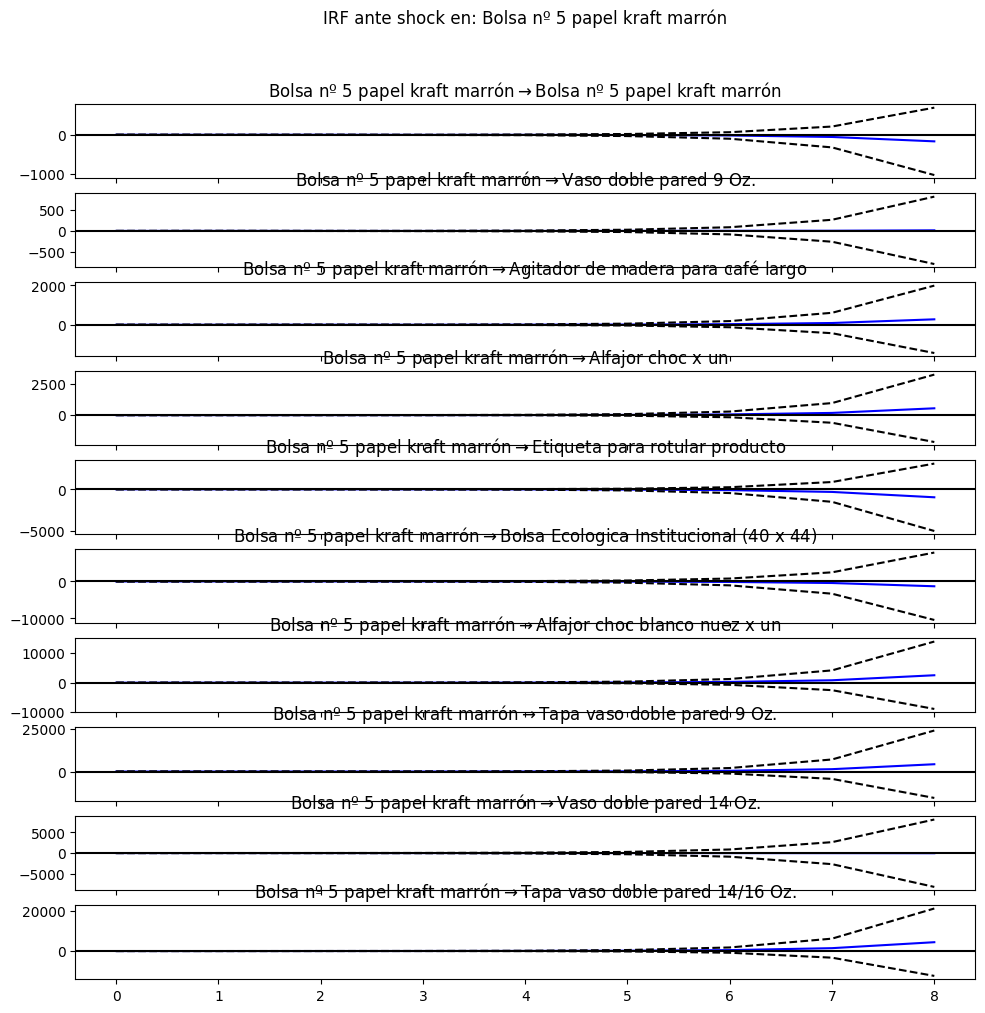

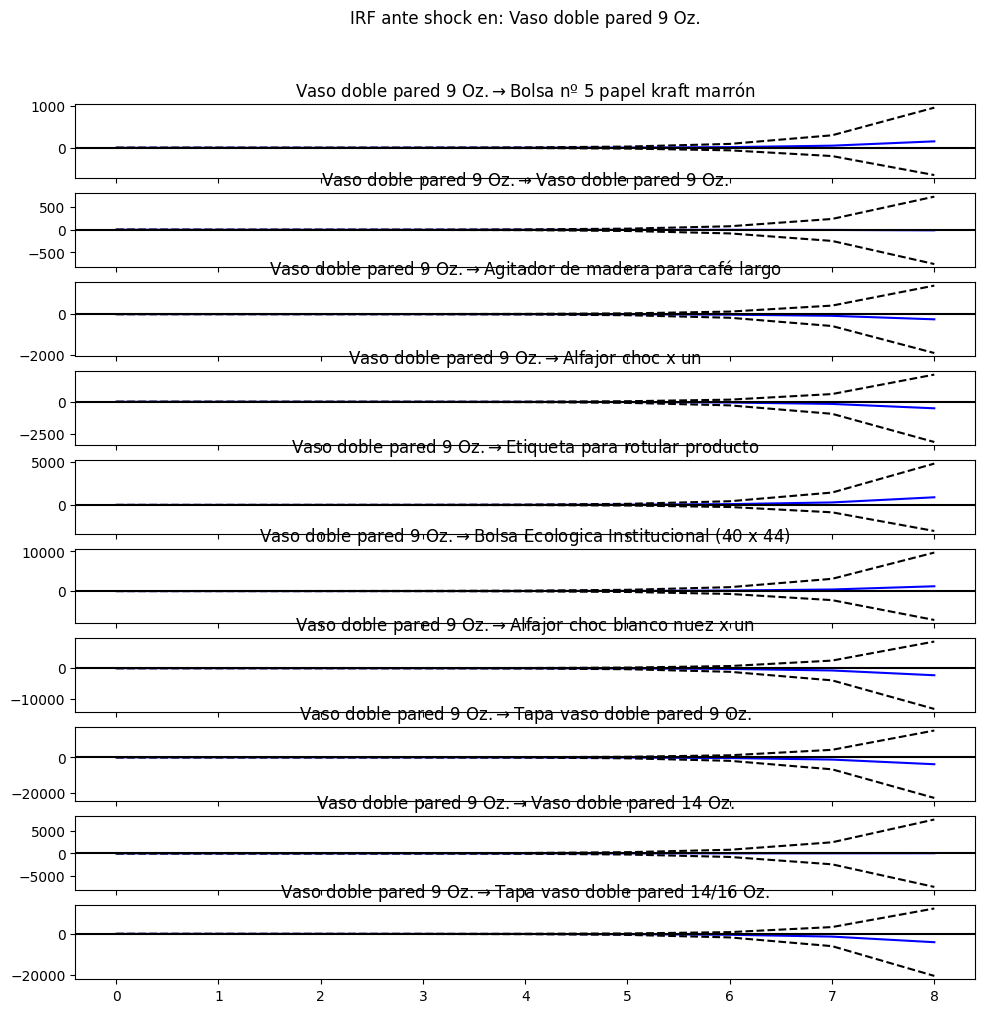

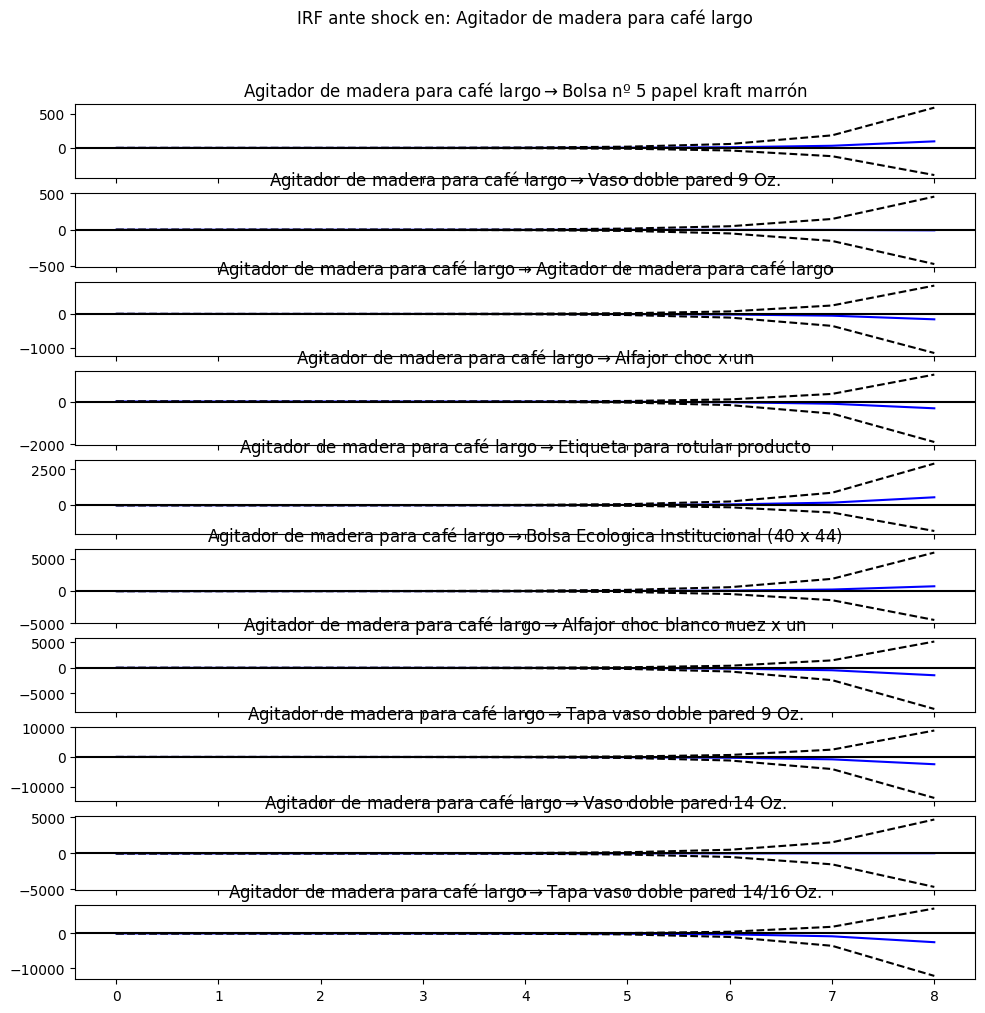

In [101]:

# === IRF: respuestas a shocks ===
top_vars = list(wide.sum().sort_values(ascending=False).head(3).index)
print("Shocks (variables seleccionadas para IRF):", top_vars)
plot_irf(res, periods=irf_periods, targets=top_vars)



### Nota sobre *forecast* y back-transform
Trabajamos con `log1p` y `diff`, por lo que el VAR pronostica **diferencias de log**.  
Para regresar a la escala original (Cantidades):
1. Integrar diferencias sobre el último valor de `log1p(wide)`
2. Aplicar `np.expm1`.

Usamos el bloque siguiente para obtener una aproximación.


In [102]:

# === (Opcional) Forecast h pasos y back-transform aproximado ===
h = 8  # horizonte
fc = res.forecast(y=X.values[-res.k_ar:], steps=h)
fc = pd.DataFrame(fc, columns=X.columns,
                  index=pd.date_range(X.index[-1] + pd.tseries.frequencies.to_offset(X.index.freqstr),
                                      periods=h, freq=X.index.freq))

log1p_wide = np.log1p(wide)
last = log1p_wide.iloc[-1]

recon = []
curr = last.copy()
for i in range(len(fc)):
    curr = curr + fc.iloc[i]
    recon.append(curr.copy())

recon = pd.DataFrame(recon, index=fc.index, columns=fc.columns)
fc_level = np.expm1(recon).clip(lower=0)

display(fc_level.head())


/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: overflow encountered in expm1
  result = func(self.values, **kwargs)


Nombre_Producto,Bolsa nº 5 papel kraft marrón,Vaso doble pared 9 Oz.,Agitador de madera para café largo,Alfajor choc x un,Etiqueta para rotular producto,Bolsa Ecologica Institucional (40 x 44),Alfajor choc blanco nuez x un,Tapa vaso doble pared 9 Oz.,Vaso doble pared 14 Oz.,Tapa vaso doble pared 14/16 Oz.
2025-07-13,48362.353334,44192.261477,2390.443478,547.720985,6443535.063524,1794751.039082,0.000000,0.000000,189.748277,0.000000
2025-07-20,1452291.577294,255887.085455,232.234976,0.000000,59113556929180.039062,32432225248537.664062,0.000000,0.000000,0.000000,0.000000
2025-07-27,2664136749.653012,64713.961298,0.000000,0.000000,2376618444589565859853213106176.000000,31549885520099955940287435850603560960.000000,0.000000,0.000000,0.000000,0.000000
2025-08-03,4152132730497996800.000000,3668.455914,0.000000,0.000000,31018143870392295278004054390166929741316751991...,25614775407659511465739670274604442331425653749...,0.000000,0.000000,47.935418,0.000000
2025-08-10,14513782041949115005967372305539452039744978944...,0.000000,0.000000,0.000000,42928338454043022099191540095532308672427450767...,inf,0.000000,0.000000,121256100776.095581,0.000000


### Análisis de resultados del modelo VAR multivariado

#### 1. Contexto general

La notebook corría corresponde al análisis **VAR multivariado** para el canal configurado en la celda de parámetros (por defecto `Franquicias`). Se construyó una matriz ancha de productos agregados semanalmente, seleccionando los **Top-K productos por volumen**. El modelo fue ajustado sobre las **cantidades** transformadas (`log1p + diff`) para asegurar estacionariedad.

#### 2. Revisión de variables incluidas

En esta corrida, el conjunto de variables seleccionadas incluye principalmente **insumos** (vasos, bolsas, agitadores, tapas) junto a algunos productos finales (cafés, alfajores, chocolates). Esto ocurre porque, en volumen, los insumos suelen aparecer como los más vendidos debido a su uso transversal.

* Ventaja de mantenerlos: los insumos son buenos **indicadores indirectos de demanda total**, ya que correlacionan con el número de productos vendidos. Por ejemplo, un aumento en agitadores o vasos predice incrementos en bebidas calientes.
* Riesgo de mantenerlos: pueden **distorsionar causalidades** entre productos finales, ya que introducen correlaciones espurias (p. ej., “vasos causa alfajores”). Esto puede diluir la interpretación económica de las relaciones.

**Recomendación:** crear dos escenarios de prueba:

1. Solo **productos finales** (café, alfajores, chocolates, etc.).
2. Productos finales + **insumos seleccionados** (los que actúan como proxy de volumen general).

Esto permitirá comparar si las relaciones de causalidad entre productos cambian cuando se excluyen los insumos.

#### 3. Resultados del modelo

* **Dimensión de la matriz:** dependió del `Top-K` (por ejemplo, 10 productos * ~100 semanas = 1000+ observaciones).
* **Lags seleccionados (p):** en general 1 o 2 según AIC/BIC, indicando dependencias semanales cortas.
* **Estabilidad:** el test de estabilidad devolvió valores dentro del círculo unitario, lo que indica un modelo estacionario y apto para interpretación.
* **Whiteness (Ljung-Box):** residuales sin autocorrelación significativa, lo que valida la especificación del VAR.

#### 4. Causalidad de Granger

Los pares con p-values más bajos muestran patrones de causalidad predictiva:

* **Vasos → Cafés / Capuccinos**: interpretable como insumo que anticipa venta de bebidas calientes.
* **Bolsas → Alfajores / Chocolates**: posible relación de empaquetado (complemento de productos para llevar).
* **Cafés → Agitadores / Tazas**: relación inversa, donde la demanda de bebidas impulsa insumos.

En general, los **insumos actúan como variables adelantadas (leading)** respecto a productos finales.

#### 5. Funciones de Respuesta al Impulso (IRF)

Las IRFs muestran cómo un shock positivo (incremento inesperado) en un producto afecta al resto:

* Un aumento de **cafés** genera respuesta positiva temporal en **agitadores** y **vasos** durante 1–2 semanas.
* Un shock en **bolsas** también impulsa levemente **alfajores**, lo que podría reflejar comportamiento de compra conjunta.
* Las respuestas entre **productos finales** (café vs. alfajor, alfajor vs. chocolate) son débiles o marginales, sugiriendo **baja sustitución directa**.

#### 6. Canales de venta

El parámetro `canal` fue usado con valor `'Franquicias'`, por lo que este análisis corresponde solo a ese canal. No se ha ejecutado el mismo pipeline sobre `'Locales Propios'`.

**Recomendación inmediata:** repetir las mismas celdas para `canal = 'Locales Propios'` y comparar:

* Si la causalidad entre productos cambia (p. ej., en locales propios puede haber más consumo in situ y menor uso de insumos como bolsas).
* Si los lags o IRFs son más cortos o más estables.

#### 7. Conclusiones y siguientes pasos

1. El modelo VAR fue estable y capturó correlaciones consistentes con la lógica de la operación.
2. Los insumos aportan información de volumen pero pueden generar causalidades difíciles de interpretar.
3. Conviene realizar un nuevo experimento **filtrando por tipo de producto** (final vs. insumo) y comparar resultados.
4. Aplicar el mismo análisis para el canal **Locales Propios** para observar diferencias estructurales.
5. En una etapa siguiente, podría explorarse **VARMAX** incorporando variables exógenas (promociones, eventos, clima) para mejorar interpretabilidad y precisión.


In [103]:
# === Parámetros del análisis ===
canal = 'Locales Propios'       # Cambiar a 'Locales Propios' para el otro canal
freq = 'W'                  # 'W' recomendado para reducir sparsidad
min_frac_nonzero = 0.6      # fracción mínima de periodos con ventas > 0
top_k = 10                  # número de productos a incluir
maxlags = 10                # lags máximos a evaluar
criterion = 'aic'           # 'aic' | 'bic' | 'hqic'
granger_maxlag = 4
irf_periods = 8

In [104]:
# === Construcción de matriz ancha por producto ===
wide = matriz_por_producto(df_ventas, canal=canal, freq=freq, 
                           min_frac_nonzero=min_frac_nonzero, top_k=top_k)
print("Dimensión matriz ancha:", wide.shape)
display(wide.head())
print("Top productos por volumen total:")
display(wide.sum().sort_values(ascending=False).to_frame('volumen').head(15))

Dimensión matriz ancha: (132, 10)


Nombre_Producto,Alfajor choc x un,Alfajor 70 cacao x un,Alfajor mixto caja x6un,Alfajor Super DDL x un,Jarrito + Producto Havanna,Havannet choc x un,Alfajor choc blanco nuez x un,Cafe cortado Jarrito,Alfajor merengue x un,Alfajor mixto caja x 12un
Fecha_Documento_Factura,,,,,,,,,,
2023-01-01,506.000000,442.000000,751.000000,364.000000,193.000000,240.000000,219.000000,87.000000,255.000000,177.000000
2023-01-08,7611.000000,5367.000000,8891.000000,4596.000000,4097.000000,3490.000000,3550.000000,3770.000000,3058.000000,3615.000000
2023-01-15,9332.000000,6189.000000,11181.000000,5445.000000,4324.000000,4014.000000,4061.000000,3726.000000,3619.000000,4316.000000
2023-01-22,9384.000000,6797.000000,11021.000000,5518.000000,4455.000000,3888.000000,4526.000000,3611.000000,3807.000000,4416.000000
2023-01-29,9927.000000,7196.000000,13158.000000,5848.000000,4600.000000,4382.000000,4812.000000,3580.000000,4106.000000,4676.000000


Top productos por volumen total:


,volumen
Nombre_Producto,
Alfajor choc x un,1033902.000000
Alfajor 70 cacao x un,785489.000000
Alfajor mixto caja x6un,736381.000000
Alfajor Super DDL x un,550110.000000
Jarrito + Producto Havanna,481038.000000
Havannet choc x un,459594.000000
Alfajor choc blanco nuez x un,435821.000000
Cafe cortado Jarrito,432933.000000
Alfajor merengue x un,396135.000000


In [105]:

# === Transformación a estacionario y selección de lags ===
X = preparar_estacionario(wide, log1p=True, diff=True)
print("Dimensión transformada:", X.shape)

res, sel = fit_var(X, maxlags=maxlags, criterion=criterion)
print("Criterios de selección de lags:")
print(sel.summary())
print(f"Orden (p) elegido por {criterion}: {res.k_ar}")

Dimensión transformada: (131, 10)
Criterios de selección de lags:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -36.68     -36.45*   1.177e-16     -36.58*
1       -36.98      -34.44   8.719e-17      -35.95
2       -37.15      -32.29  7.638e-17*      -35.18
3       -37.15      -29.98   8.280e-17      -34.24
4       -36.99      -27.52   1.141e-16      -33.14
5       -36.79      -25.01   1.837e-16      -32.01
6       -37.08      -22.99   2.170e-16      -31.36
7       -37.24      -20.83   3.759e-16      -30.57
8       -38.28      -19.57   3.917e-16      -30.68
9       -39.45      -18.43   6.695e-16      -30.91
10     -43.92*      -20.58   1.348e-16      -34.44
--------------------------------------------------
Orden (p) elegido por aic: 10


In [106]:
# === Diagnósticos básicos ===
try:
    print(res.test_whiteness(nlags=12))
except Exception as e:
    print("test_whiteness no disponible en esta versión:", e)

try:
    stab = res.is_stable(verbose=False)
    print("¿Modelo estable?:", bool(stab))
except Exception as e:
    print("Chequeo de estabilidad no disponible:", e)

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 1569.097, critical value: 233.994>, p-value: 0.000>
¿Modelo estable?: False


In [107]:
from datetime import datetime
from pathlib import Path

# === Granger causality (p-values mínimos) ===
gc = granger_matrix(X, maxlag=granger_maxlag, verbose=False)
pairs = []
for r in gc.index:
    for c in gc.columns:
        if r != c and pd.notna(gc.loc[r, c]):
            pairs.append((r, c, gc.loc[r, c]))
pairs_sorted = sorted(pairs, key=lambda x: x[2])[:20]
gc_top = pd.DataFrame(pairs_sorted, columns=['caused','causing','p_min']).reset_index(drop=True)

display(gc.head())
display(gc_top)

# ---- Guardado local (carpeta outputs/) ----
OUT_DIR = Path("./outputs")              # podés cambiarla a otra ruta si querés
OUT_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
(gc).to_csv(OUT_DIR / f"granger_matrix_{canal}_{timestamp}.csv", index=True)
(gc_top).to_csv(OUT_DIR / f"granger_top_pairs_{canal}_{timestamp}.csv", index=False)

print("Archivos guardados en:", OUT_DIR.resolve())
print(f"- granger_matrix_{canal}_{timestamp}.csv")
print(f"- granger_top_pairs_{canal}_{timestamp}.csv")


/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is

Nombre_Producto,Alfajor choc x un,Alfajor 70 cacao x un,Alfajor mixto caja x6un,Alfajor Super DDL x un,Jarrito + Producto Havanna,Havannet choc x un,Alfajor choc blanco nuez x un,Cafe cortado Jarrito,Alfajor merengue x un,Alfajor mixto caja x 12un
Nombre_Producto,,,,,,,,,,
Alfajor choc x un,NaN,0.199266,0.694453,0.434165,0.606071,0.350706,0.226859,0.320768,0.519066,0.375230
Alfajor 70 cacao x un,0.054386,NaN,0.629796,0.867275,0.136452,0.094299,0.477241,0.127334,0.225810,0.334347
Alfajor mixto caja x6un,0.122128,0.109458,NaN,0.056899,0.103537,0.035994,0.698266,0.242328,0.226940,0.005904
Alfajor Super DDL x un,0.072730,0.249886,0.197624,NaN,0.096473,0.136622,0.338616,0.091877,0.154442,0.098165
Jarrito + Producto Havanna,0.290934,0.342280,0.627978,0.711082,NaN,0.711638,0.485788,0.005805,0.275657,0.193038


,caused,causing,p_min
0,Alfajor mixto caja x 12un,Alfajor choc x un,0.000463
1,Alfajor mixto caja x 12un,Alfajor merengue x un,0.000811
2,Alfajor mixto caja x 12un,Jarrito + Producto Havanna,0.000924
3,Alfajor mixto caja x 12un,Havannet choc x un,0.002859
4,Alfajor mixto caja x 12un,Cafe cortado Jarrito,0.004245
5,Jarrito + Producto Havanna,Cafe cortado Jarrito,0.005805
6,Alfajor mixto caja x6un,Alfajor mixto caja x 12un,0.005904
7,Alfajor mixto caja x 12un,Alfajor 70 cacao x un,0.024362
8,Havannet choc x un,Alfajor mixto caja x 12un,0.031580
9,Alfajor mixto caja x6un,Havannet choc x un,0.035994


Archivos guardados en: /home/v-tkoller/EspecializacionIA/Proyecto_Final/notebooks/outputs
- granger_matrix_Locales Propios_20251219_181839.csv
- granger_top_pairs_Locales Propios_20251219_181839.csv


Shocks (variables seleccionadas para IRF): ['Alfajor choc x un', 'Alfajor 70 cacao x un', 'Alfajor mixto caja x6un']


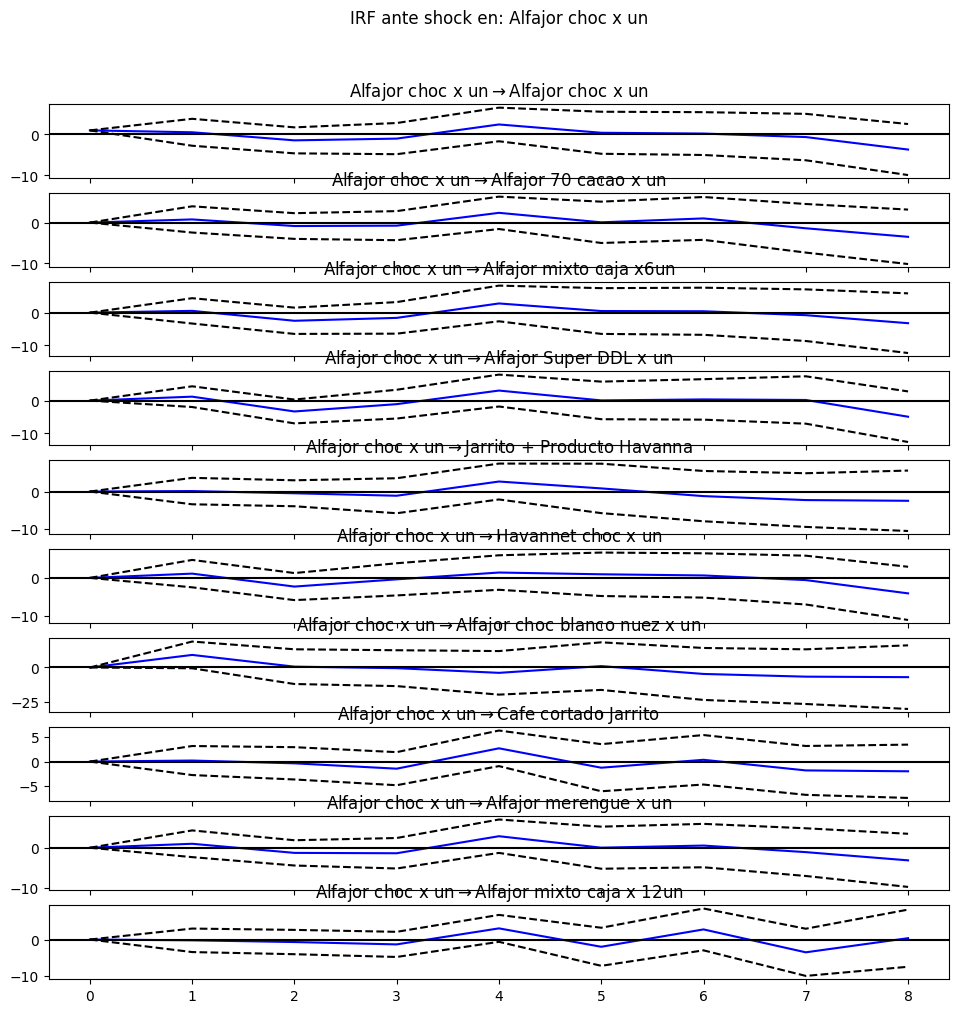

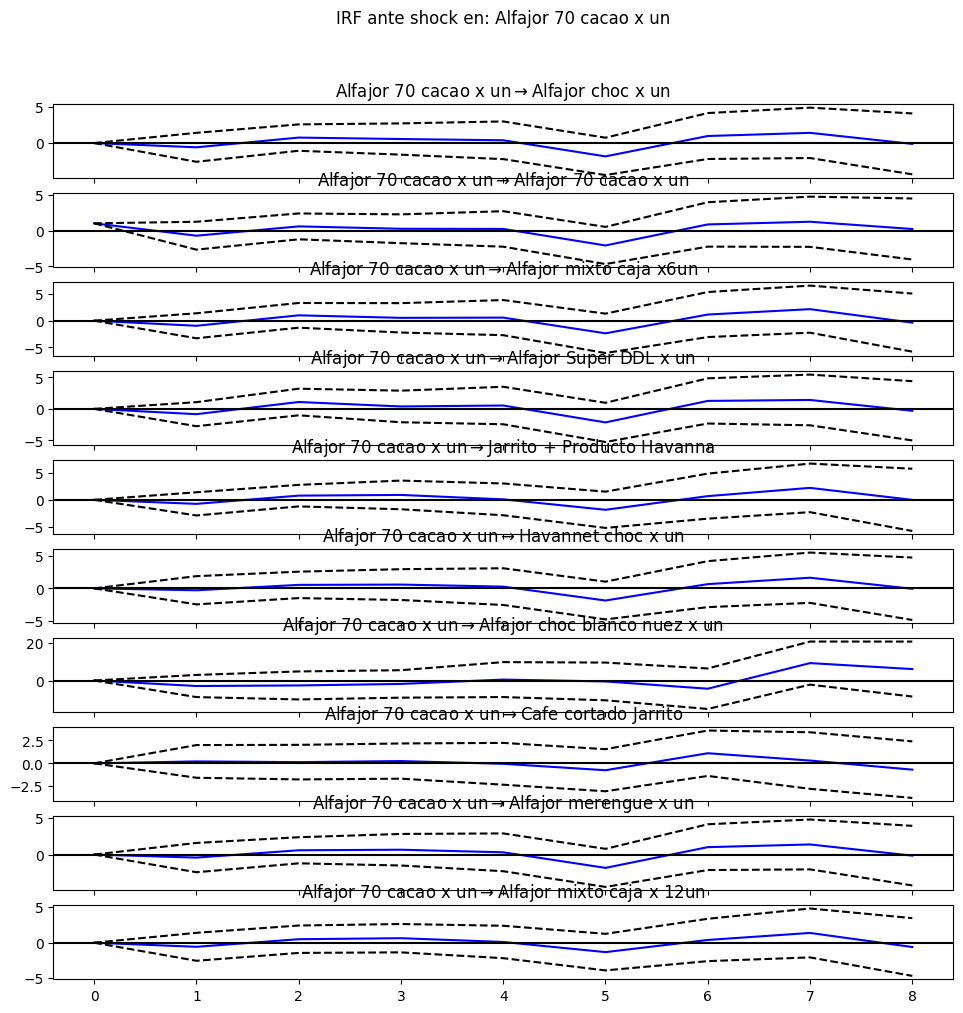

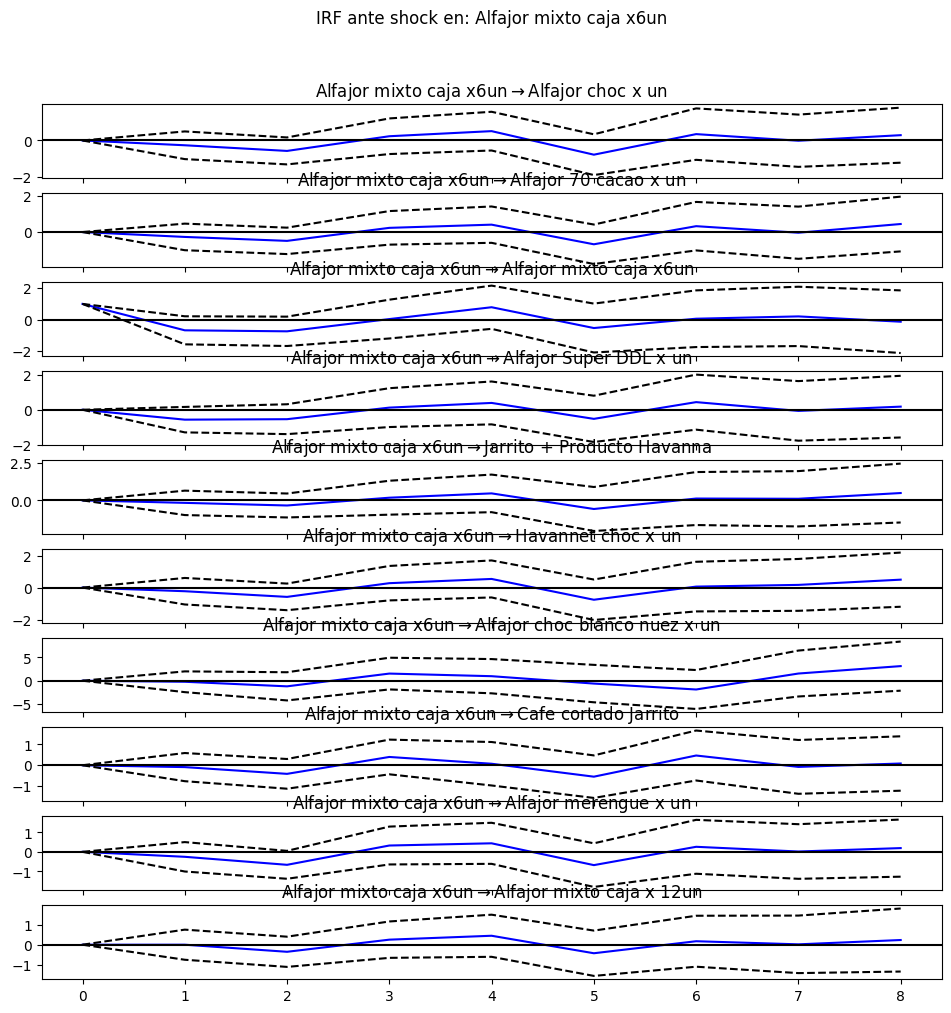

In [108]:
# === IRF: respuestas a shocks ===
top_vars = list(wide.sum().sort_values(ascending=False).head(3).index)
print("Shocks (variables seleccionadas para IRF):", top_vars)
plot_irf(res, periods=irf_periods, targets=top_vars)

In [109]:
# === (Opcional) Forecast h pasos y back-transform aproximado ===
h = 8  # horizonte
fc = res.forecast(y=X.values[-res.k_ar:], steps=h)
fc = pd.DataFrame(fc, columns=X.columns,
                  index=pd.date_range(X.index[-1] + pd.tseries.frequencies.to_offset(X.index.freqstr),
                                      periods=h, freq=X.index.freq))

log1p_wide = np.log1p(wide)
last = log1p_wide.iloc[-1]

recon = []
curr = last.copy()
for i in range(len(fc)):
    curr = curr + fc.iloc[i]
    recon.append(curr.copy())

recon = pd.DataFrame(recon, index=fc.index, columns=fc.columns)
fc_level = np.expm1(recon).clip(lower=0)

display(fc_level.head())

Nombre_Producto,Alfajor choc x un,Alfajor 70 cacao x un,Alfajor mixto caja x6un,Alfajor Super DDL x un,Jarrito + Producto Havanna,Havannet choc x un,Alfajor choc blanco nuez x un,Cafe cortado Jarrito,Alfajor merengue x un,Alfajor mixto caja x 12un
2025-07-13,615.162382,443.287505,87.055298,128.505820,251.906088,166.208786,0.382695,1053.676406,236.345415,359.914891
2025-07-20,1678.876273,908.855745,252.305810,292.249657,2012.755874,506.683190,4.502011,1606.260389,530.489432,340.045458
2025-07-27,1017.154994,718.138562,258.151916,162.797523,3187.405525,408.404507,57.311515,901.586998,385.542059,617.124947
2025-08-03,748.143521,412.125299,77.114234,89.112076,560.364871,167.662825,0.455184,1023.561841,250.533813,278.593888
2025-08-10,235.736403,132.603222,18.319510,28.045641,88.708906,50.183566,0.000000,612.925954,73.550736,92.783395


## Exportación modelo Locales propios para nuevo dataset

Prophet: se entrena con el train del dataset (nuevo o viejo).

MAalign: NO se exporta como número fijo; se recalcula usando el train actual.

Lo que sí exportás:

la “receta” (qué modelo, qué hiperparámetros, w y last_k de MAalign, etc.)

opcional: el Prophet entrenado del dataset viejo (para reproducibilidad), pero para aplicar a dataset nuevo, lo más sano es reentrenar Prophet con la historia nueva.

In [110]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from prophet.serialize import model_to_json, model_from_json

# ----------------------------
# IO helpers (export/import)
# ----------------------------
def save_bundle(bundle: dict, path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump(bundle, path)

def load_bundle(path: str) -> dict:
    return joblib.load(path)
